# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='equitysilver',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_st',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=2, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AA…

Dropdown(description='Objective:', index=2, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_st')

In [5]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [6]:
#Start Calculating the Running Time
Start = time.time()

In [7]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [8]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [9]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [10]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [11]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/equitysilver_c_curves_p.pkl
Loaded data from ./inputs/curves/equitysilver_c_curves_f.pkl


In [12]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for equitysilver_max_st_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17023 rows, 83258 columns and 83258 nonzeros
Model fingerprint: 0x0424cb95
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 17023 rows and 83258 columns
Presolve time: 0.09s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.6531903e+09   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.11 seconds (0.03 work units)
Optimal objective  1.653190340e+09


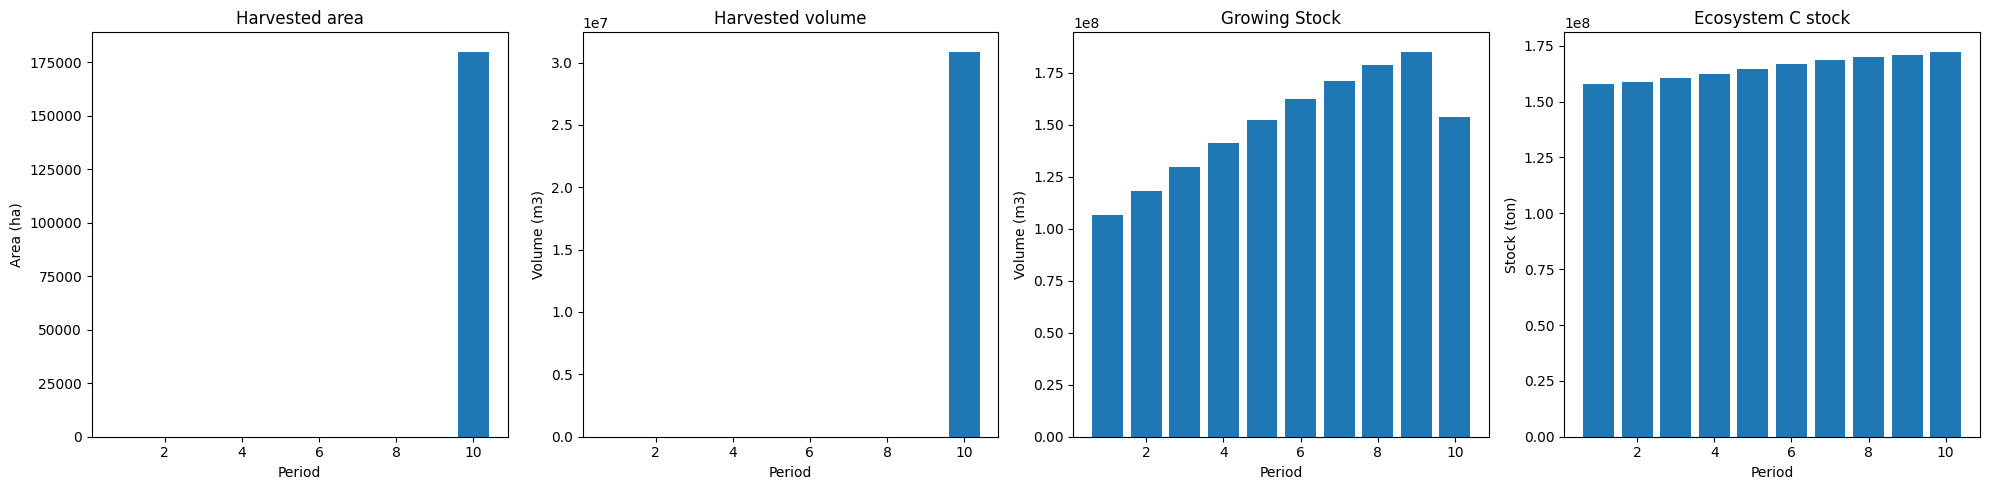

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  32642
The economic indicator (the provincial government revenues) is:  1113182
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


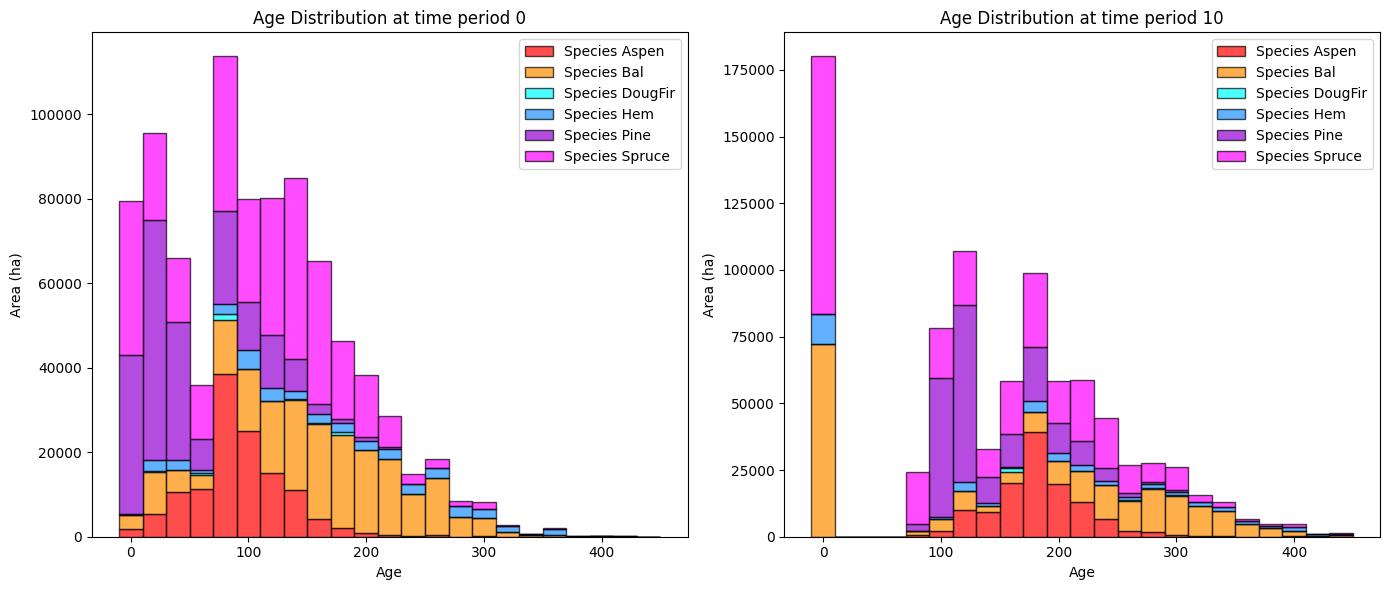

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229   22601.444196   3449.316967
DougFir    947.047810    2749.298212   1802.250402
Bal      59315.970469  100901.976746  41586.006277
Spruce   36410.744598  120534.912326  84124.167728
Aspen    29632.731169  118345.834248  88713.103079
Pine      7432.733686   70671.811755  63239.078069

Overall diversity has **increased** by 282913.92 hectares from time period 0 to time period 10.


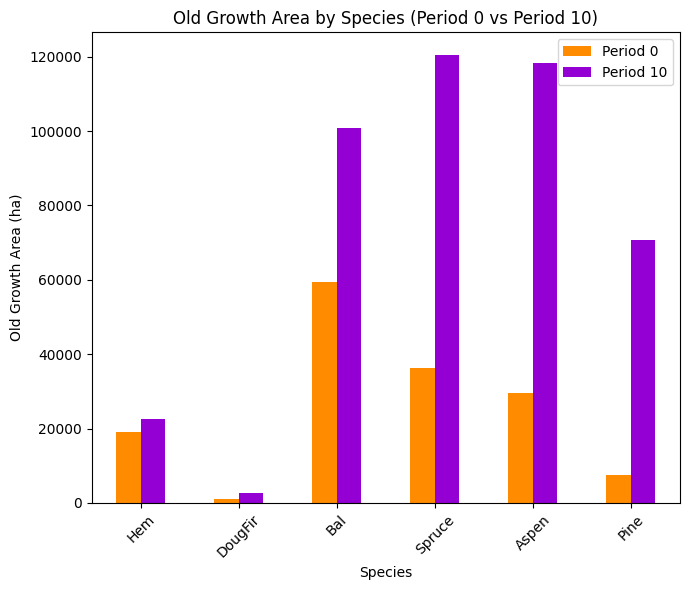

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7219

Diversity has **decreased** by 3.73% from time 0 to time 10.


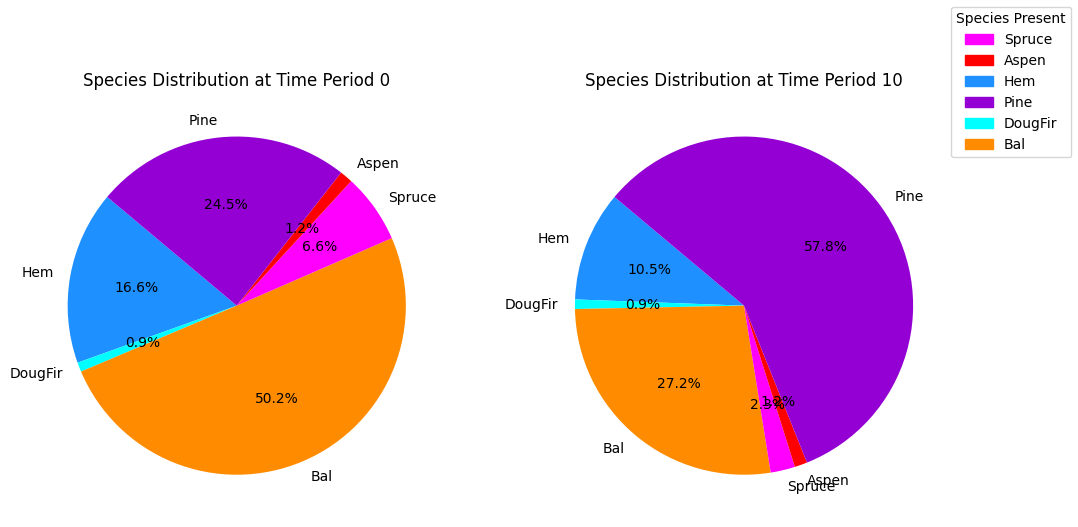

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering t

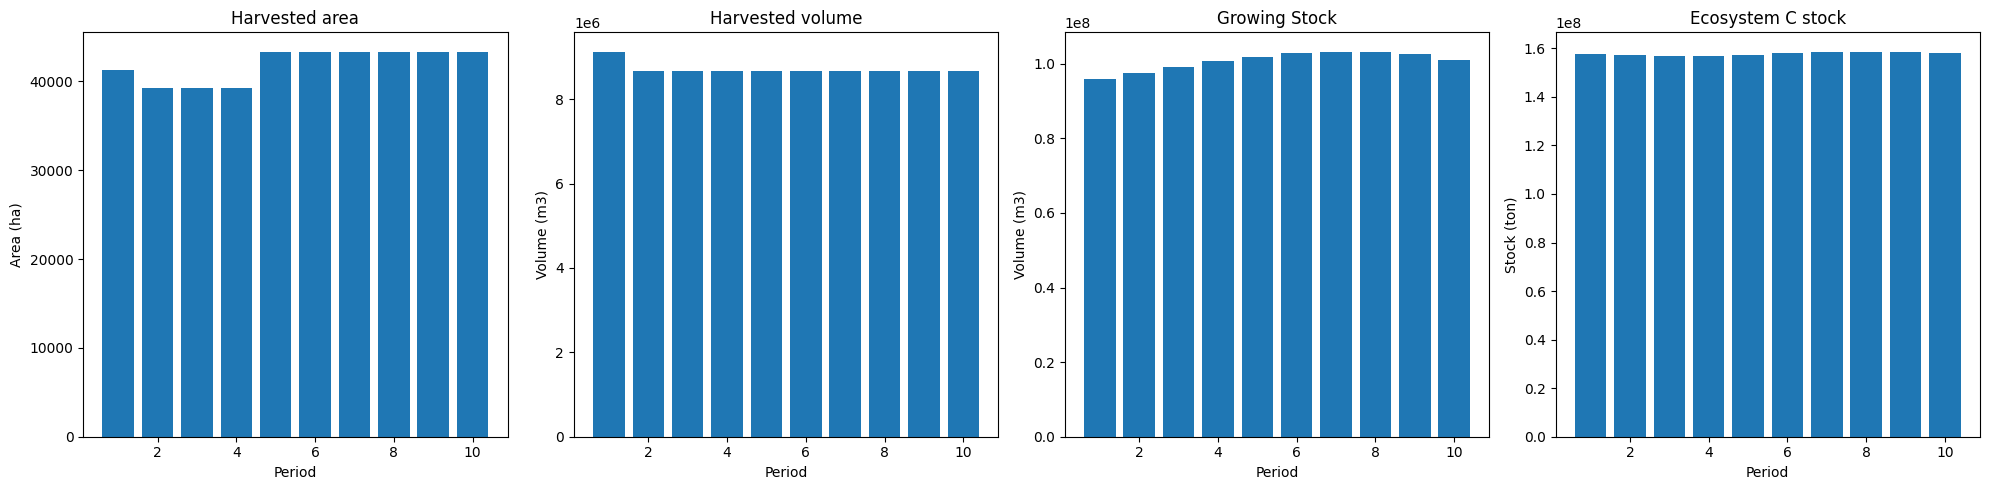

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


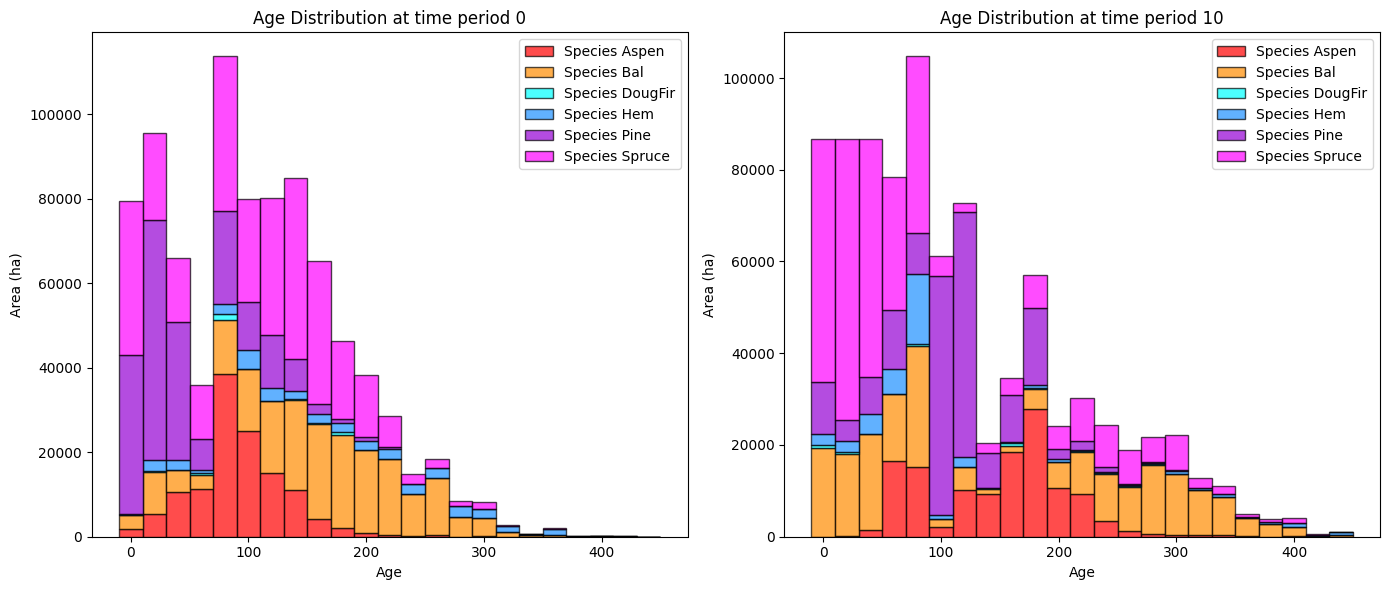

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


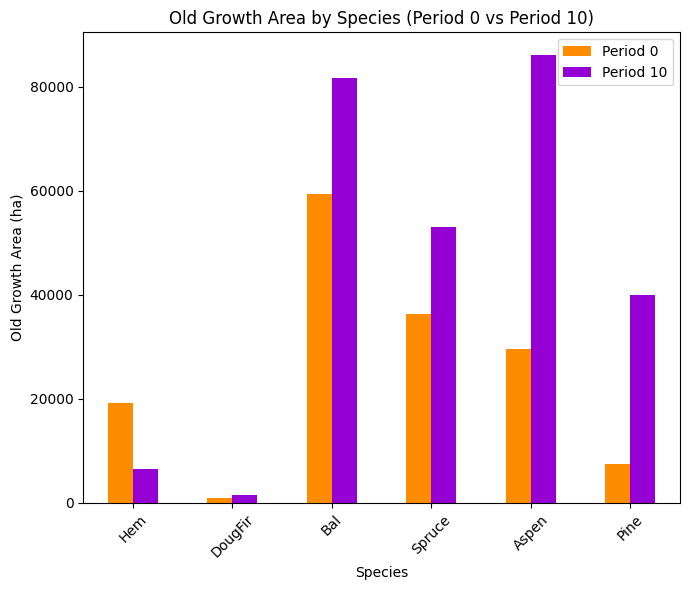

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


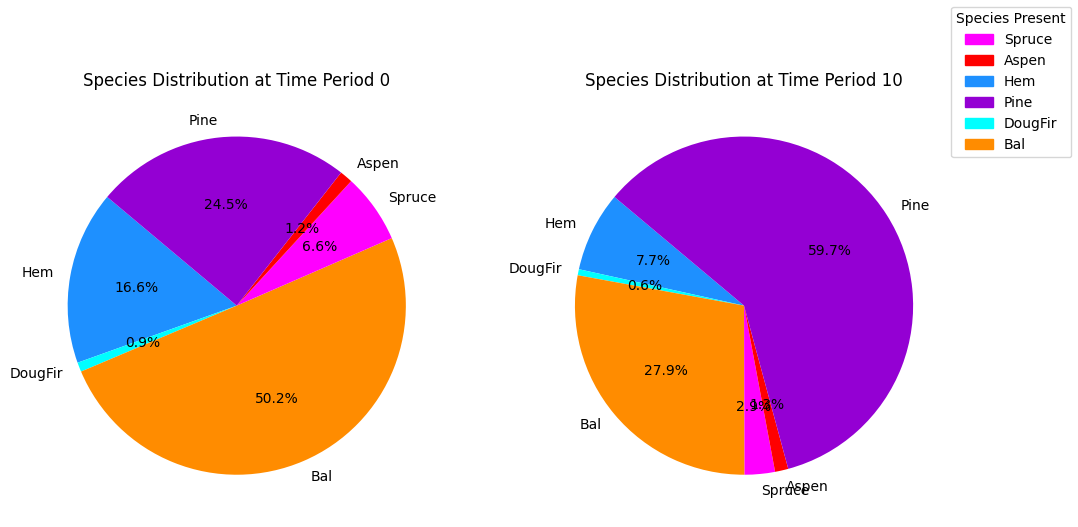

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


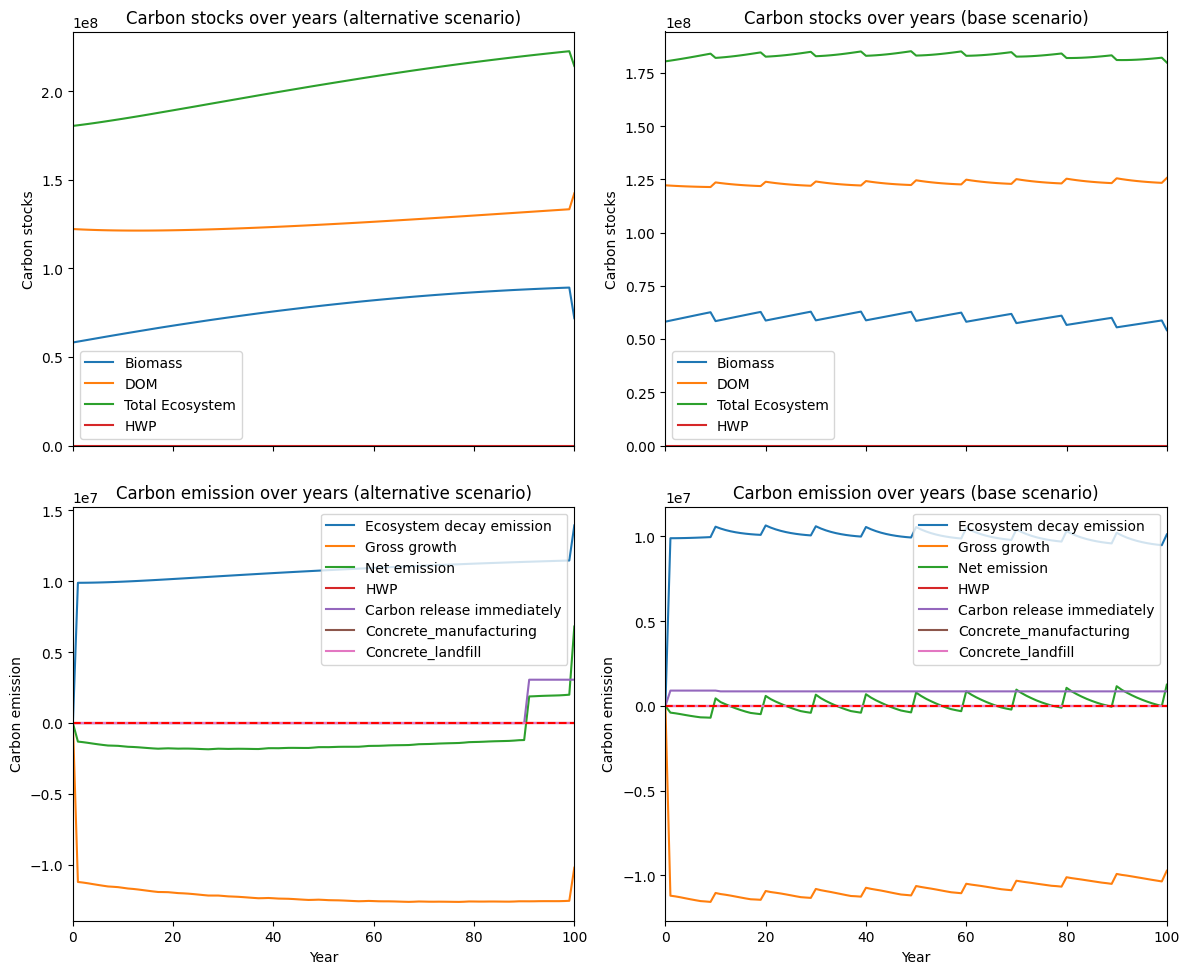

---------------------------------------------------------------------------------------
Net emission difference -34497970.174029484
Net emission base scenario -39533774.029656515
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.28987212724556555
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  15992.267313  15992.267313
DougFir  0.0   1273.171398   1273.171398
Bal      0.0  19146.066793  19146.066793
Spruce   0.0  67508.809228  67508.809228
Aspen    0.0  32215.247295  32215.247295
Pine     0.0  30669.681798  30669.681798

Overall, the old growth area has **increased** by 166805.24 hectares in the alternative scenario compared to the base scenario.


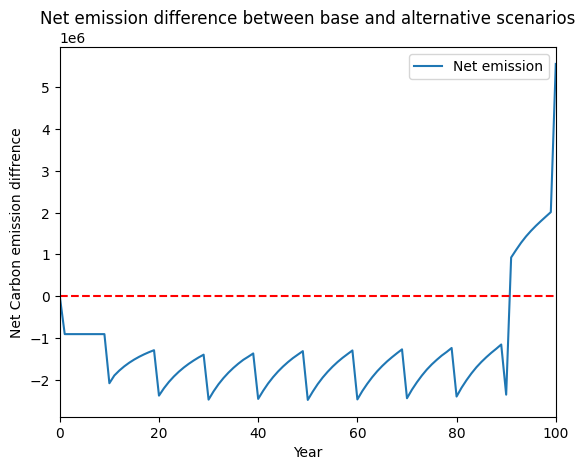

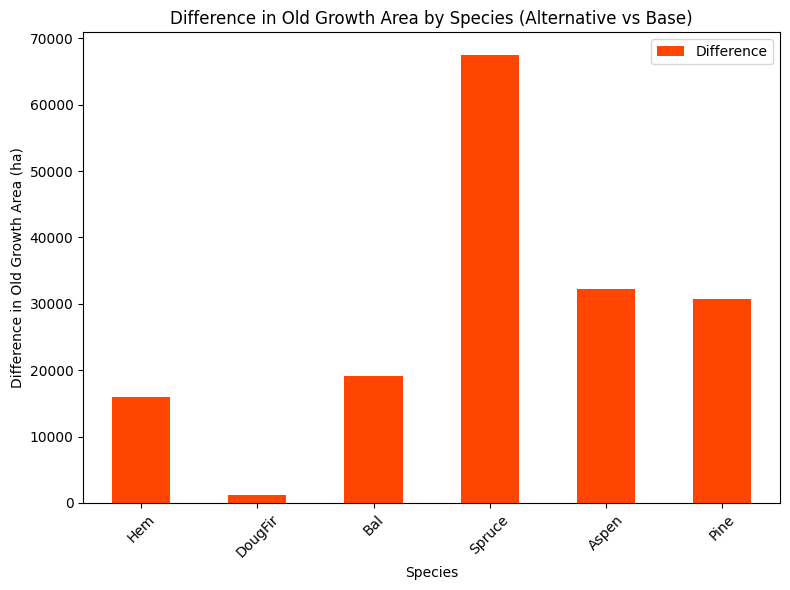

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


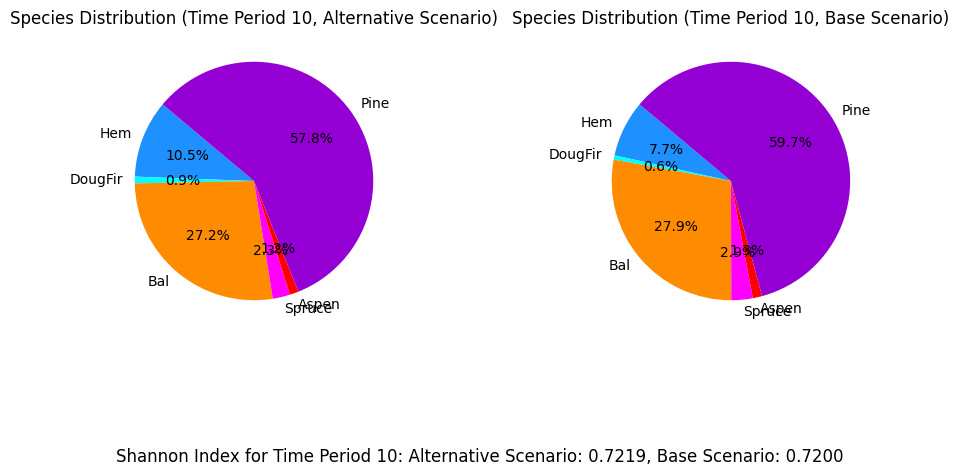

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17063 rows, 83258 columns and 514878 nonzeros
Model fingerprint: 0xb55bf428
Coefficient statistics:
  Matrix range     [5e-03, 6e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 8690 rows and 8882 columns
Presolve time: 0.20s
Presolved: 8373 rows, 74376 columns, 486429 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

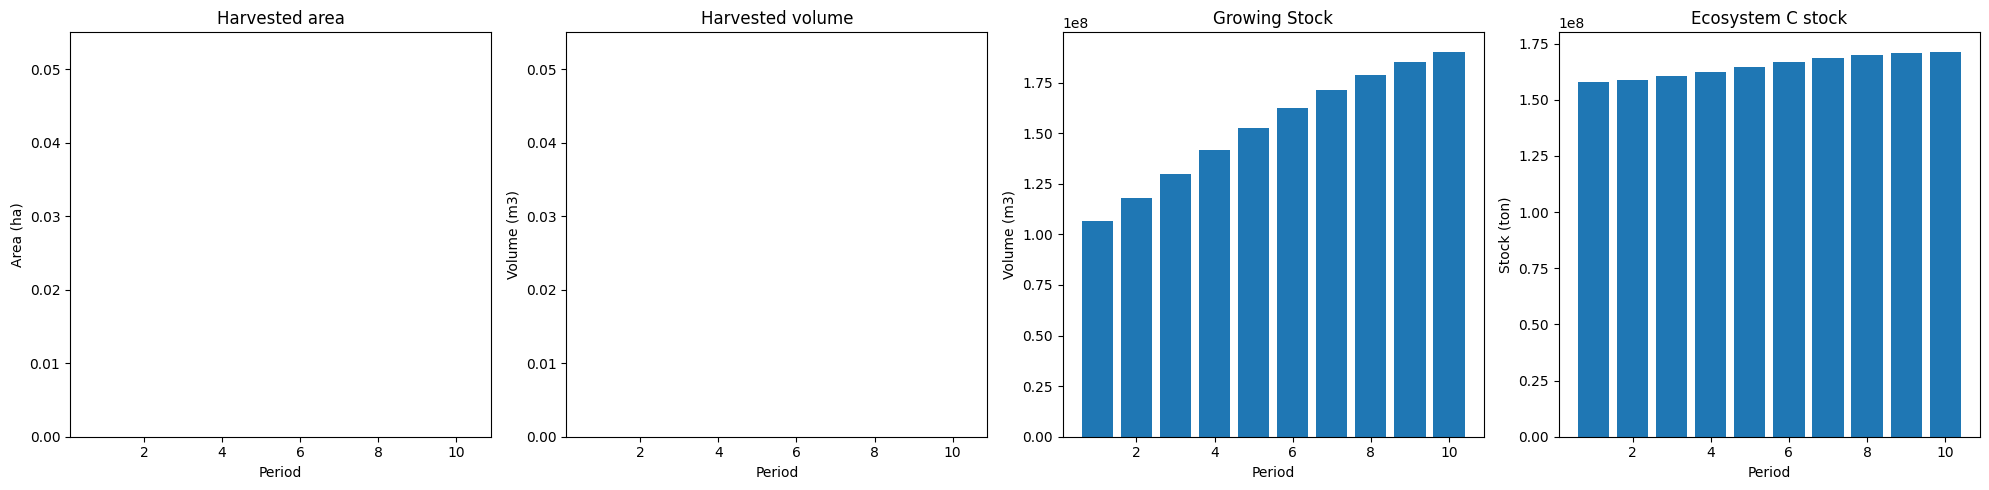

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


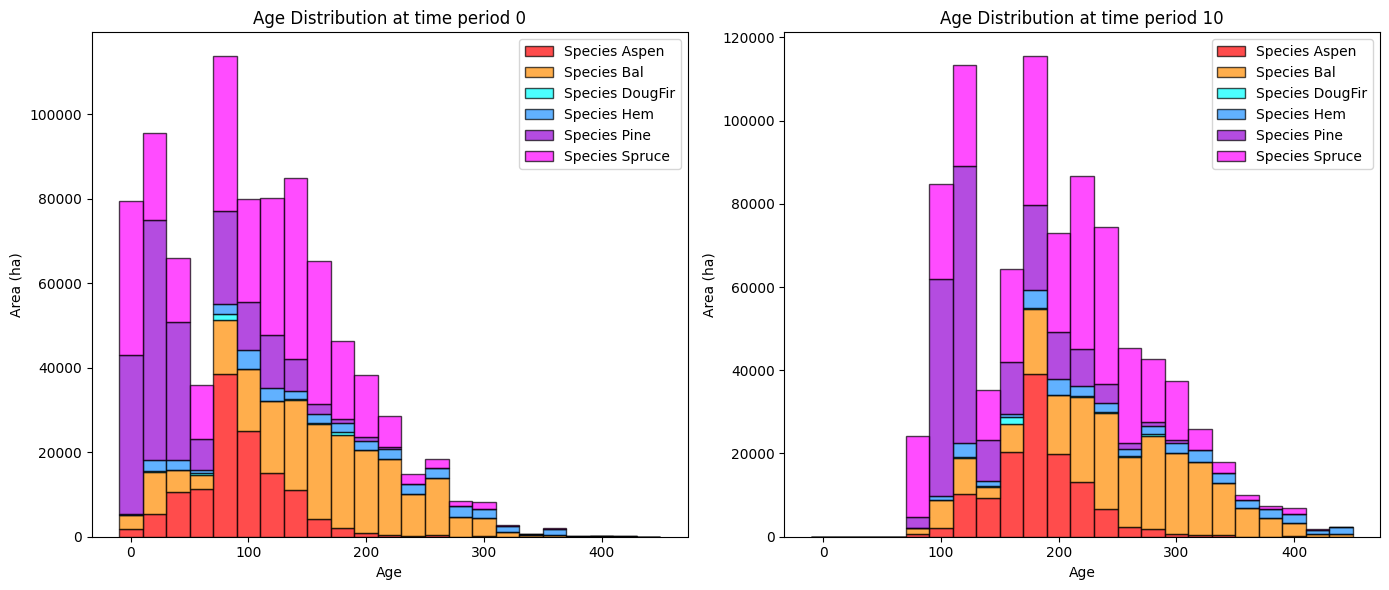

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157689.747715   98373.777247
Spruce   36410.744598  198358.607639  161947.863041
Aspen    29632.731169  118345.834248   88713.103079
Pine      7432.733686   70671.811755   63239.078069

Overall diversity has **increased** by 427612.91 hectares from time period 0 to time period 10.


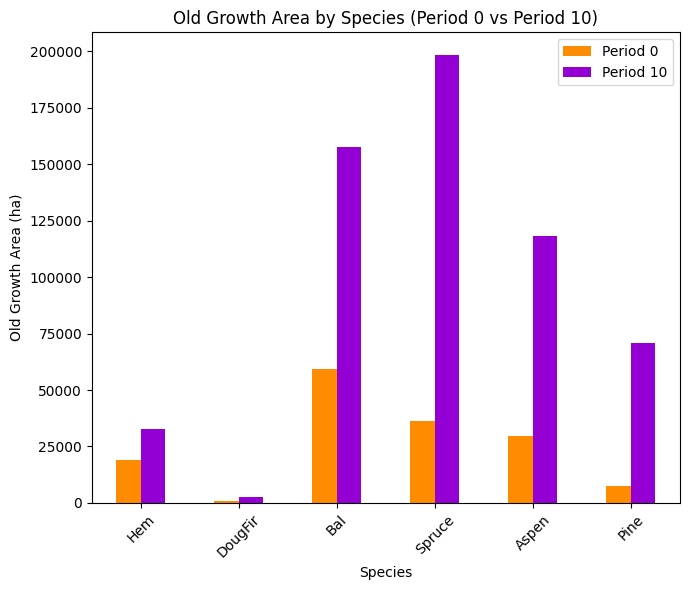

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7457

Diversity has **decreased** by 1.35% from time 0 to time 10.


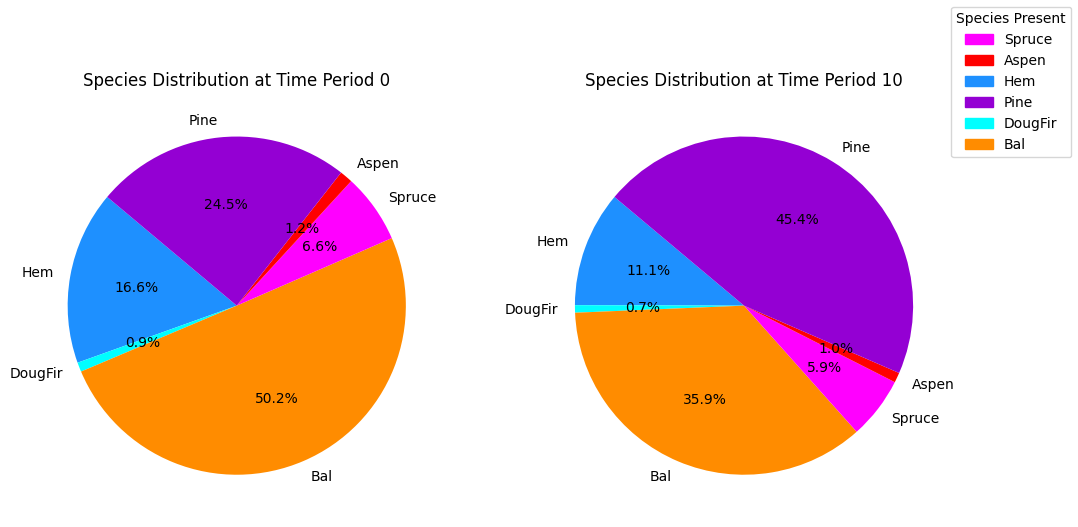

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

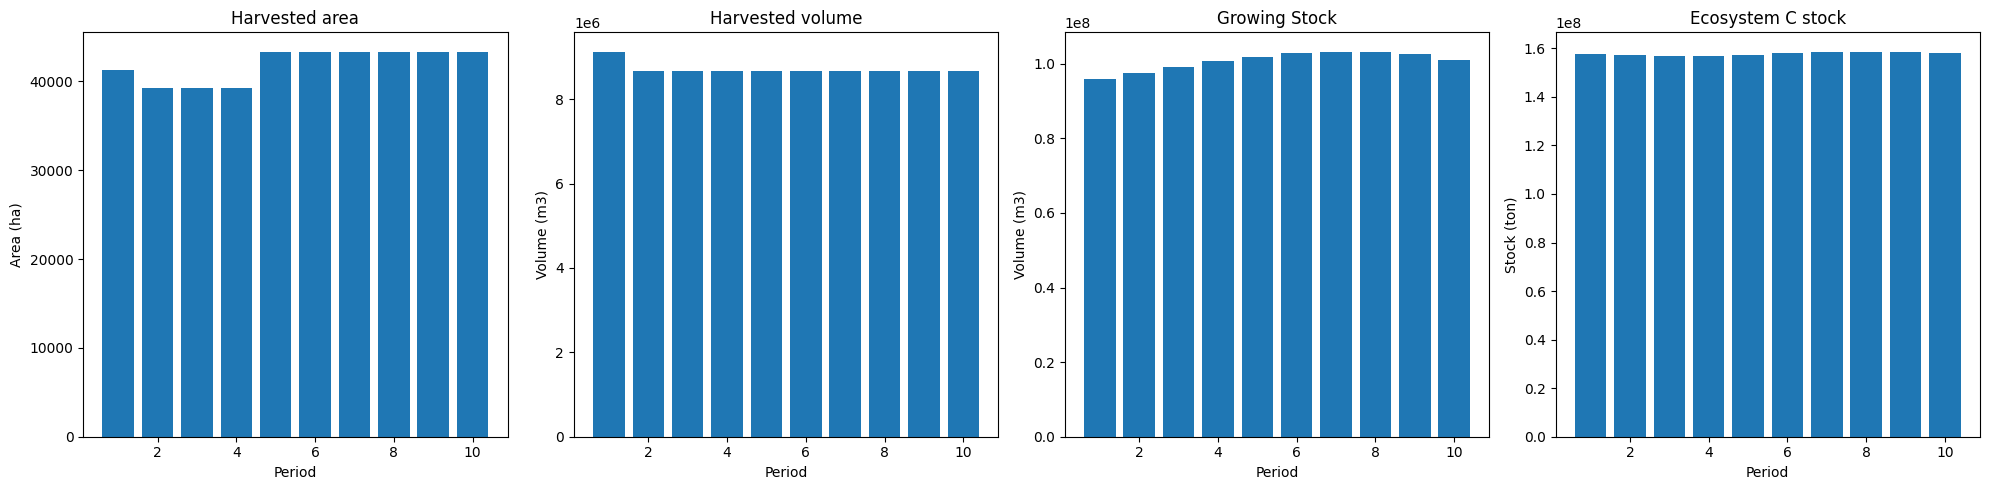

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


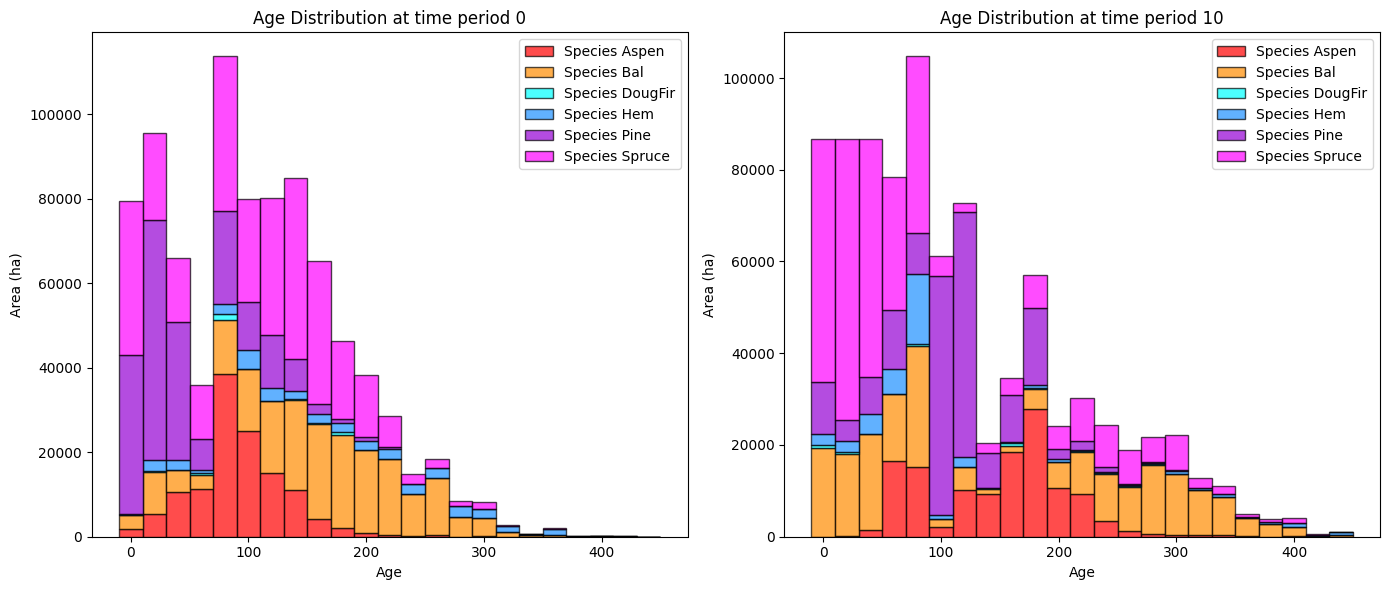

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


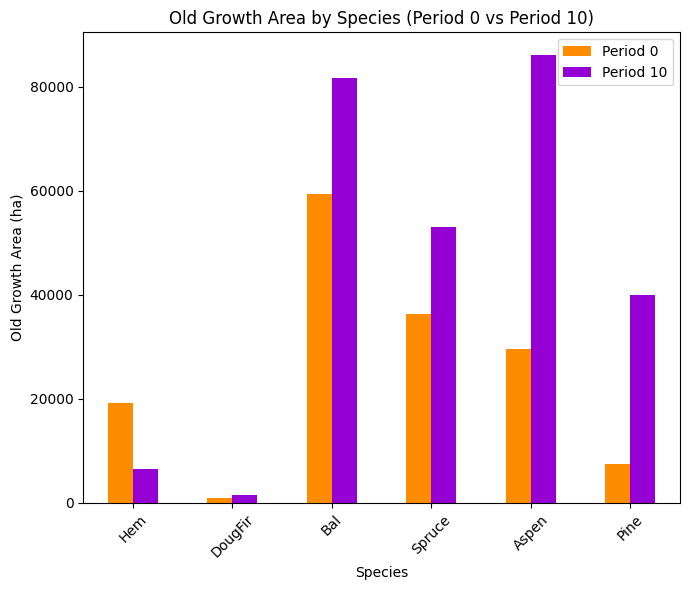

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


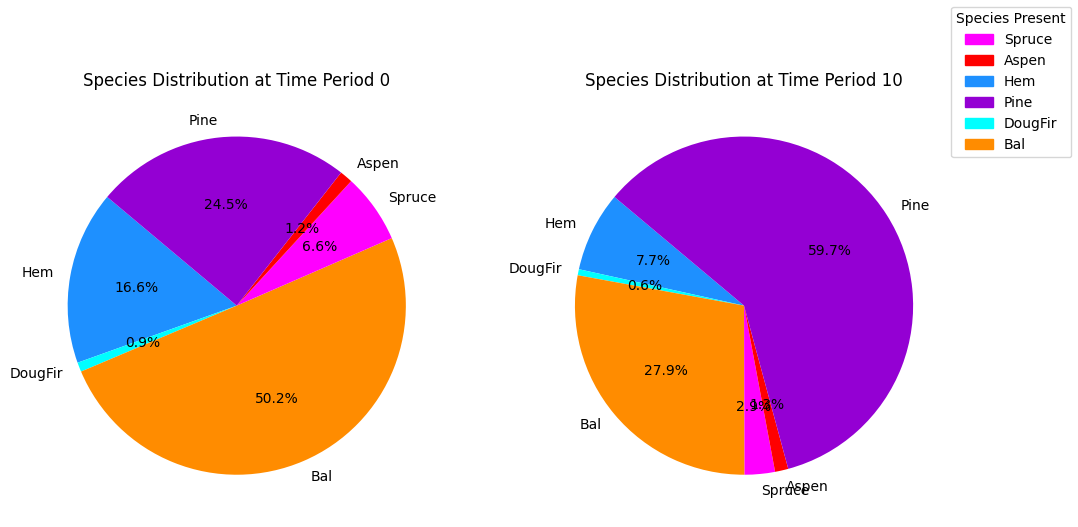

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


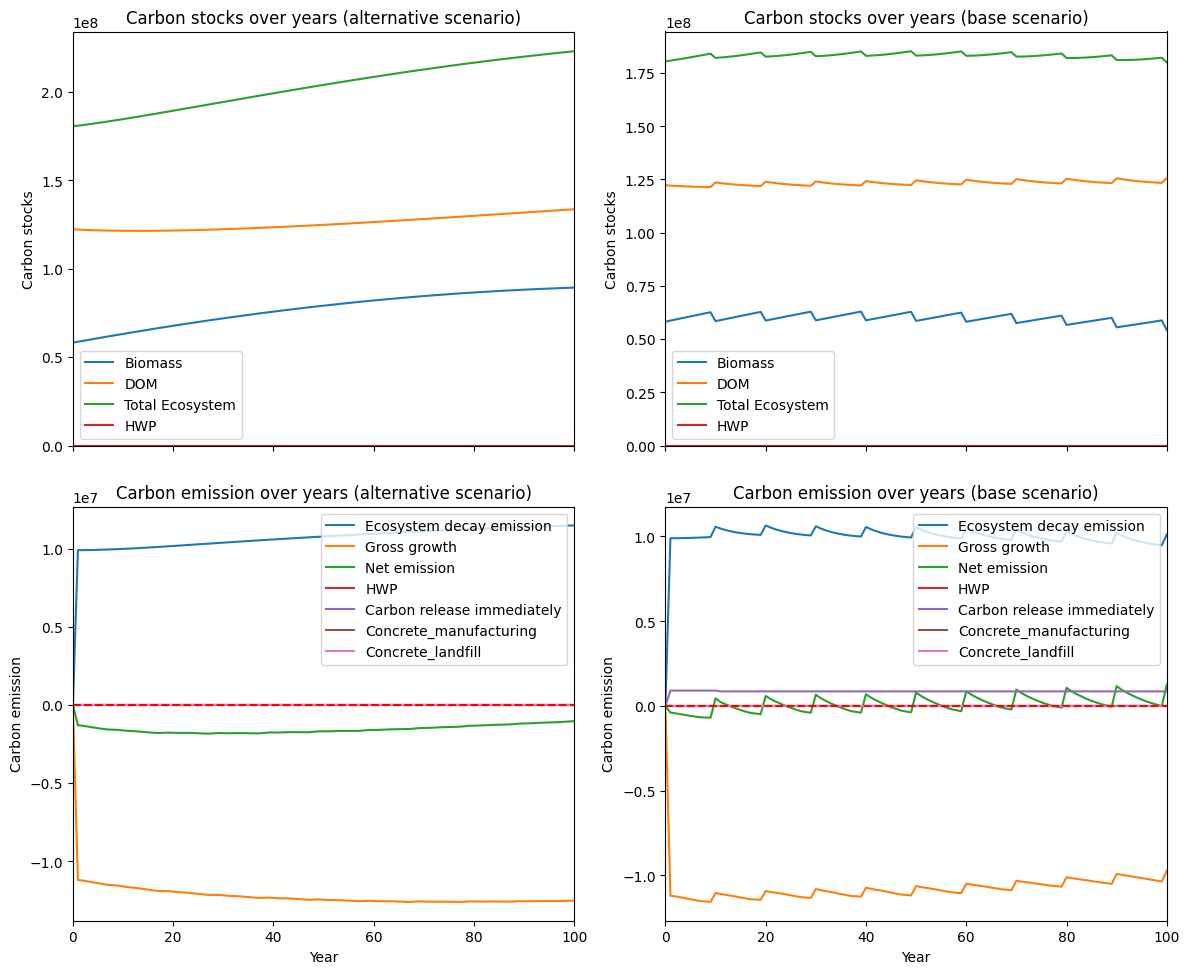

---------------------------------------------------------------------------------------
Net emission difference -34497970.174029484
Net emission base scenario -39533774.029656515
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.28987212724556555
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0   26079.787678   26079.787678
DougFir  0.0    1273.171398    1273.171398
Bal      0.0   75933.837763   75933.837763
Spruce   0.0  145332.504541  145332.504541
Aspen    0.0   32215.247295   32215.247295
Pine     0.0   30669.681798   30669.681798

Overall, the old growth area has **increased** by 311504.23 hectares in the alternative scenario compared to the base scenario.


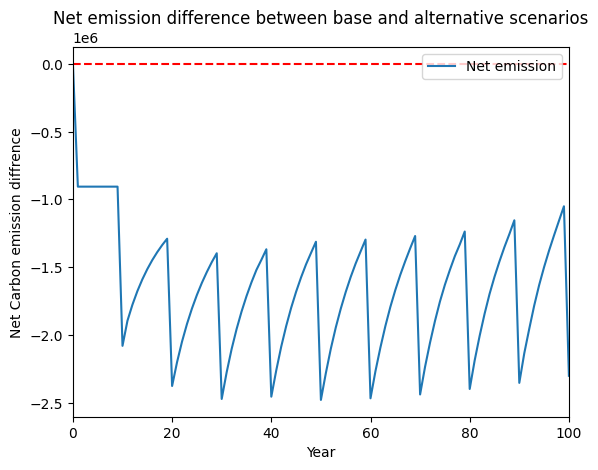

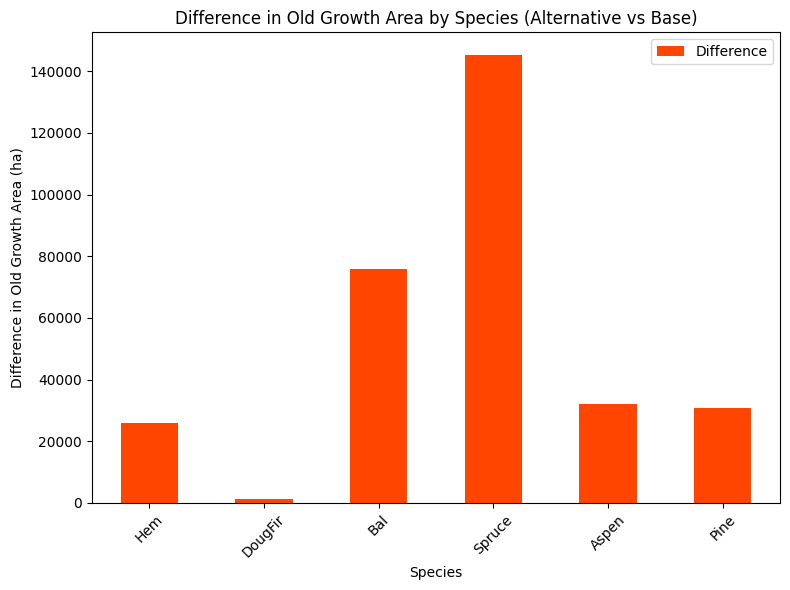

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


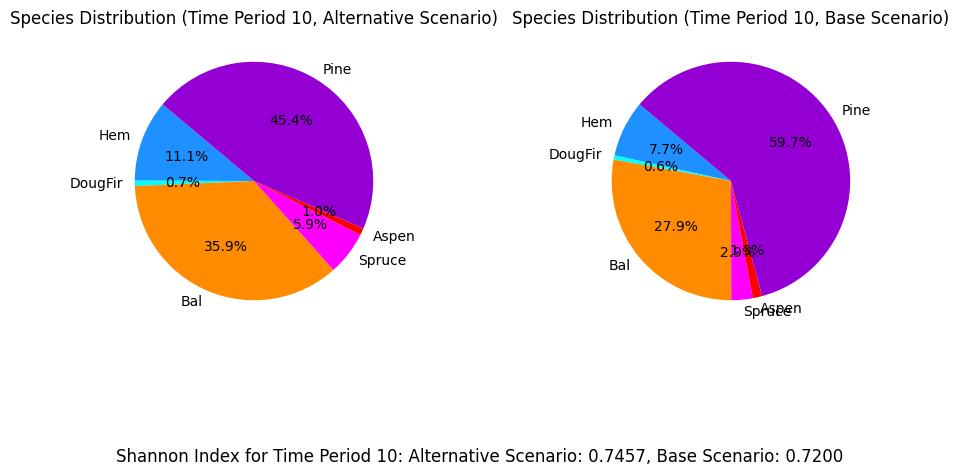

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_90%...
running the scenario for the Equity Silver mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x0376c5b7
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 r

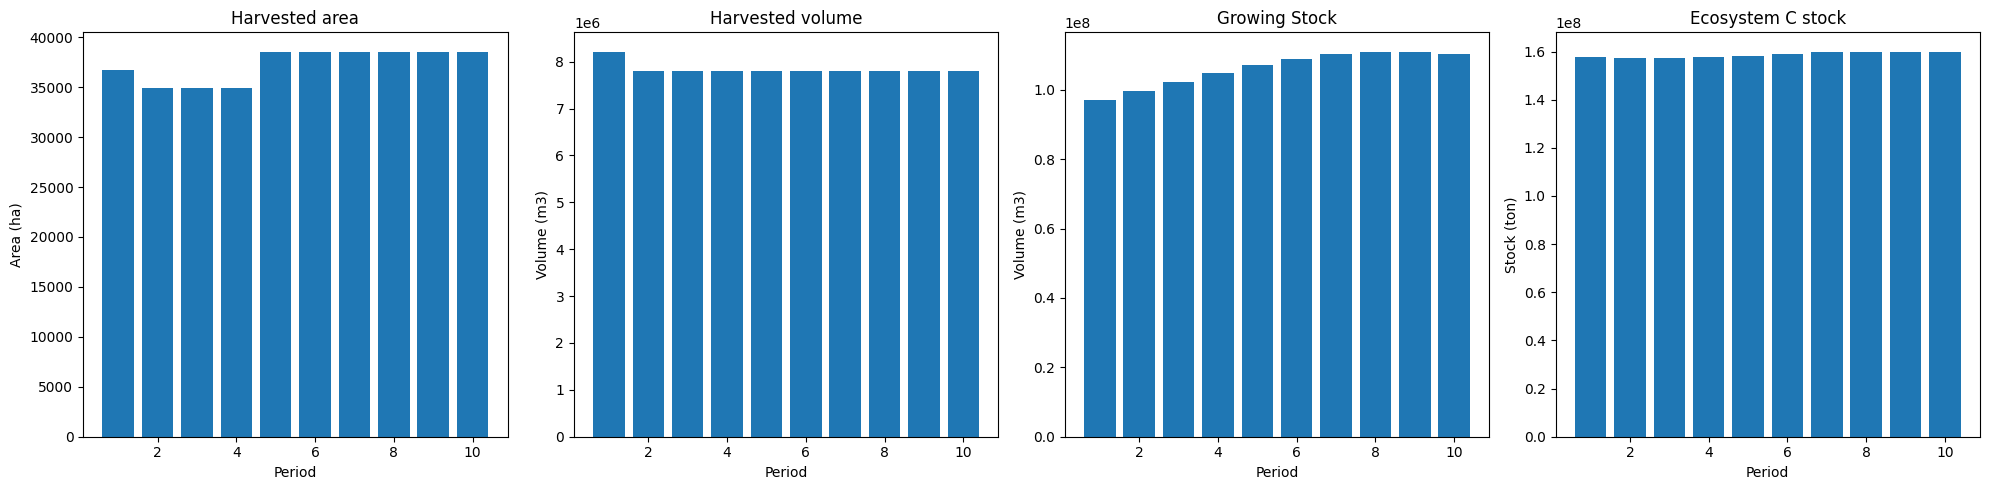

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  82941
The economic indicator (the provincial government revenues) is:  2828481
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


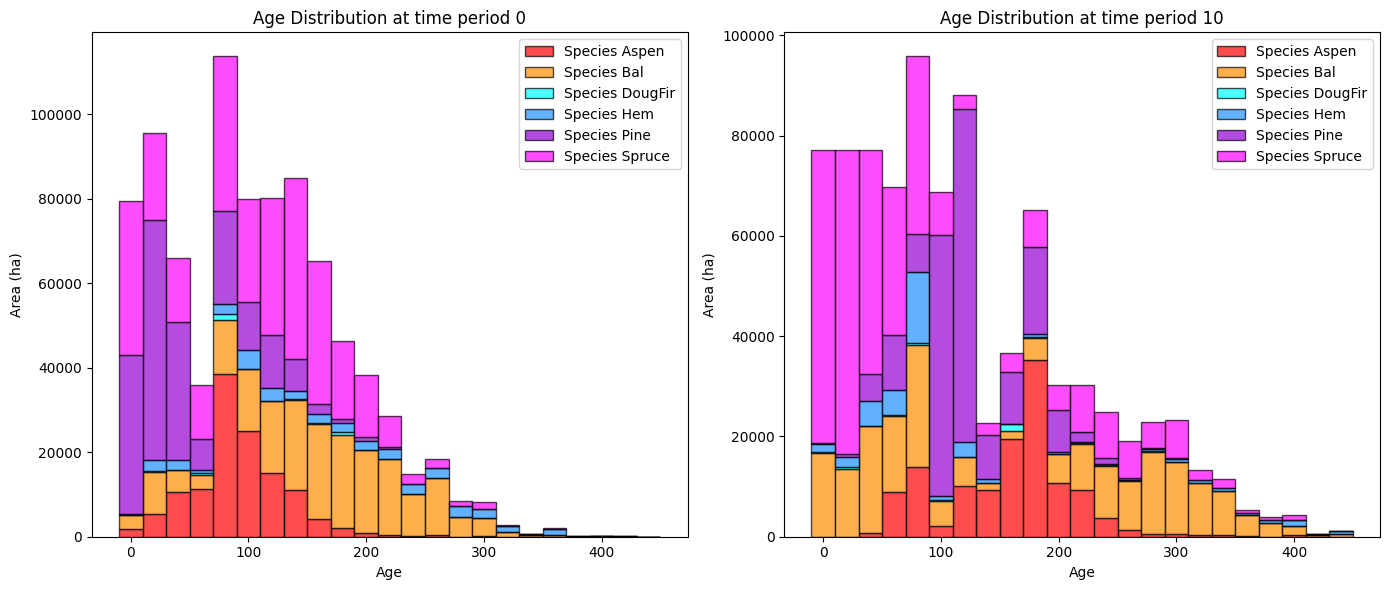

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   7779.979555 -11372.147674
DougFir    947.047810   1873.331440    926.283630
Bal      59315.970469  85667.874795  26351.904327
Spruce   36410.744598  53090.188907  16679.444309
Aspen    29632.731169  95570.257762  65937.526593
Pine      7432.733686  49856.905154  42424.171468

Overall diversity has **increased** by 140947.18 hectares from time period 0 to time period 10.


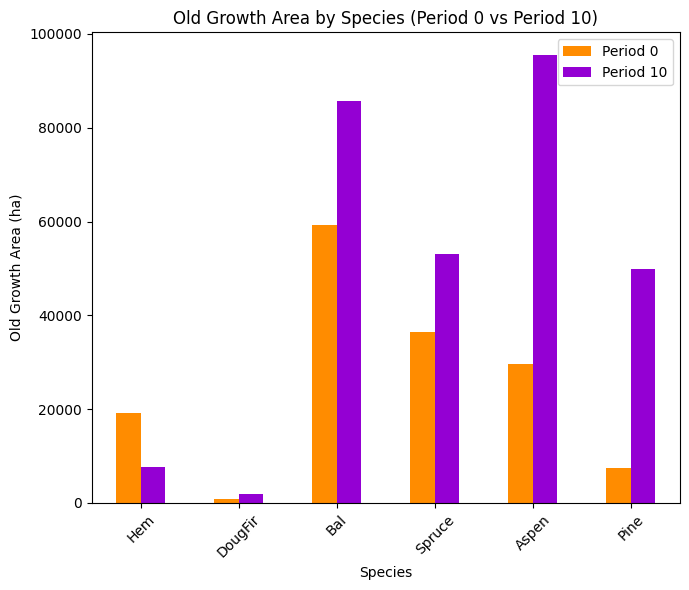

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7132

Diversity has **decreased** by 4.60% from time 0 to time 10.


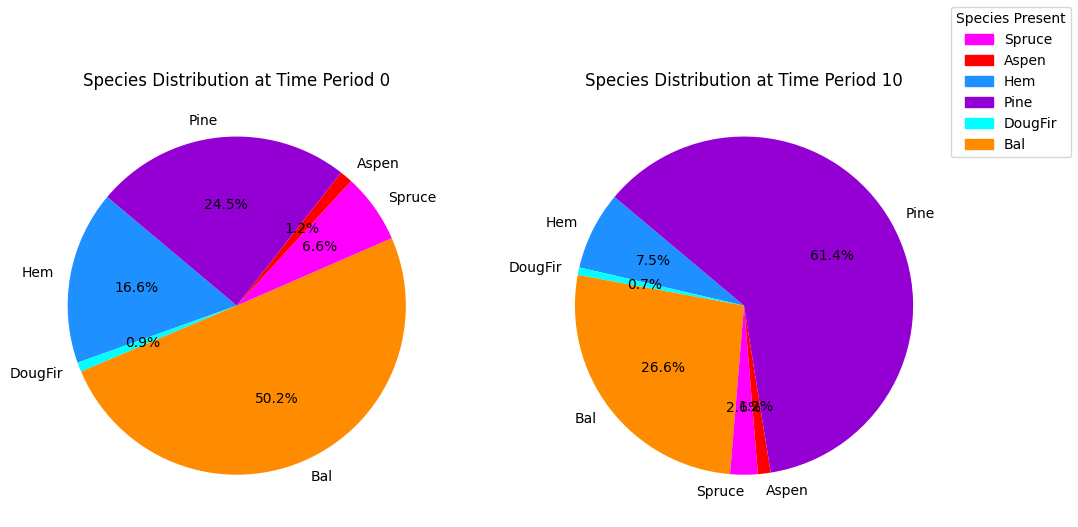

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

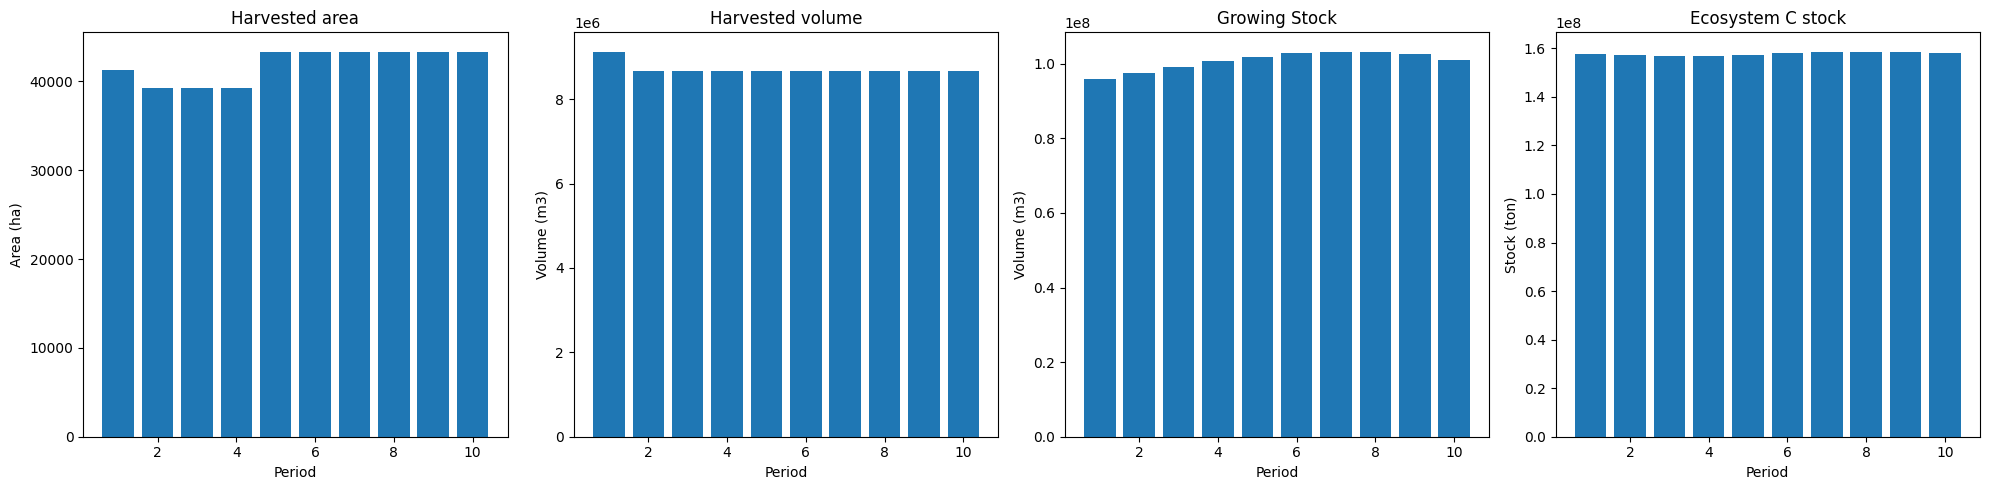

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


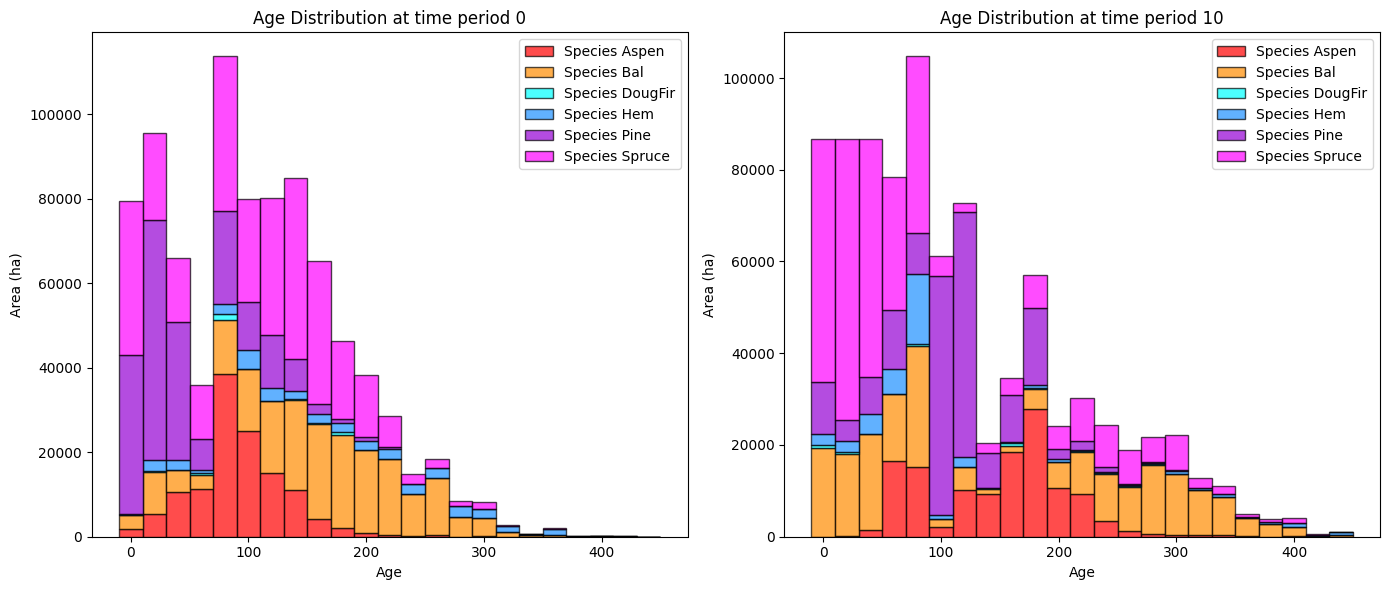

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


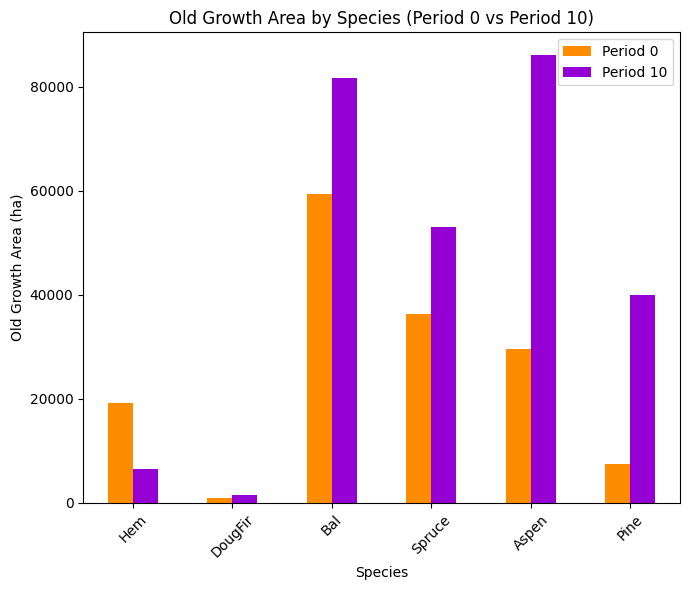

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


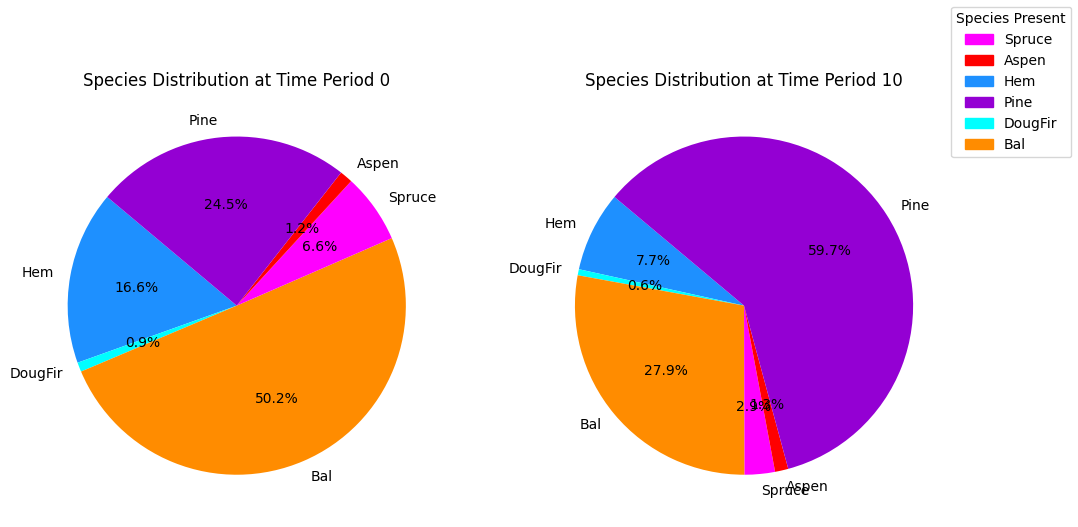

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


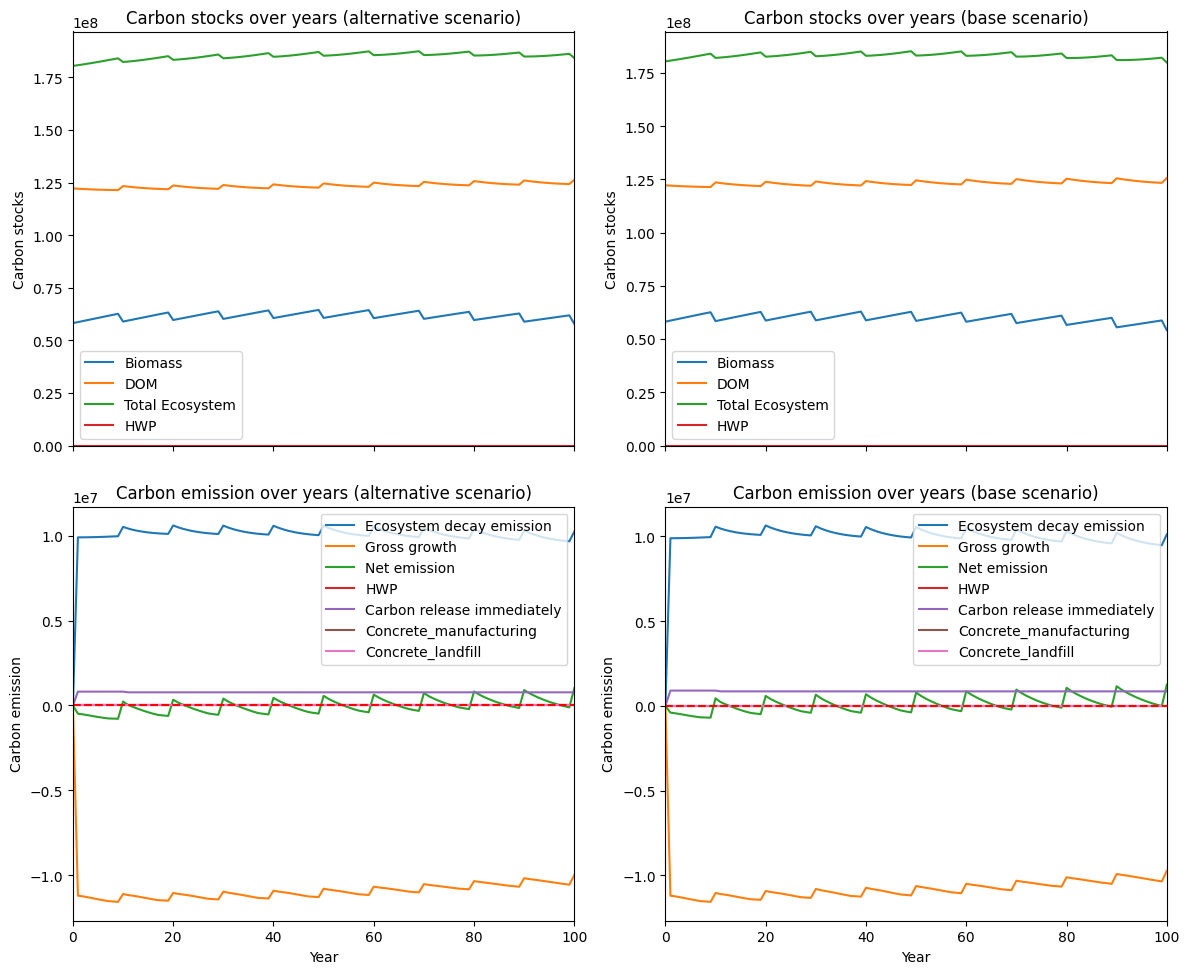

---------------------------------------------------------------------------------------
Net emission difference -3571614.2833468993
Net emission base scenario -8607418.138973935
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  2.7998544094266444
Comparison of Old Growth Areas (Alternative - Base)
           0           10   Difference
Hem      0.0  1170.802672  1170.802672
DougFir  0.0   397.204626   397.204626
Bal      0.0  3911.964843  3911.964843
Spruce   0.0    64.085809    64.085809
Aspen    0.0  9439.670809  9439.670809
Pine     0.0  9854.775198  9854.775198

Overall, the old growth area has **increased** by 24838.50 hectares in the alternative scenario compared to the base scenario.


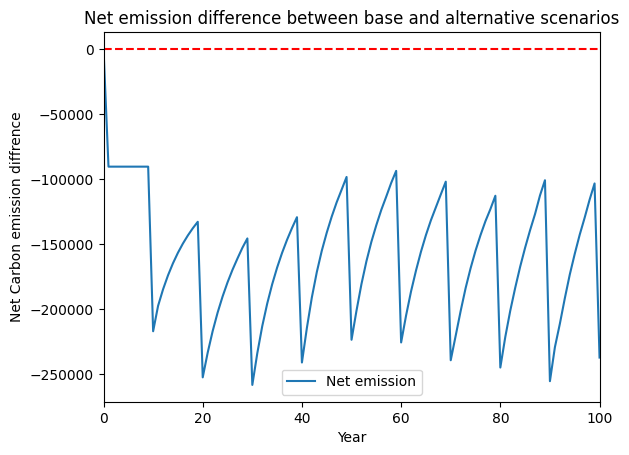

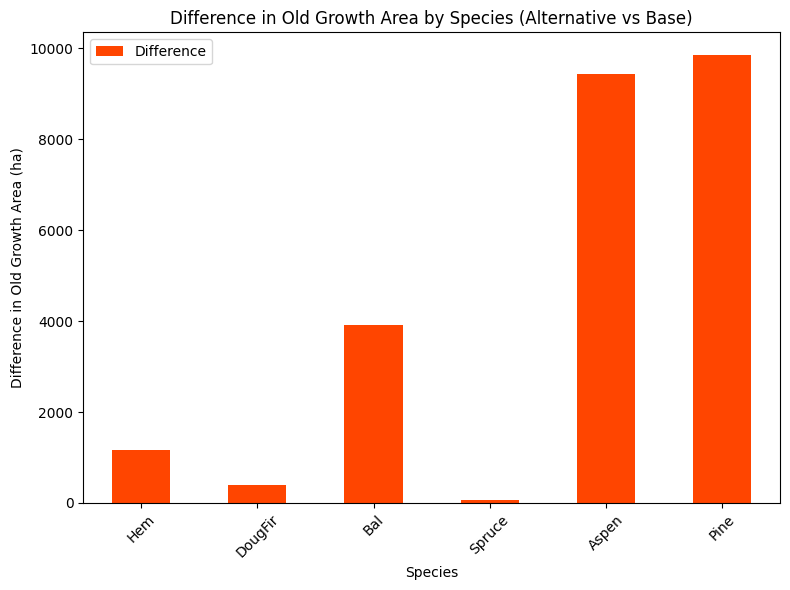

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


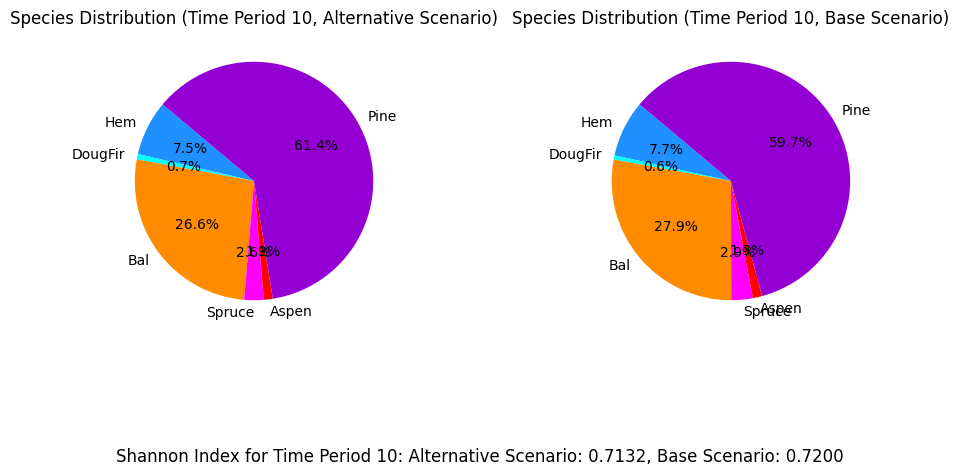

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_80%...
running the scenario for the Equity Silver mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xa3fde34c
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.29s
Presolved: 8375 r

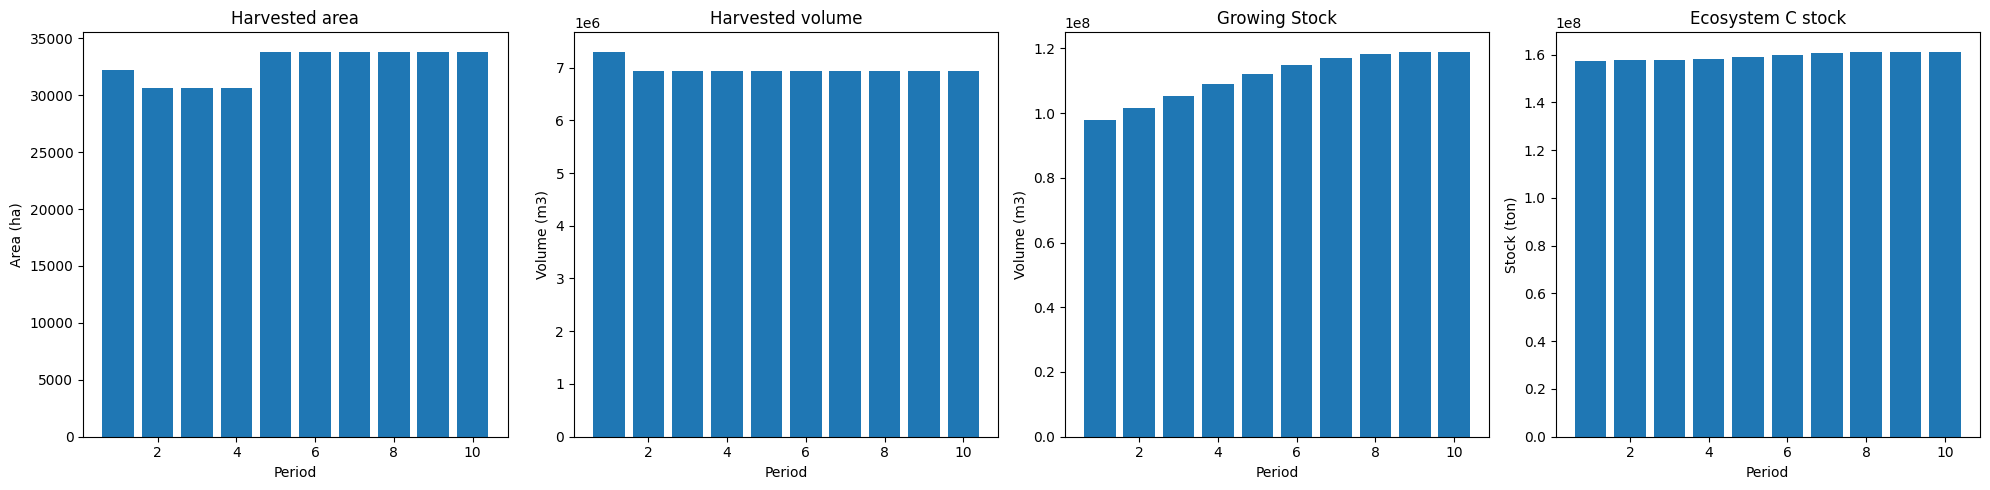

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  73725
The economic indicator (the provincial government revenues) is:  2514205
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


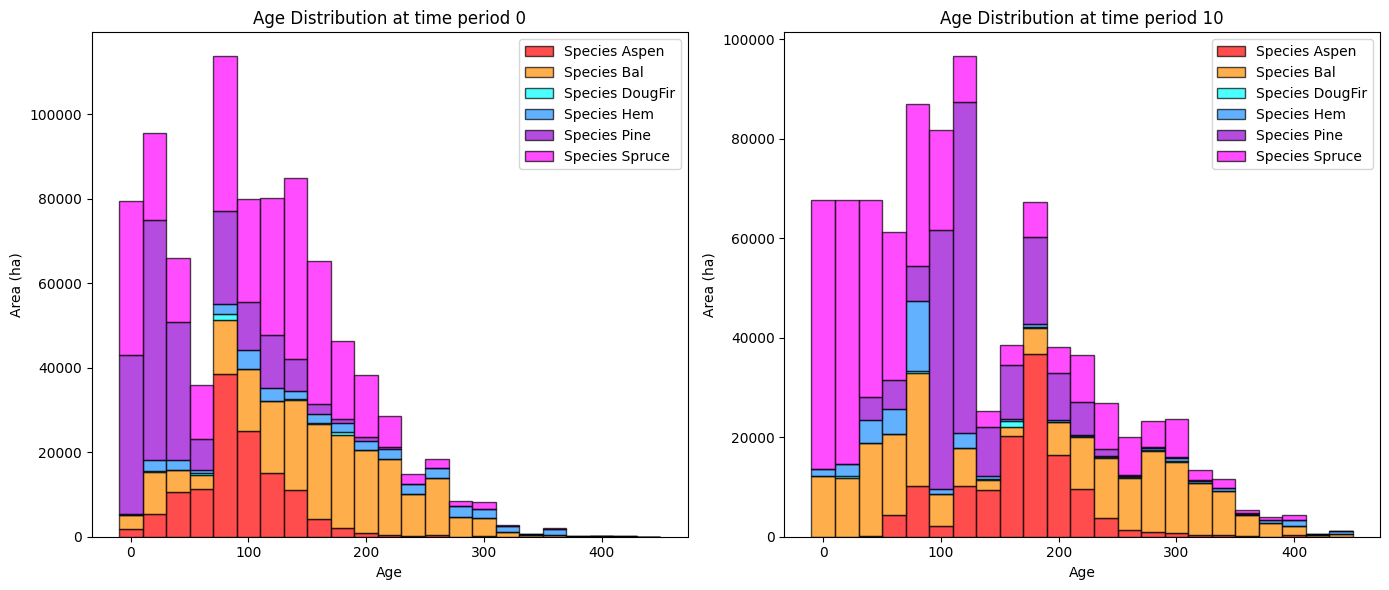

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    7869.127036 -11283.000193
DougFir    947.047810    2038.269407   1091.221597
Bal      59315.970469   90891.367163  31575.396694
Spruce   36410.744598   53877.211647  17466.467049
Aspen    29632.731169  104381.522984  74748.791815
Pine      7432.733686   56524.491450  49091.757764

Overall diversity has **increased** by 162690.63 hectares from time period 0 to time period 10.


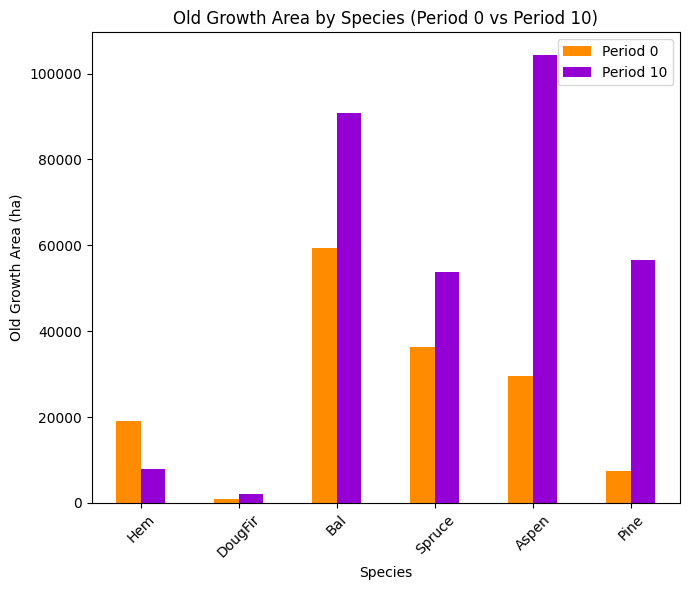

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7180

Diversity has **decreased** by 4.12% from time 0 to time 10.


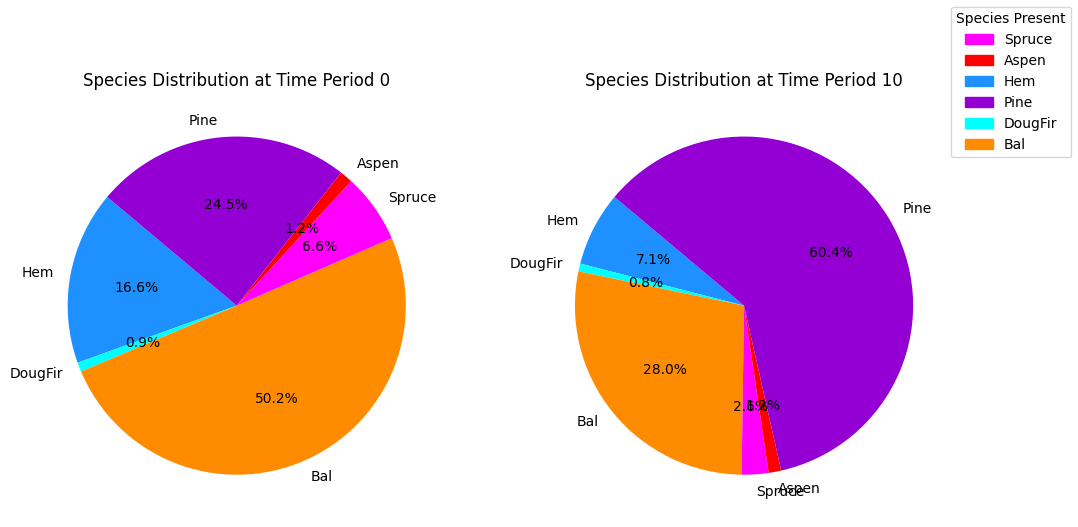

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.28s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

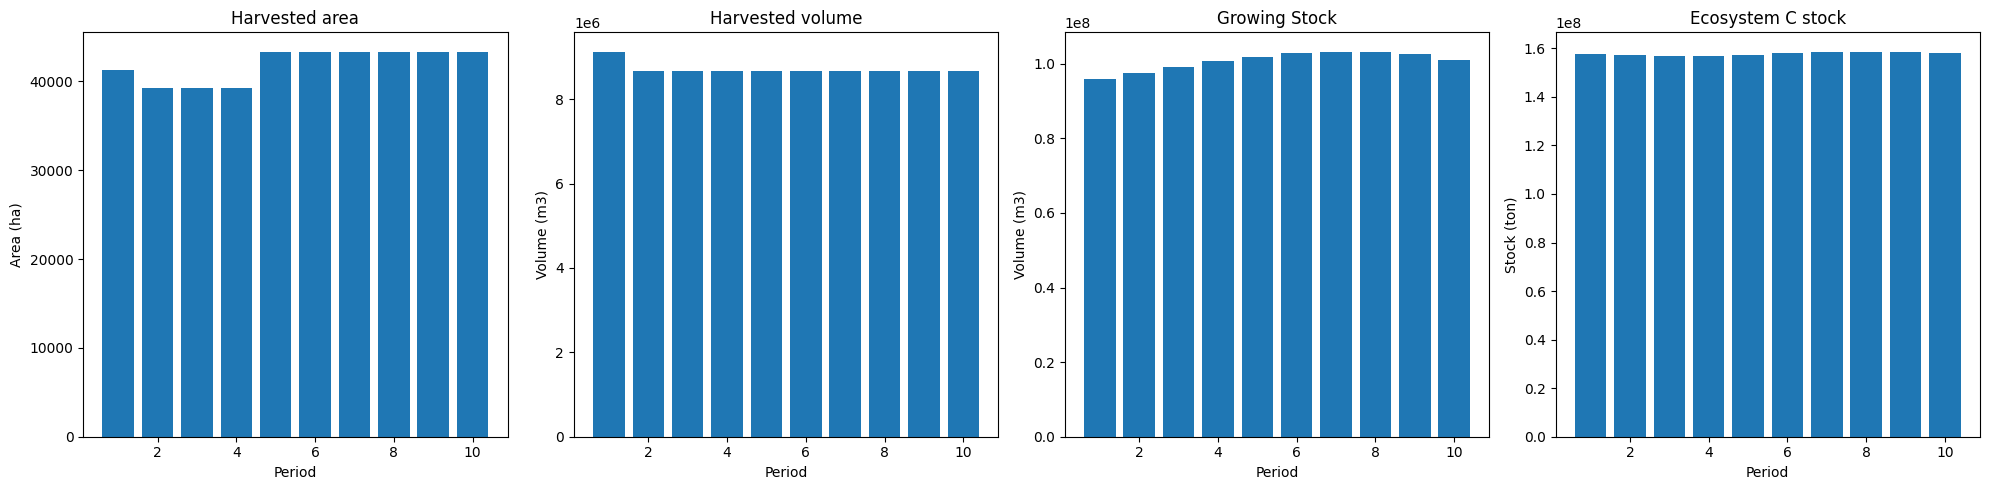

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


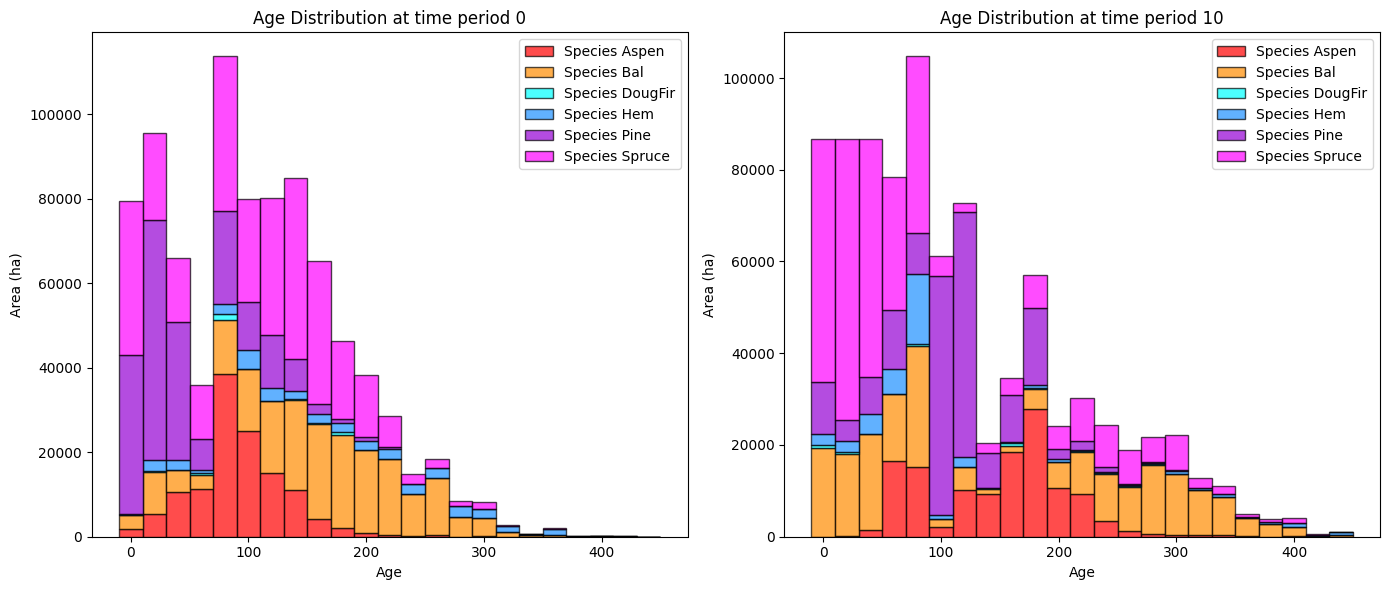

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


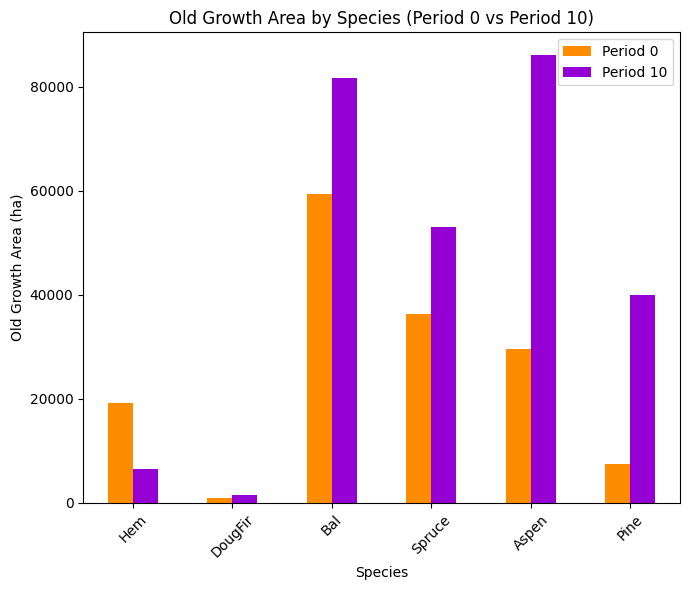

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


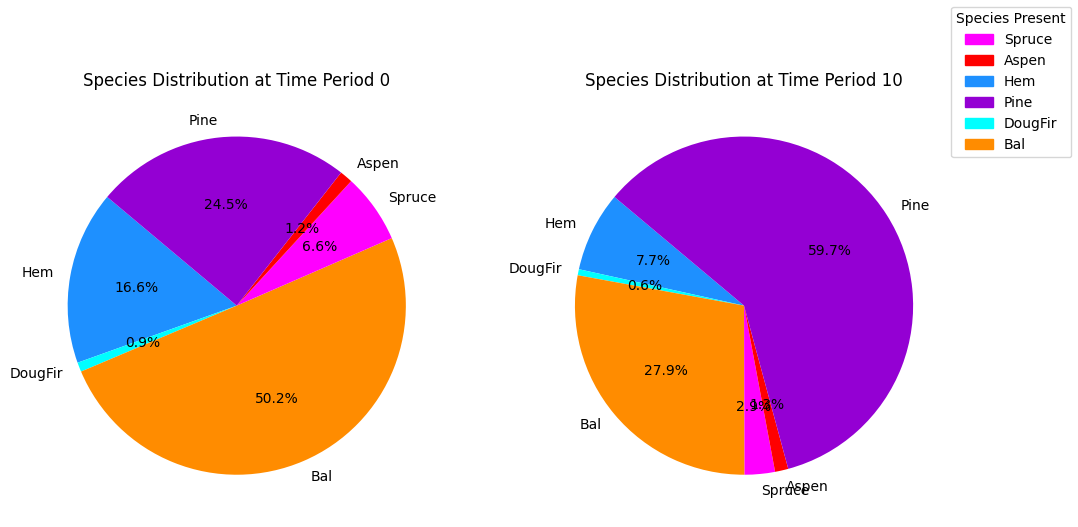

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


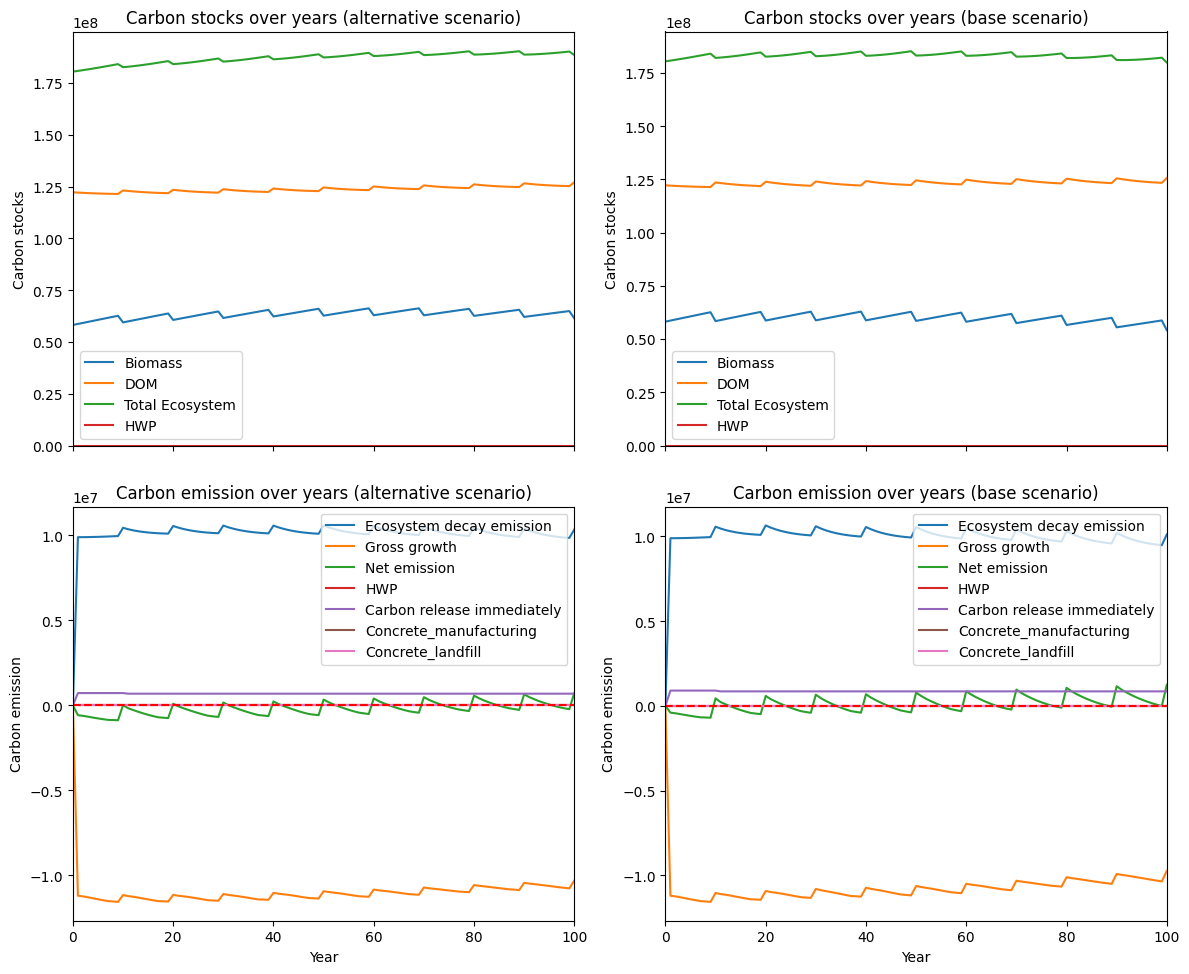

---------------------------------------------------------------------------------------
Net emission difference -7071860.4210010255
Net emission base scenario -12107664.276628058
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  1.4140550583129998
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   1259.950153   1259.950153
DougFir  0.0    562.142593    562.142593
Bal      0.0   9135.457210   9135.457210
Spruce   0.0    851.108549    851.108549
Aspen    0.0  18250.936030  18250.936030
Pine     0.0  16522.361493  16522.361493

Overall, the old growth area has **increased** by 46581.96 hectares in the alternative scenario compared to the base scenario.


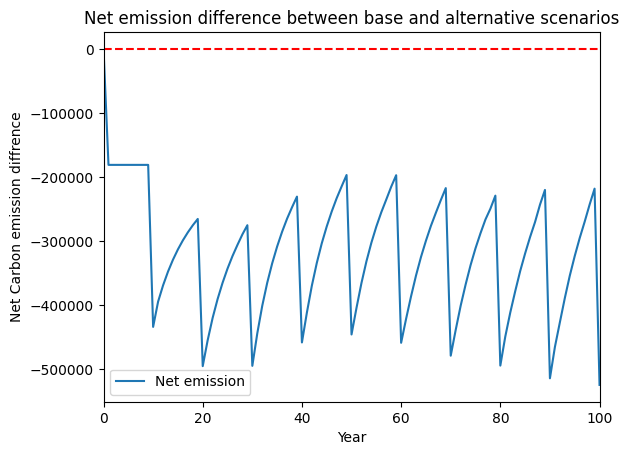

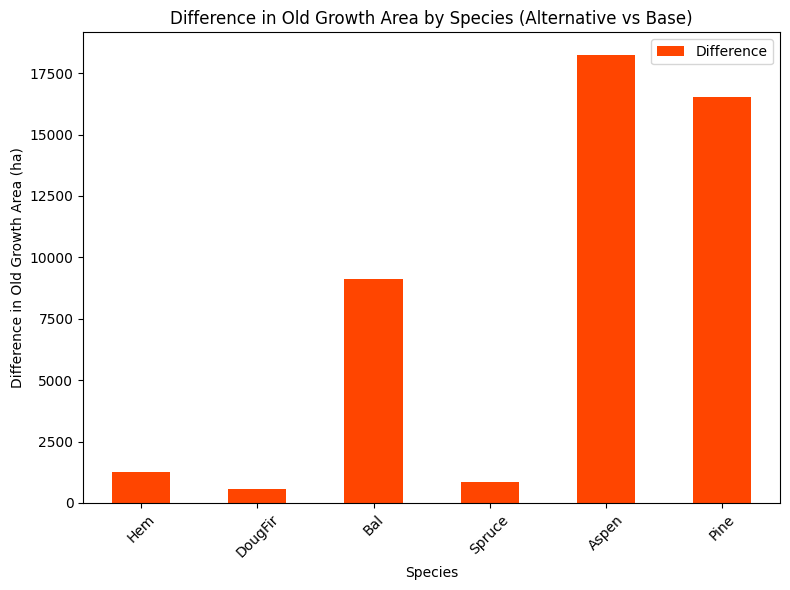

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


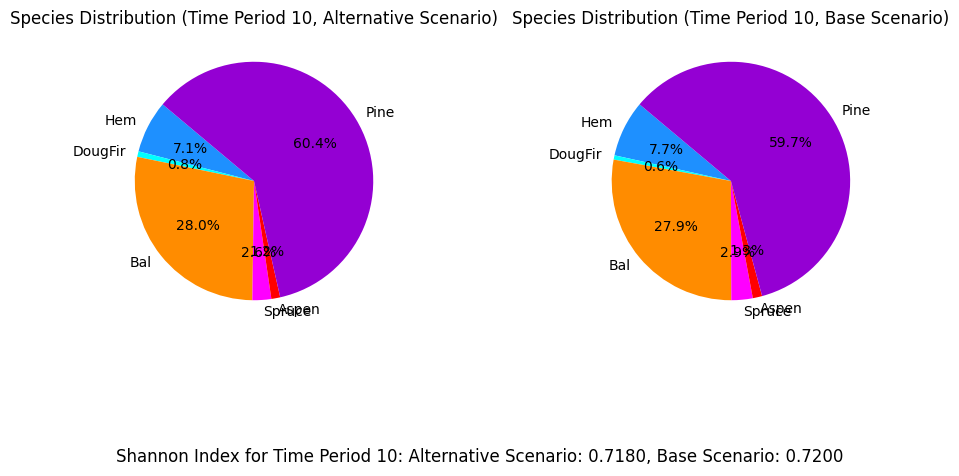

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_70%...
running the scenario for the Equity Silver mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x8a85111d
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 r

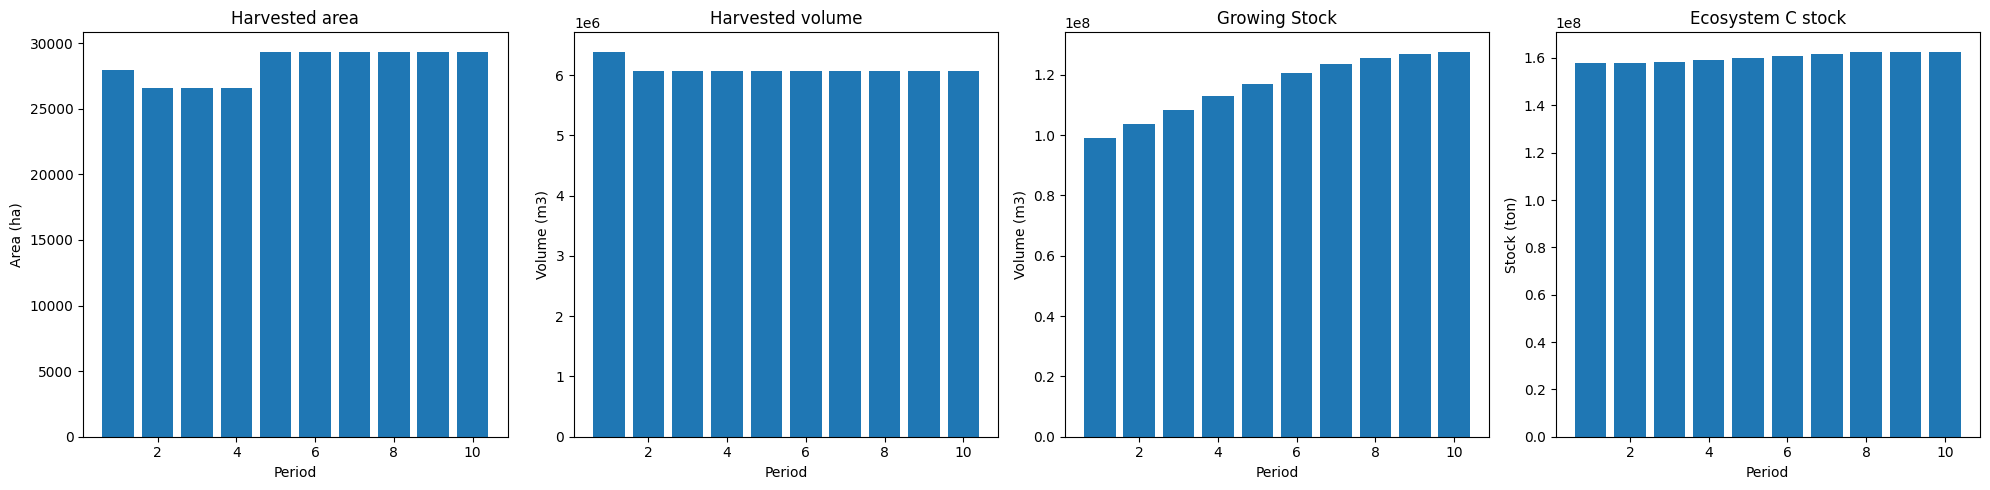

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  64510
The economic indicator (the provincial government revenues) is:  2199929
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


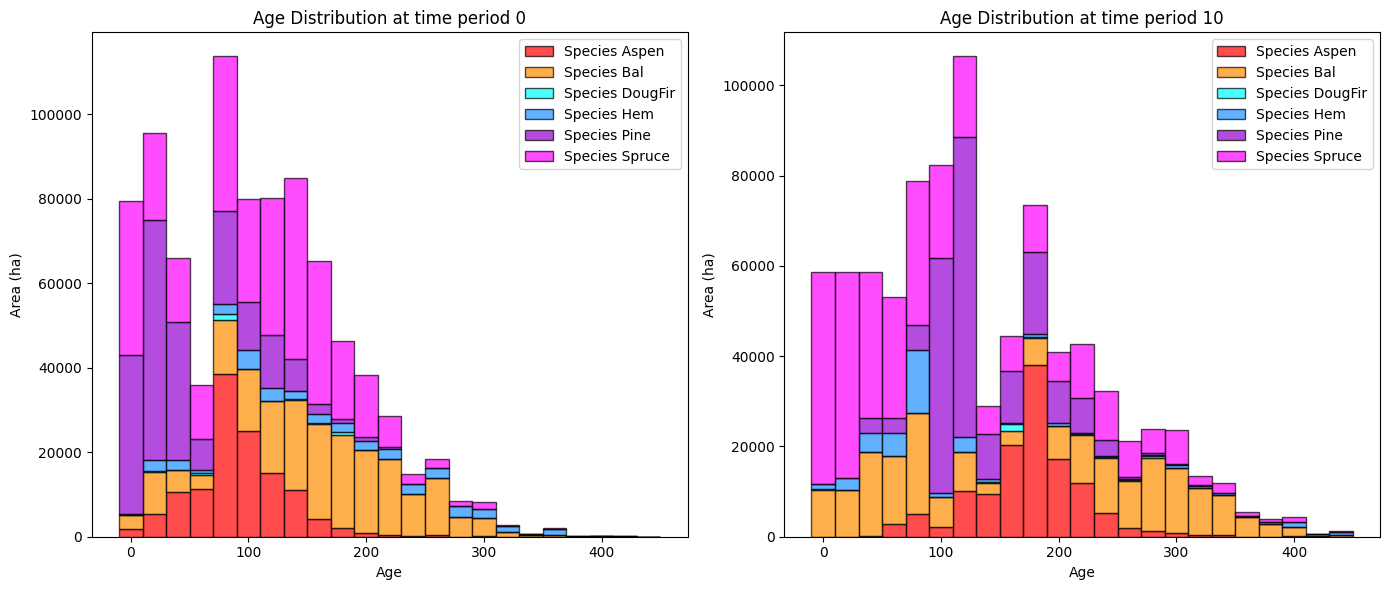

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    7928.717972 -11223.409257
DougFir    947.047810    2502.749050   1555.701240
Bal      59315.970469   92983.689385  33667.718916
Spruce   36410.744598   64777.090199  28366.345601
Aspen    29632.731169  111042.719692  81409.988523
Pine      7432.733686   61485.828632  54053.094946

Overall diversity has **increased** by 187829.44 hectares from time period 0 to time period 10.


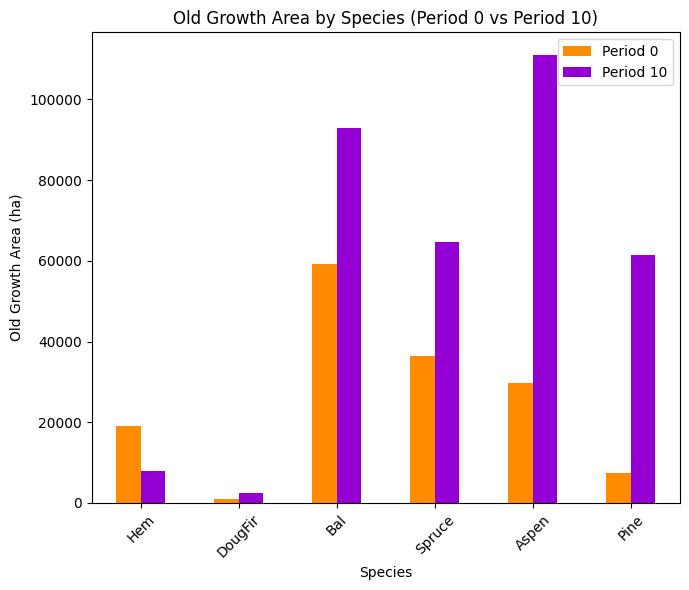

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7216

Diversity has **decreased** by 3.75% from time 0 to time 10.


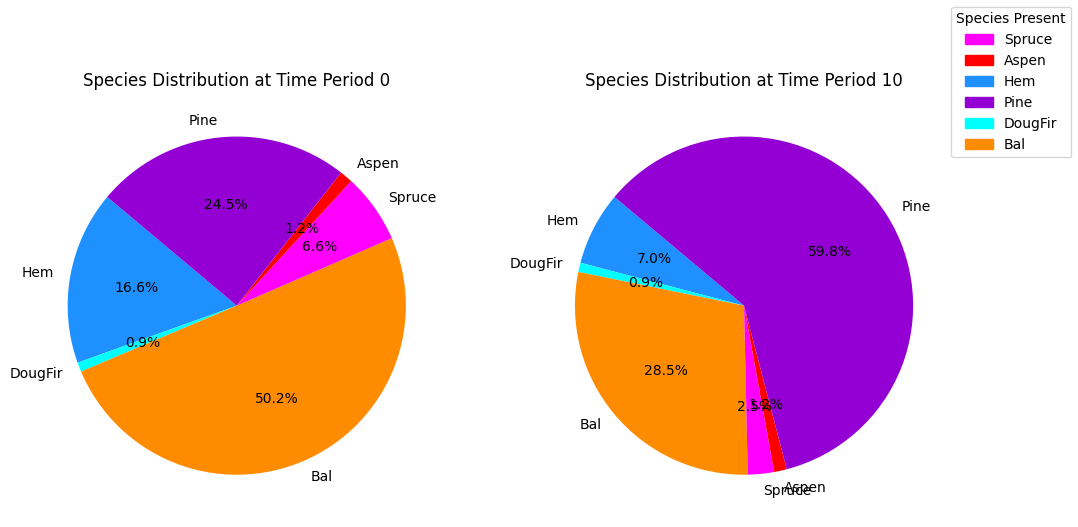

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

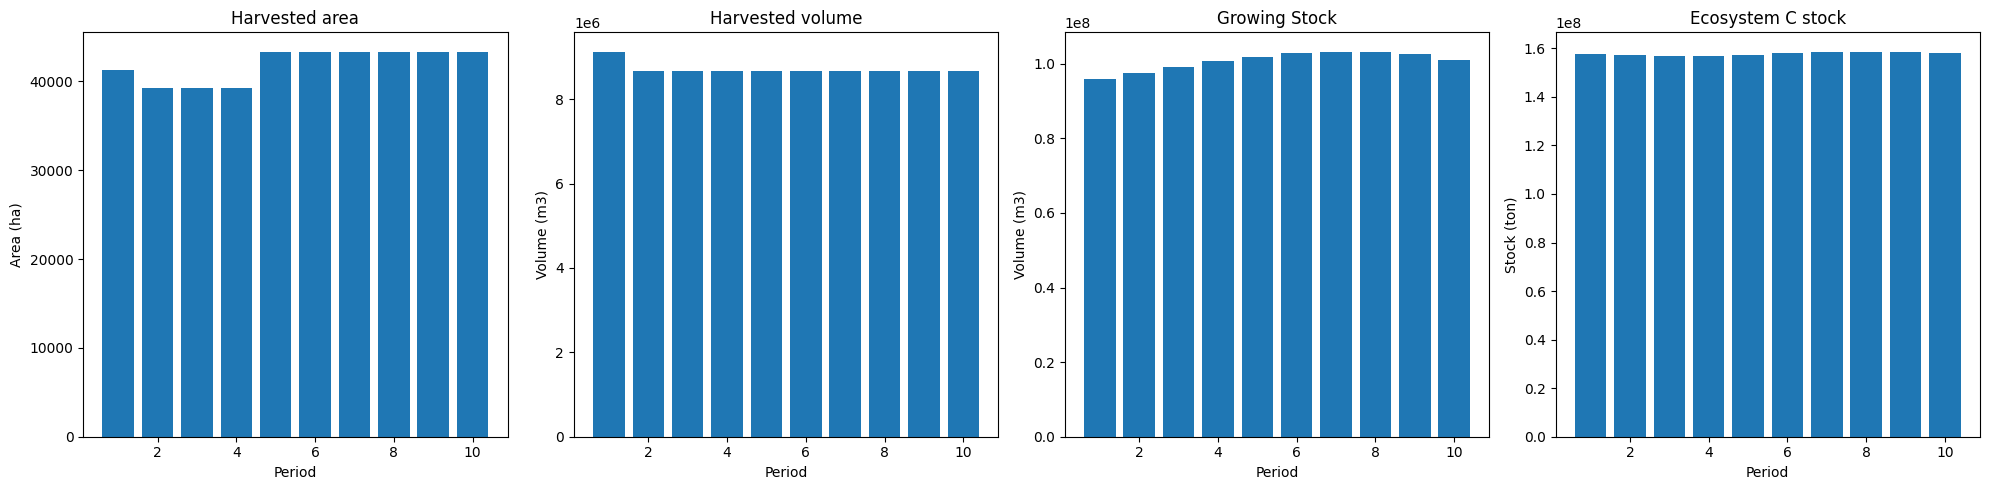

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


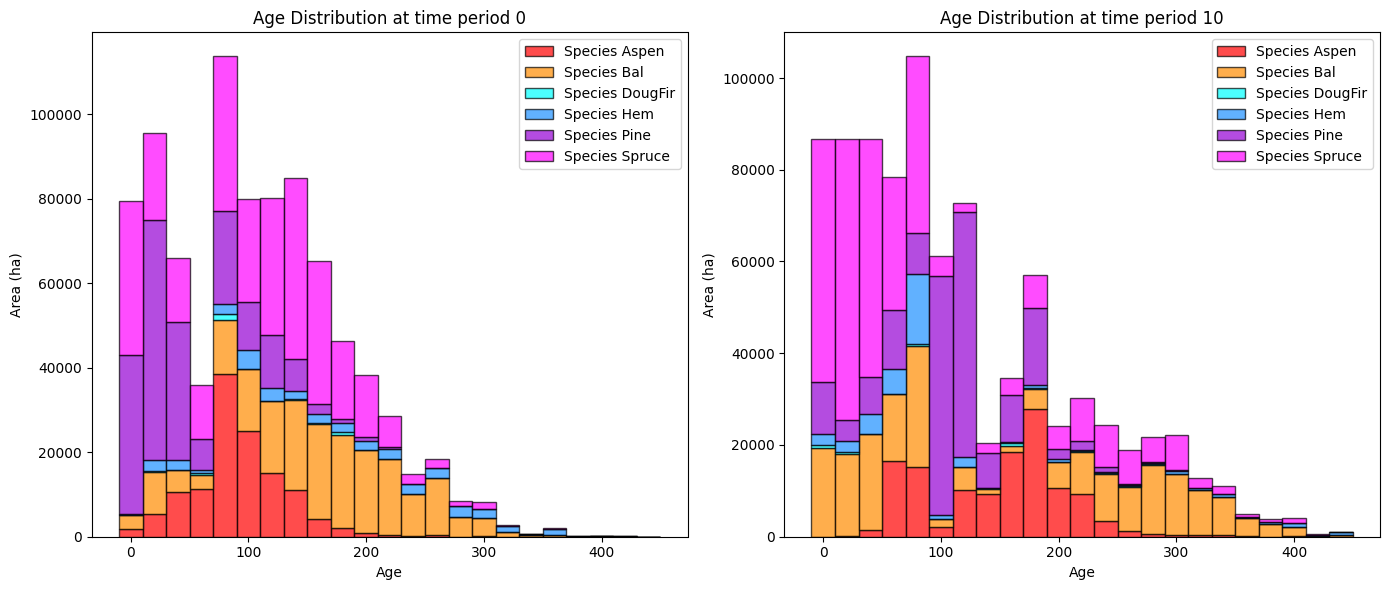

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


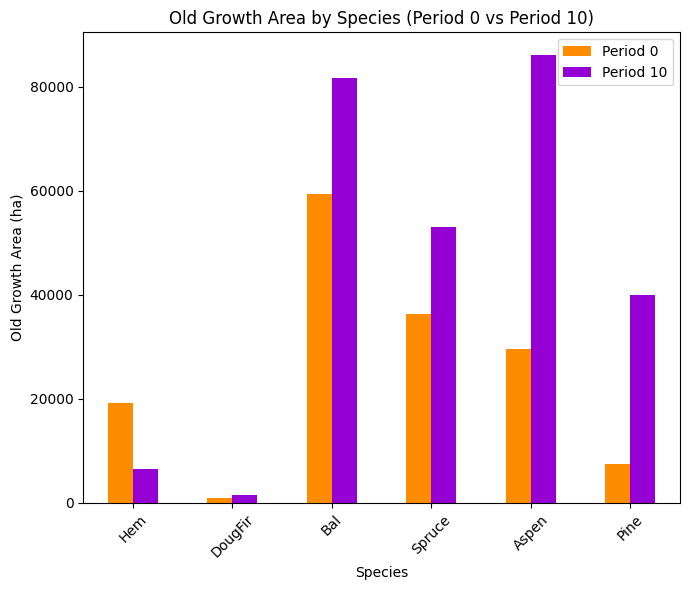

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


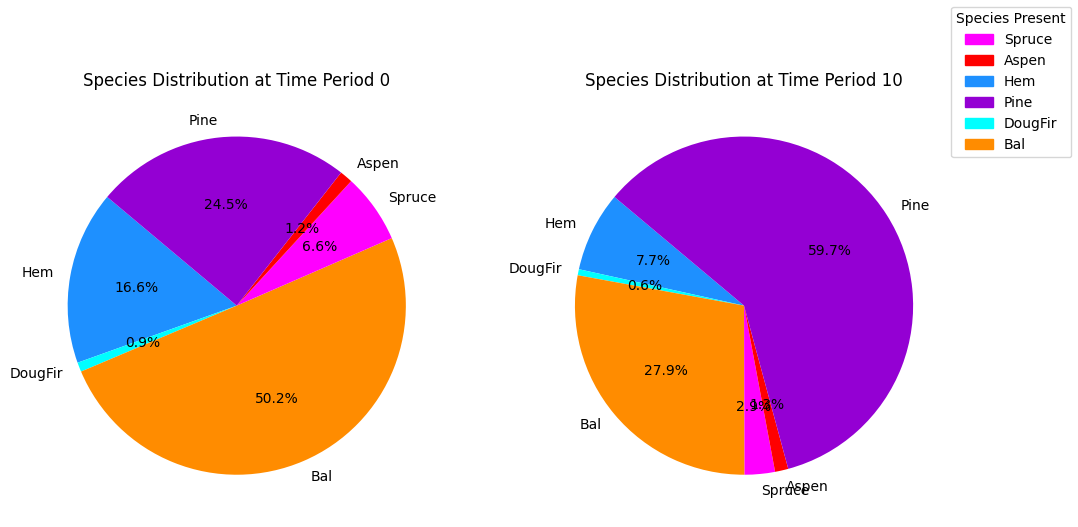

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


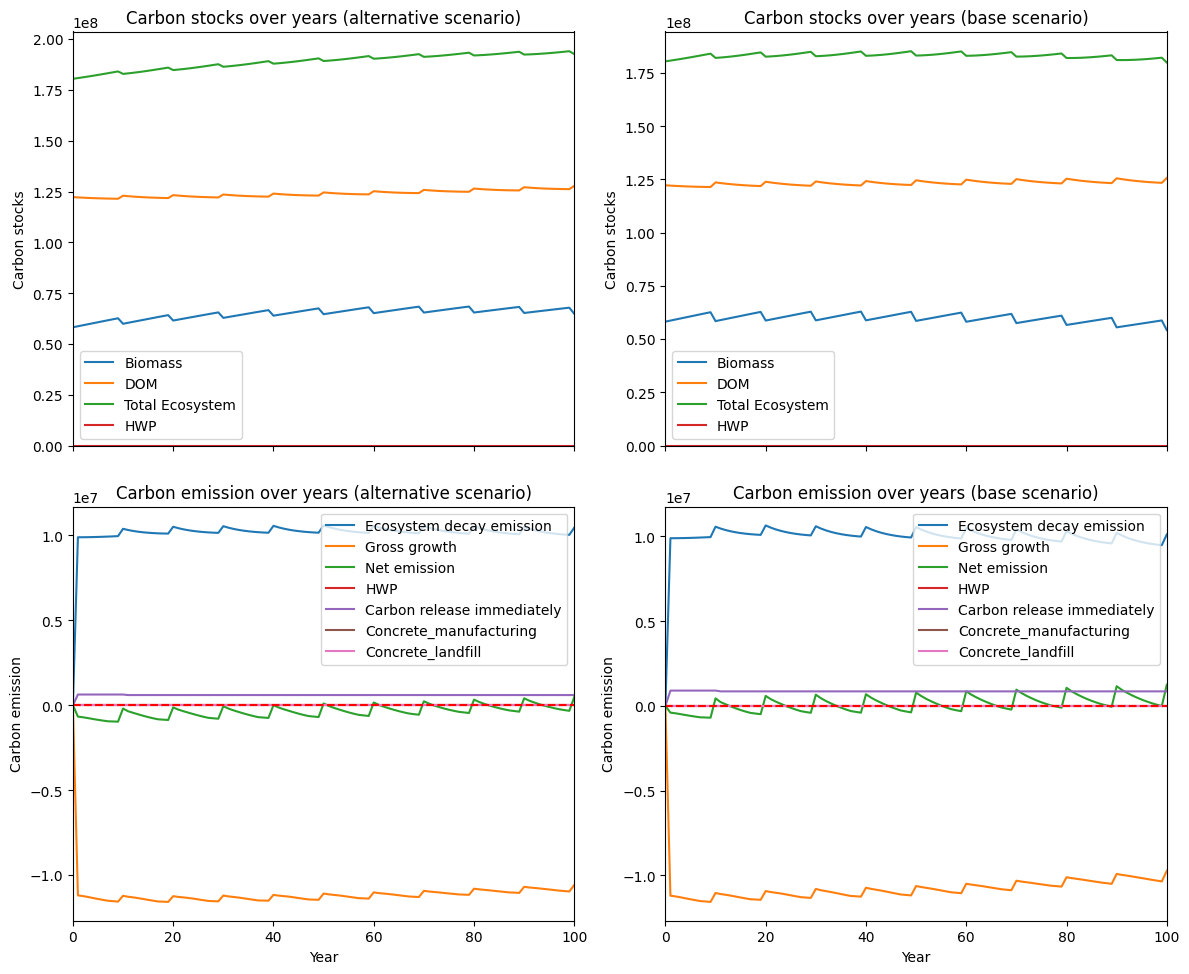

---------------------------------------------------------------------------------------
Net emission difference -10319947.763481675
Net emission base scenario -15355751.619108709
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.9689971528137141
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   1319.541088   1319.541088
DougFir  0.0   1026.622237   1026.622237
Bal      0.0  11227.779432  11227.779432
Spruce   0.0  11750.987101  11750.987101
Aspen    0.0  24912.132739  24912.132739
Pine     0.0  21483.698675  21483.698675

Overall, the old growth area has **increased** by 71720.76 hectares in the alternative scenario compared to the base scenario.


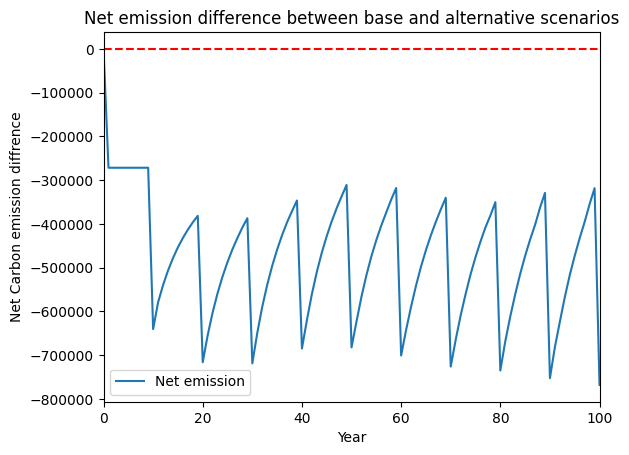

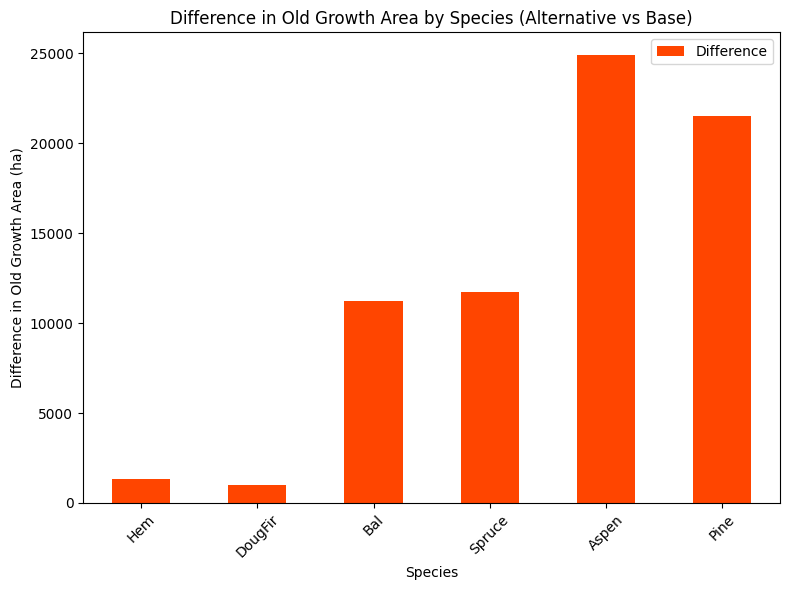

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


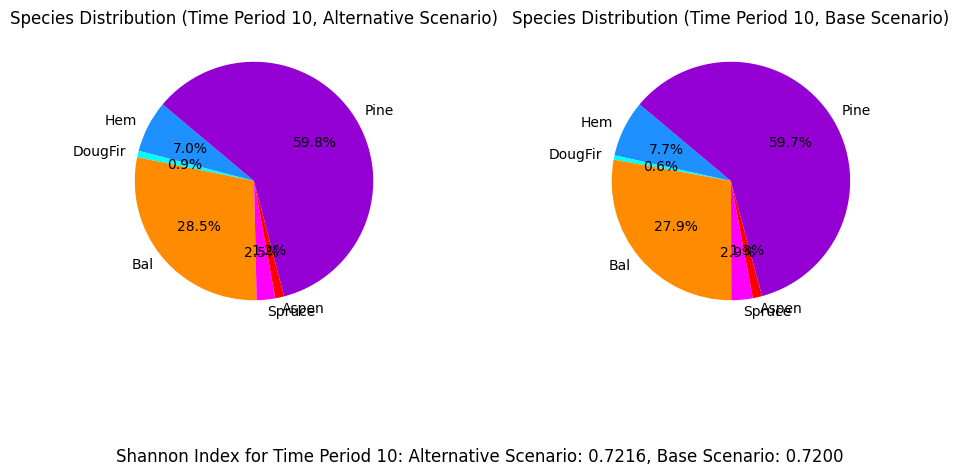

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_60%...
running the scenario for the Equity Silver mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x4f245d56
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.31s
Presolved: 8375 r

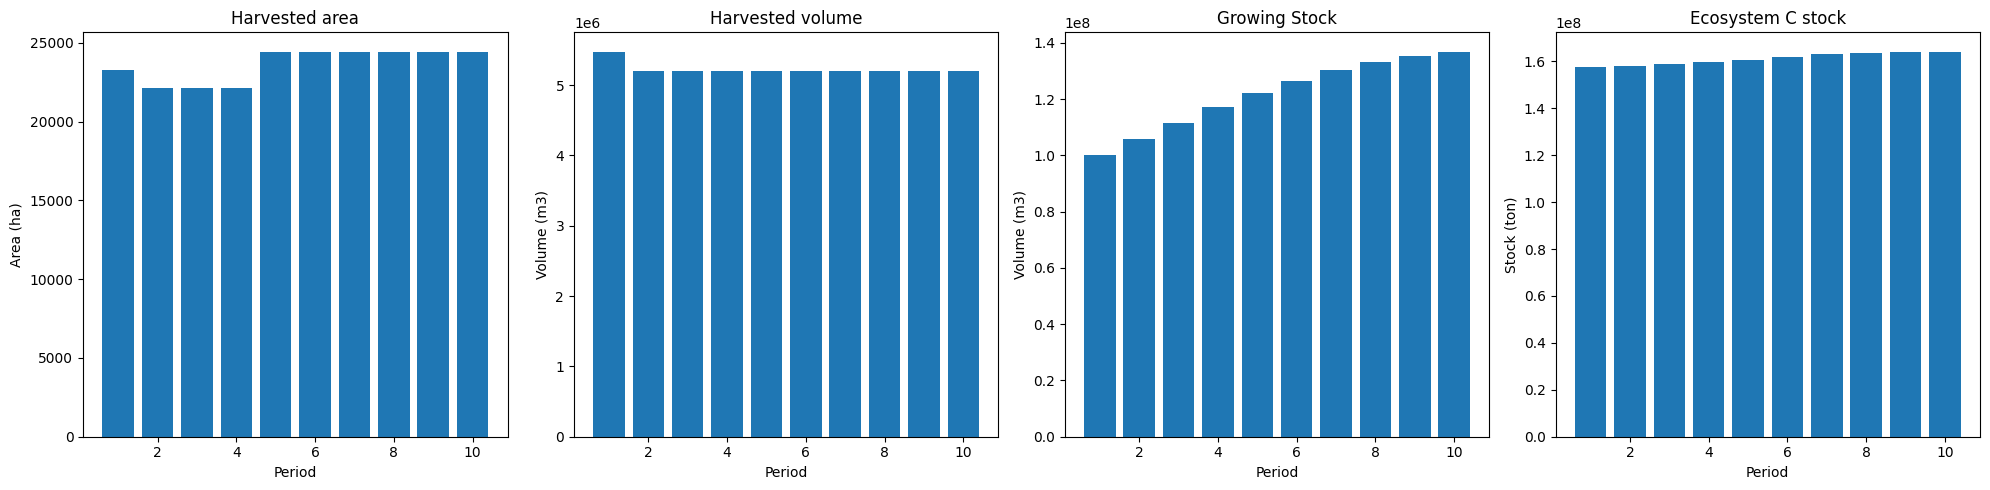

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  55294
The economic indicator (the provincial government revenues) is:  1885654
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


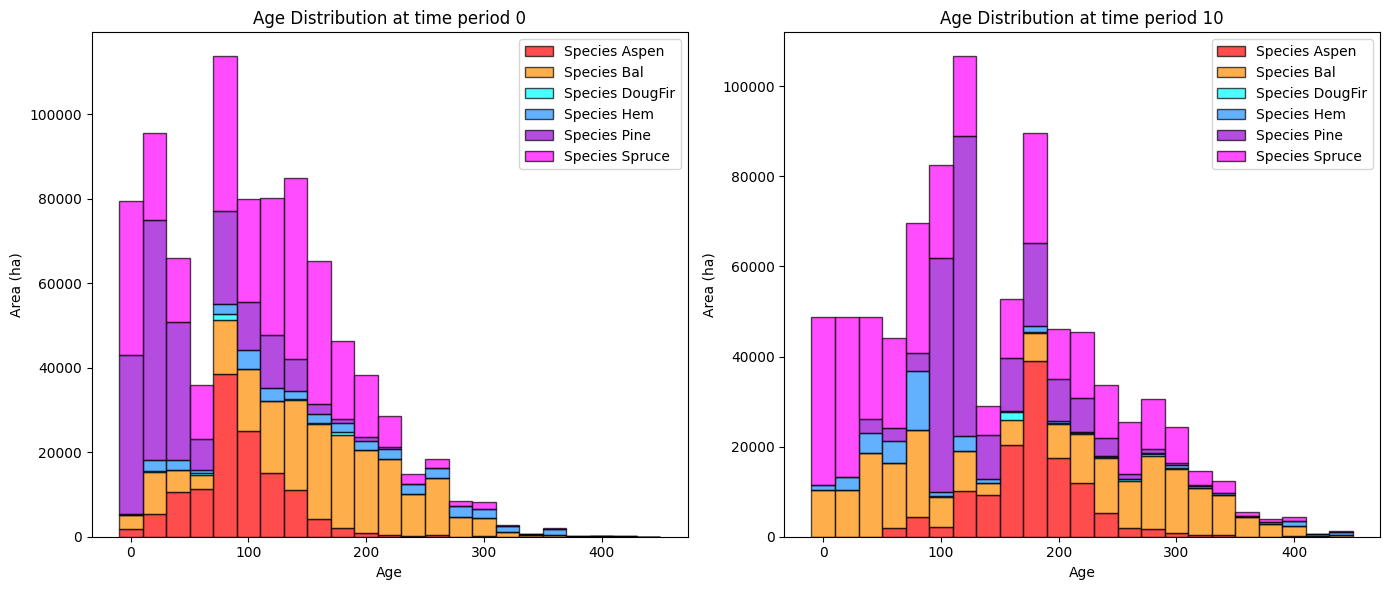

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    8700.022741 -10452.104487
DougFir    947.047810    2587.448146   1640.400336
Bal      59315.970469   94716.579521  35400.609053
Spruce   36410.744598   94657.755885  58247.011287
Aspen    29632.731169  112825.231167  83192.499998
Pine      7432.733686   63665.381800  56232.648114

Overall diversity has **increased** by 224261.06 hectares from time period 0 to time period 10.


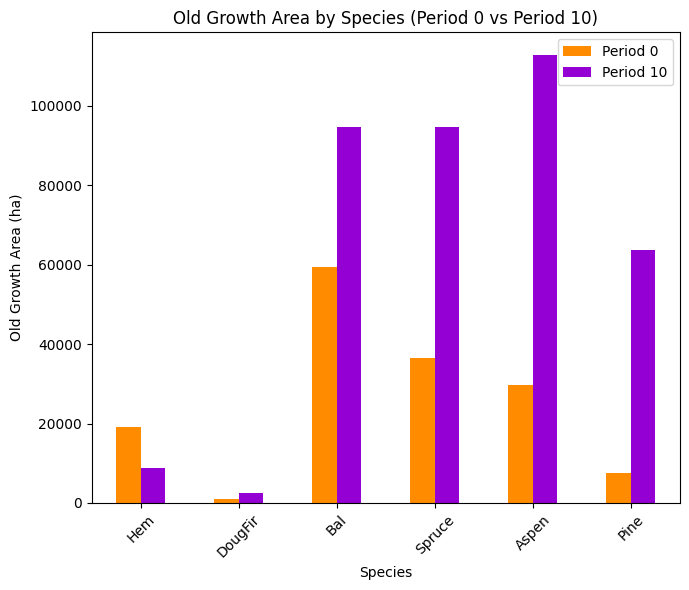

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7208

Diversity has **decreased** by 3.84% from time 0 to time 10.


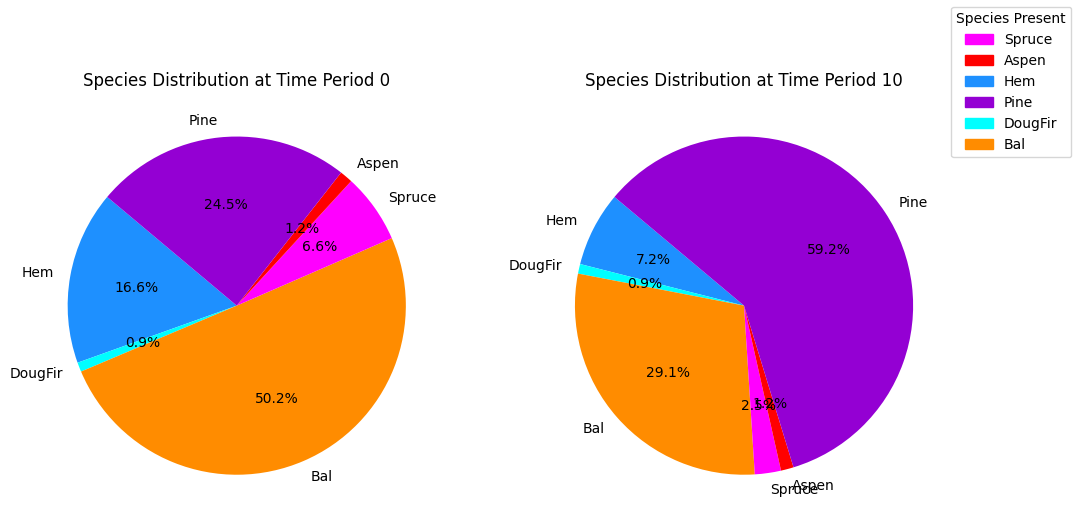

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

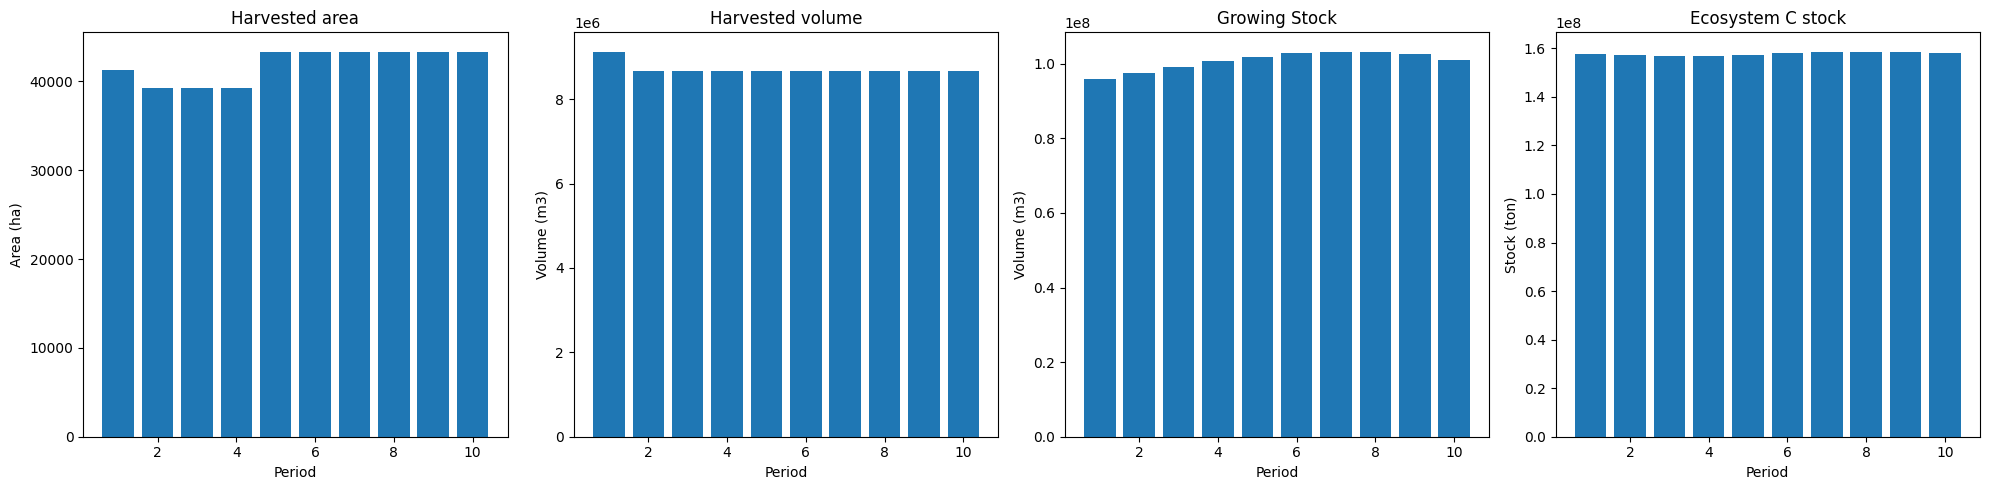

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


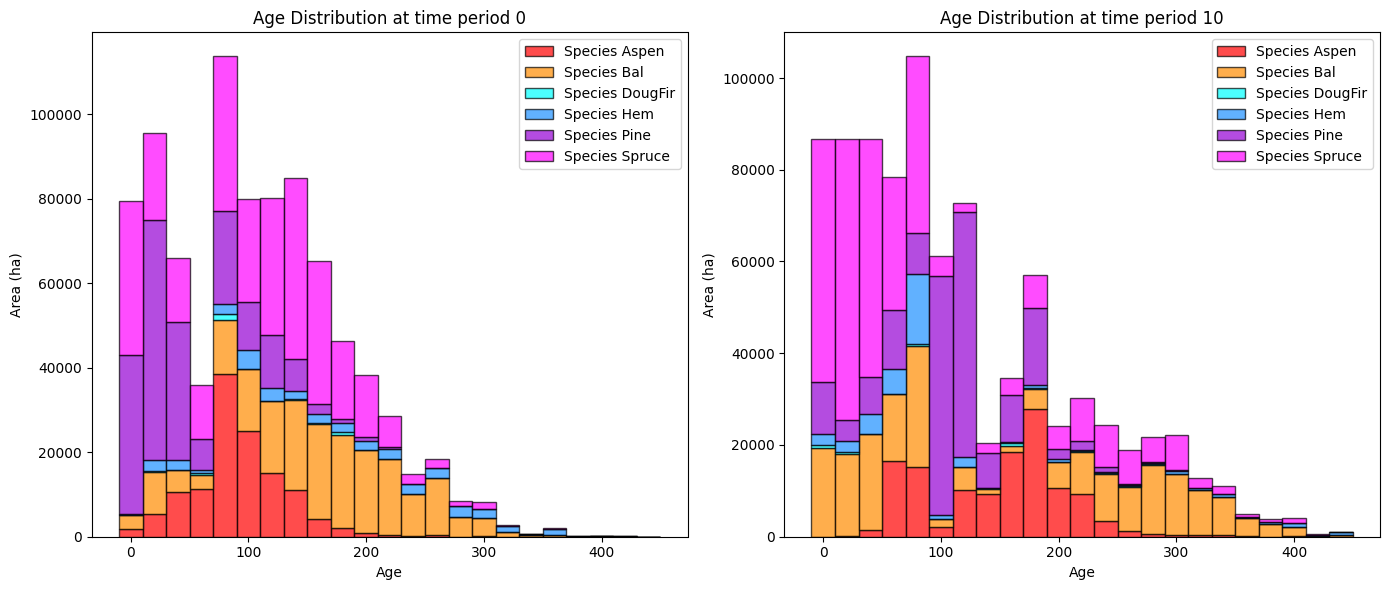

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


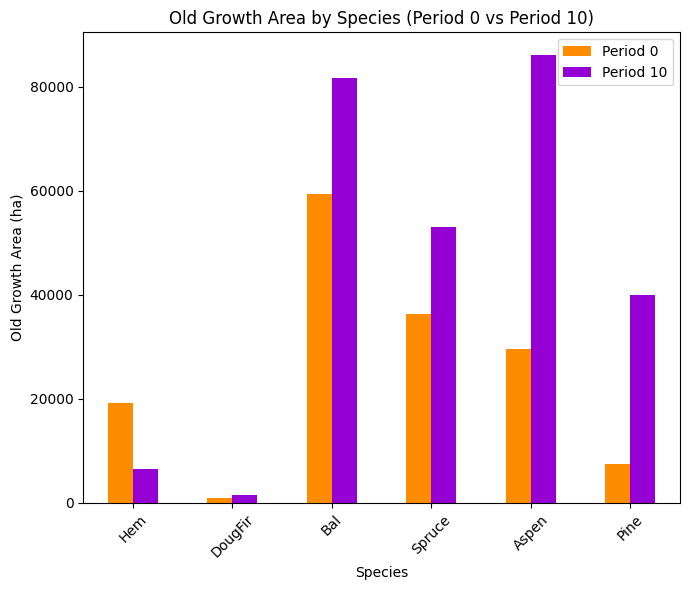

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


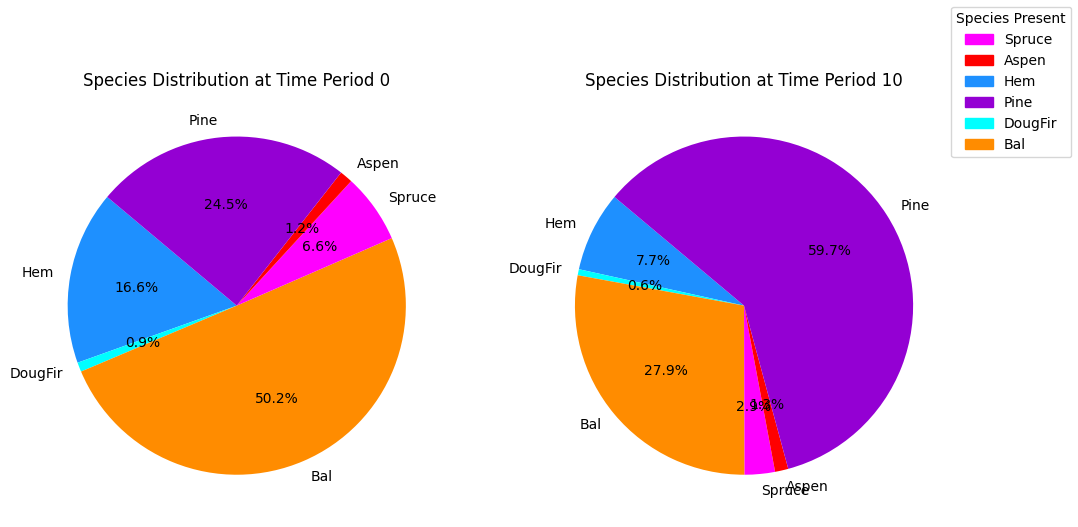

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


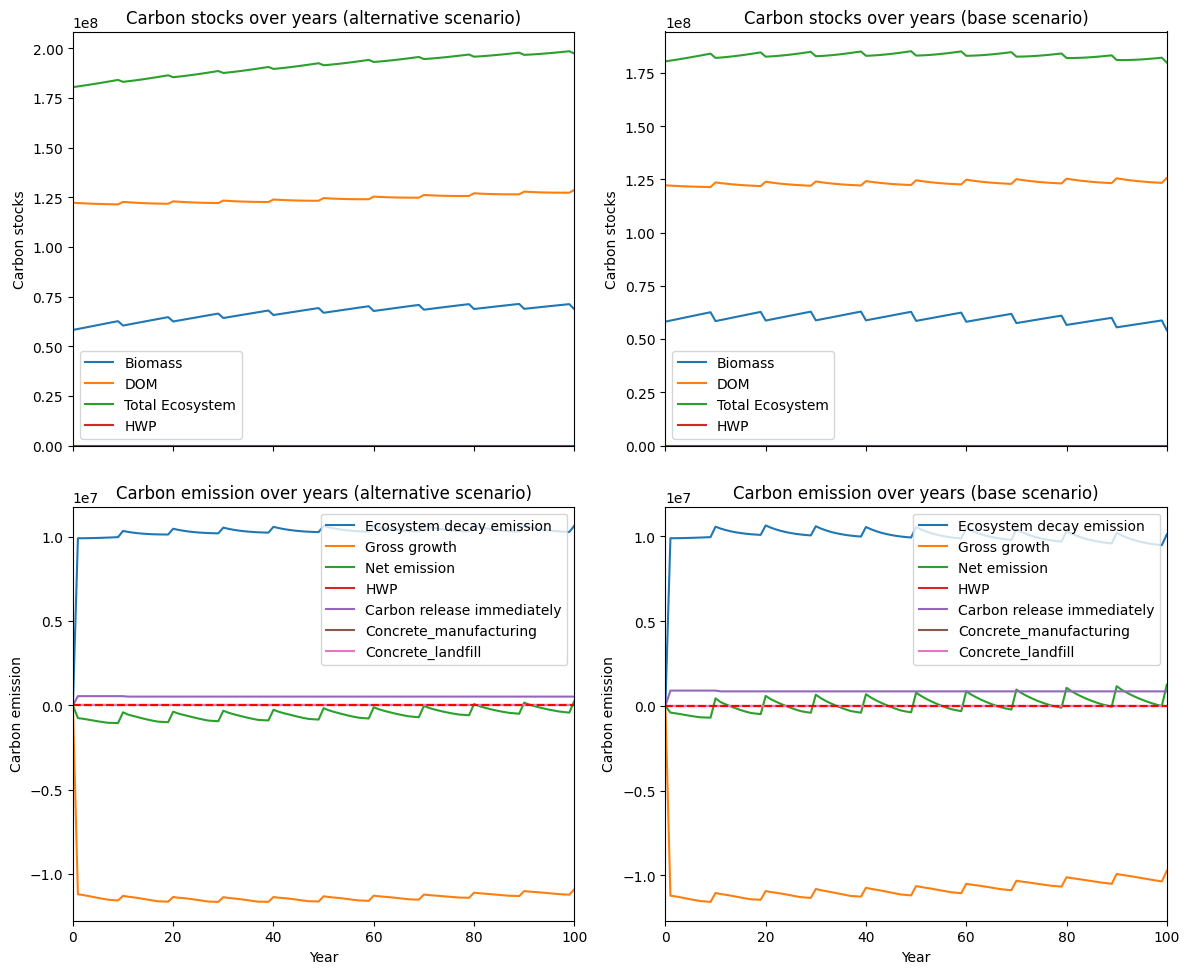

---------------------------------------------------------------------------------------
Net emission difference -13899817.914213987
Net emission base scenario -18935621.769841023
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.7194338847974386
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   2090.845858   2090.845858
DougFir  0.0   1111.321333   1111.321333
Bal      0.0  12960.669569  12960.669569
Spruce   0.0  41631.652787  41631.652787
Aspen    0.0  26694.644214  26694.644214
Pine     0.0  23663.251843  23663.251843

Overall, the old growth area has **increased** by 108152.39 hectares in the alternative scenario compared to the base scenario.


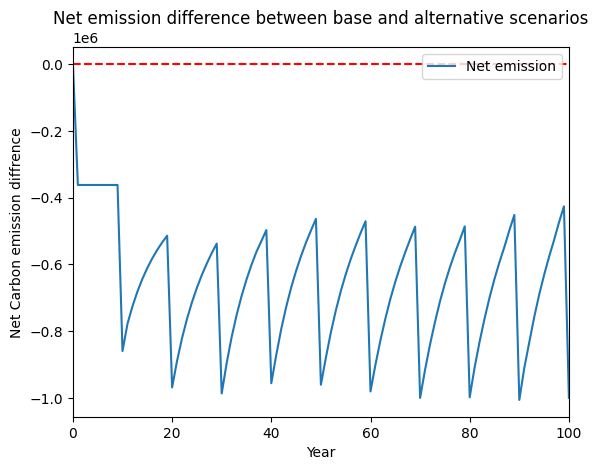

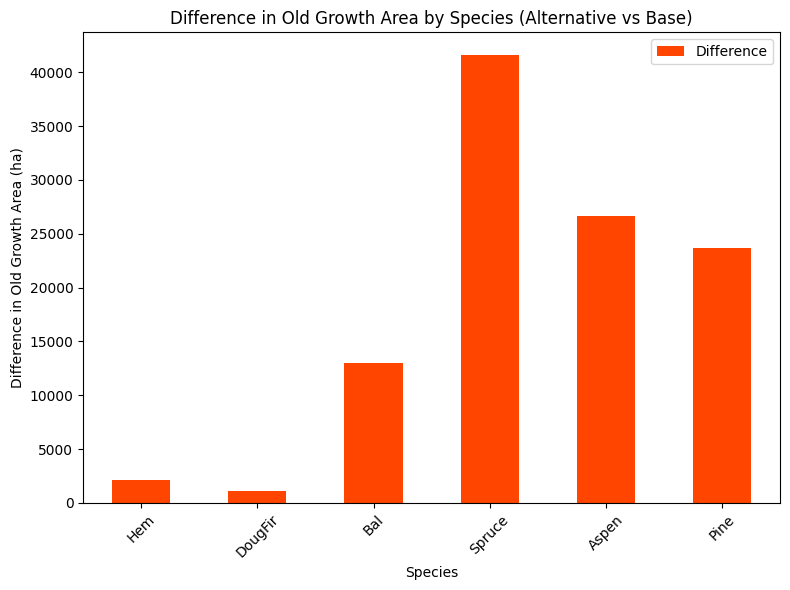

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


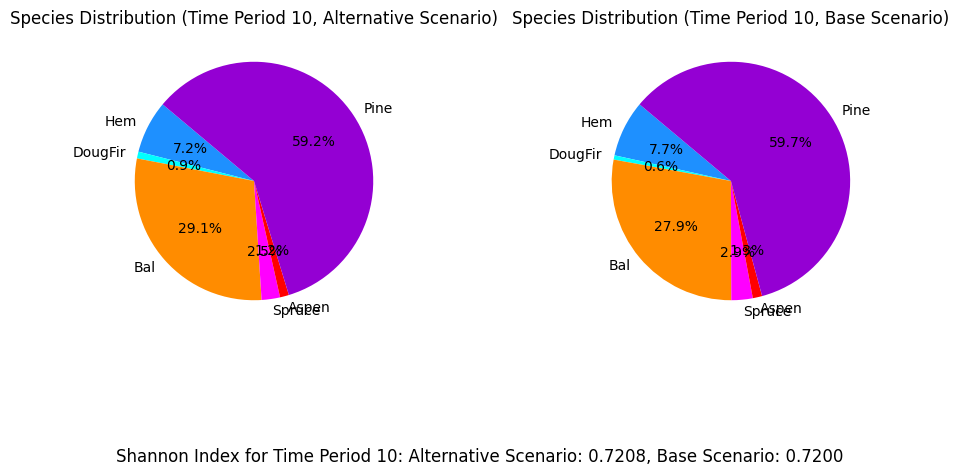

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_50%...
running the scenario for the Equity Silver mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xe1b2ea1b
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 r

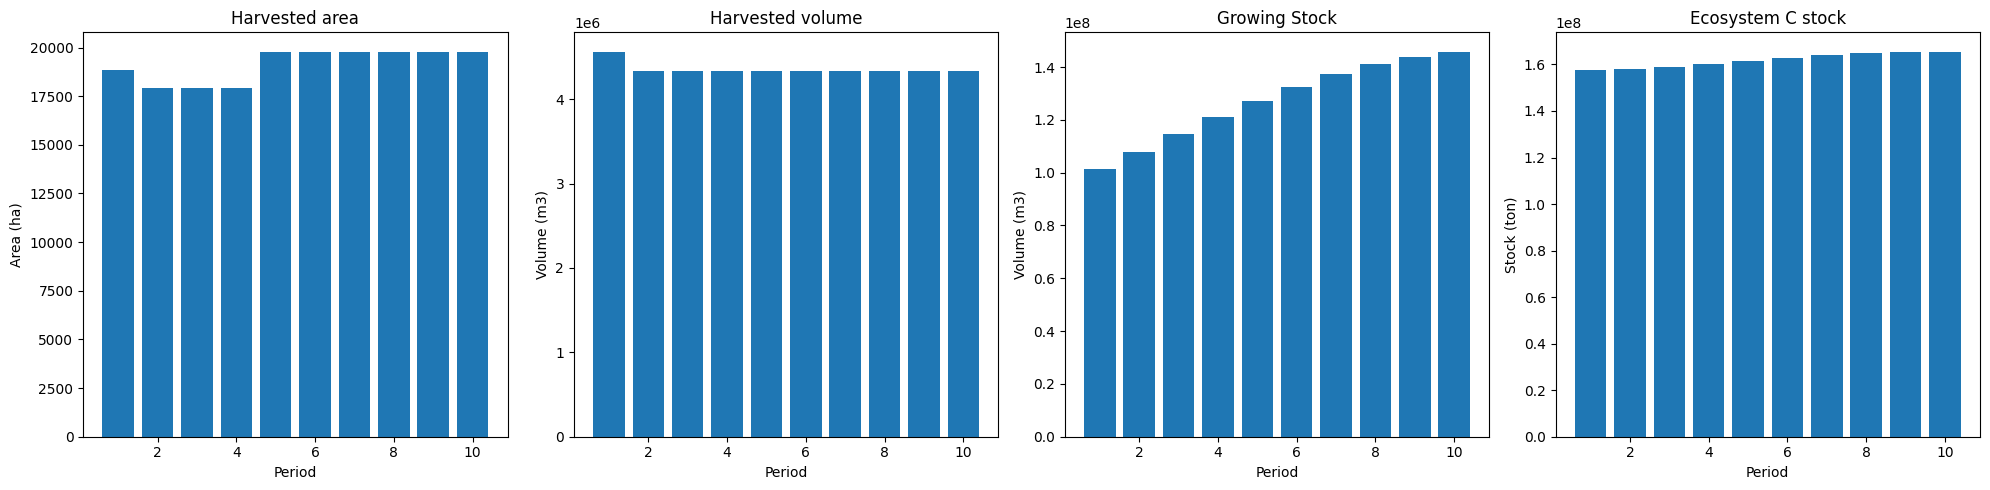

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  46078
The economic indicator (the provincial government revenues) is:  1571378
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


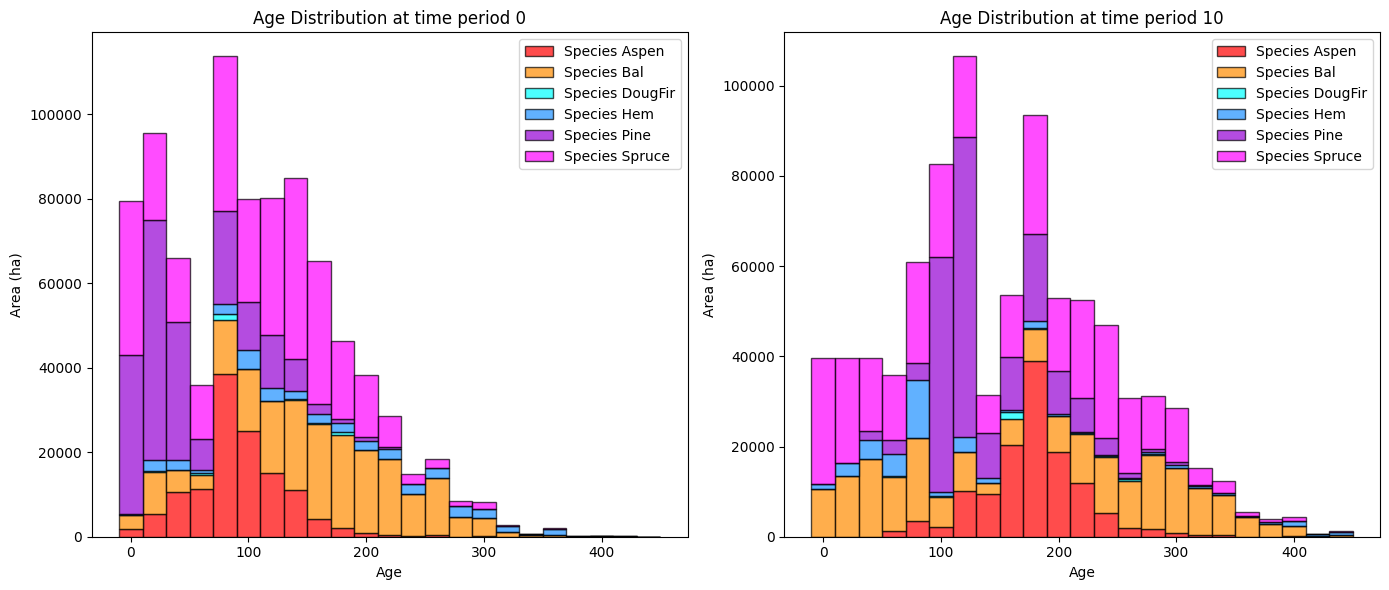

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    8976.370440 -10175.756789
DougFir    947.047810    2587.448146   1640.400336
Bal      59315.970469   95797.595136  36481.624667
Spruce   36410.744598  132875.912697  96465.168099
Aspen    29632.731169  114324.783990  84692.052821
Pine      7432.733686   64675.837444  57243.103758

Overall diversity has **increased** by 266346.59 hectares from time period 0 to time period 10.


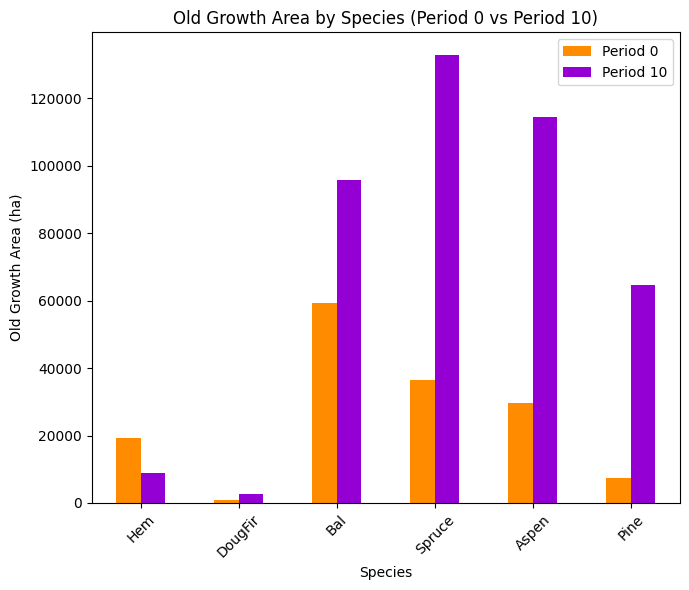

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7141

Diversity has **decreased** by 4.50% from time 0 to time 10.


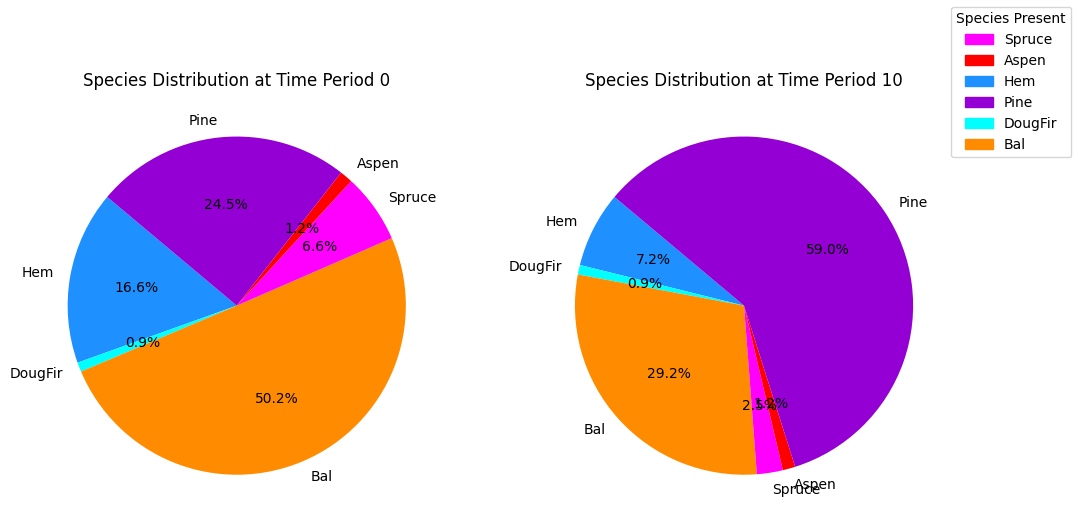

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

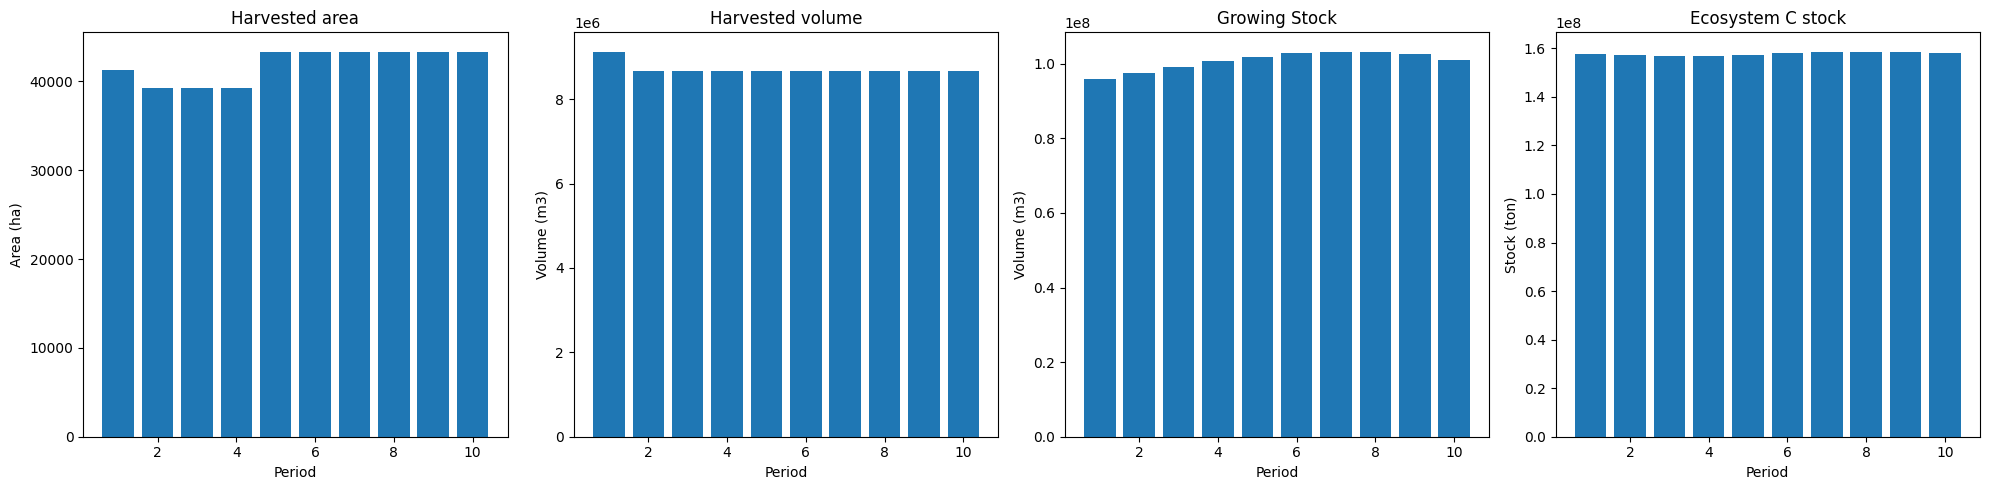

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


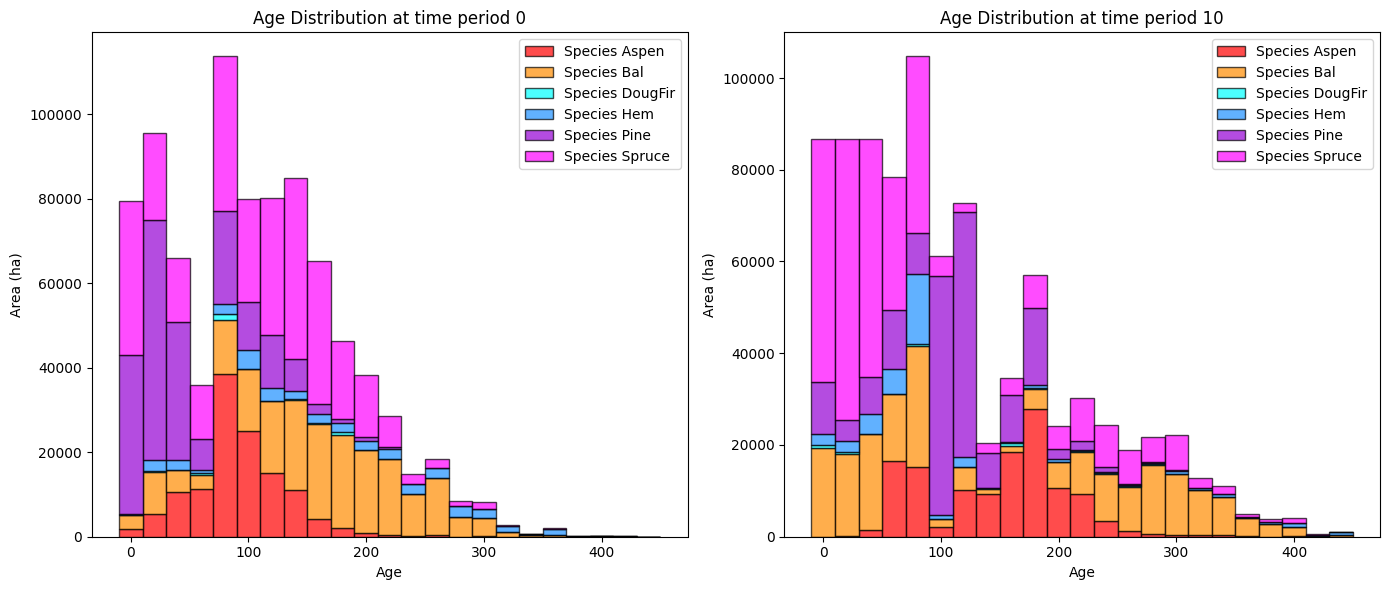

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


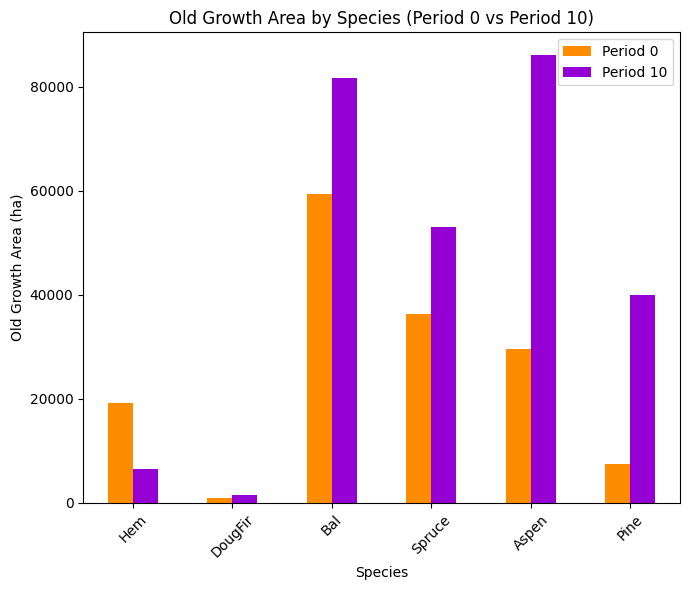

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


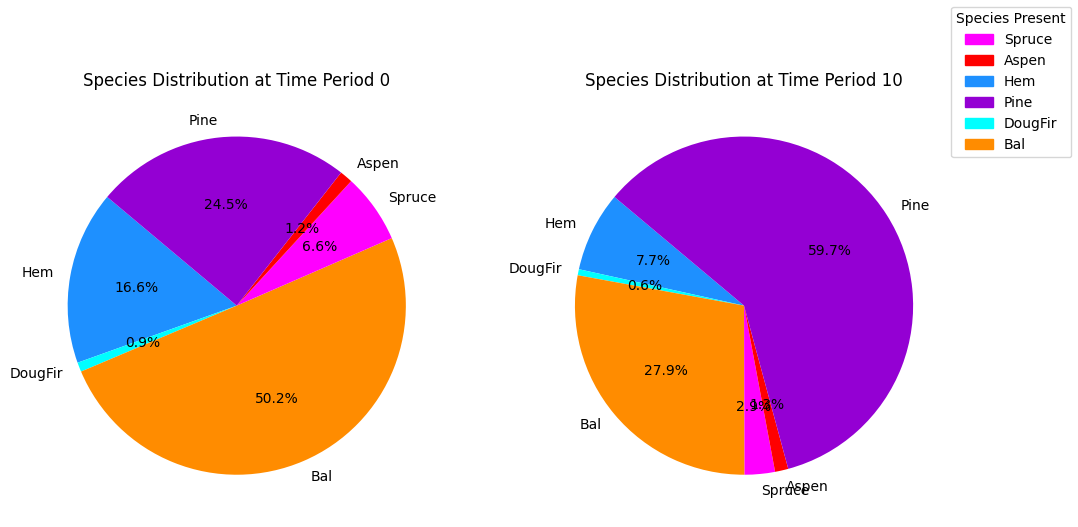

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


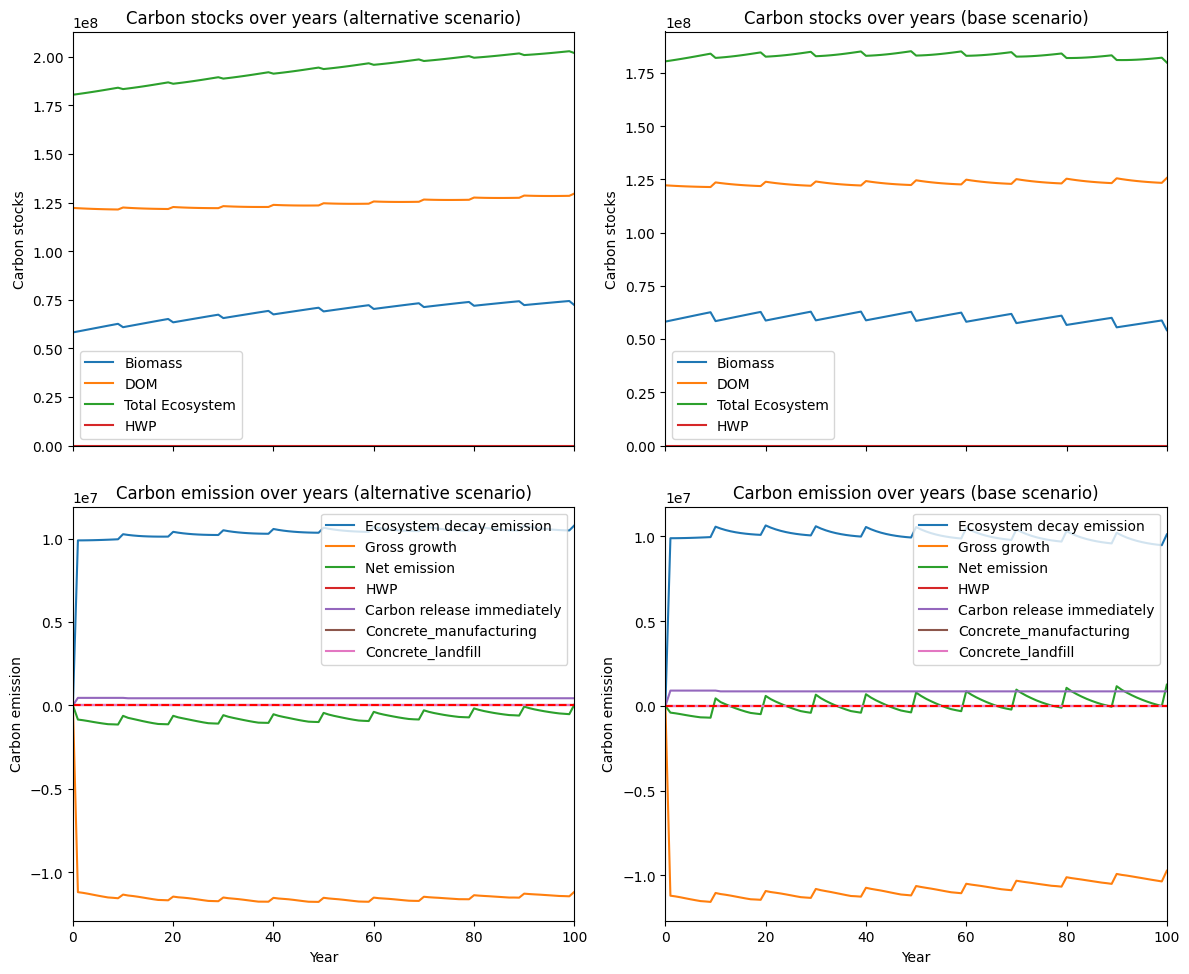

---------------------------------------------------------------------------------------
Net emission difference -17441156.685069248
Net emission base scenario -22476960.540696282
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.5733564682989543
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   2367.193556   2367.193556
DougFir  0.0   1111.321333   1111.321333
Bal      0.0  14041.685183  14041.685183
Spruce   0.0  79849.809599  79849.809599
Aspen    0.0  28194.197036  28194.197036
Pine     0.0  24673.707488  24673.707488

Overall, the old growth area has **increased** by 150237.91 hectares in the alternative scenario compared to the base scenario.


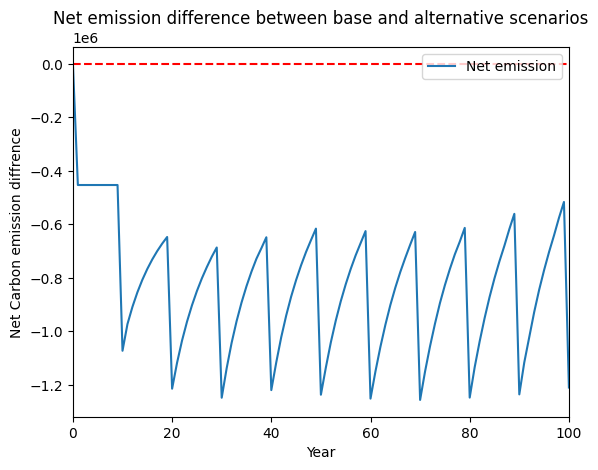

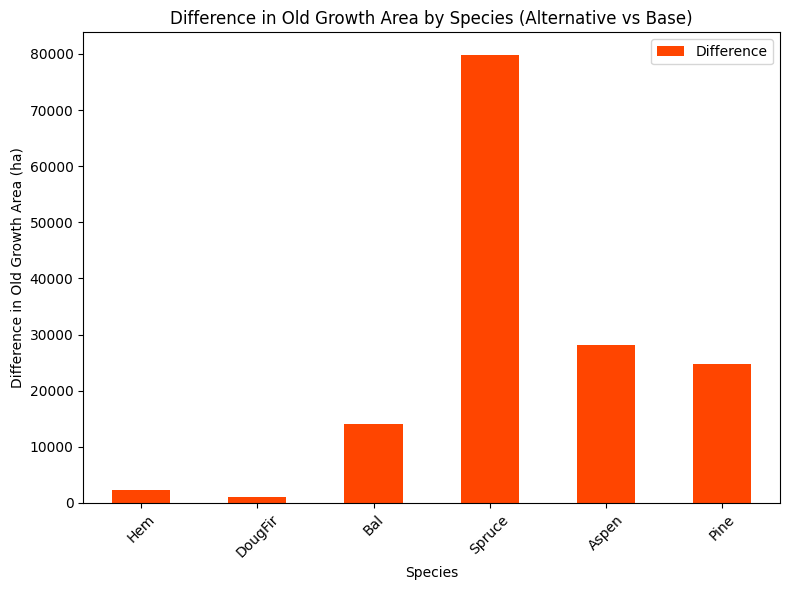

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


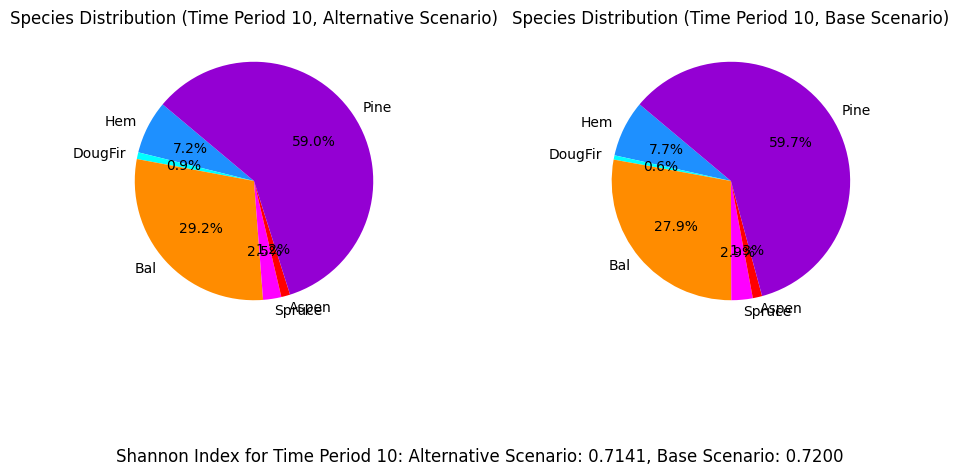

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_40%...
running the scenario for the Equity Silver mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9e366a03
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.26s
Presolved: 8375 r

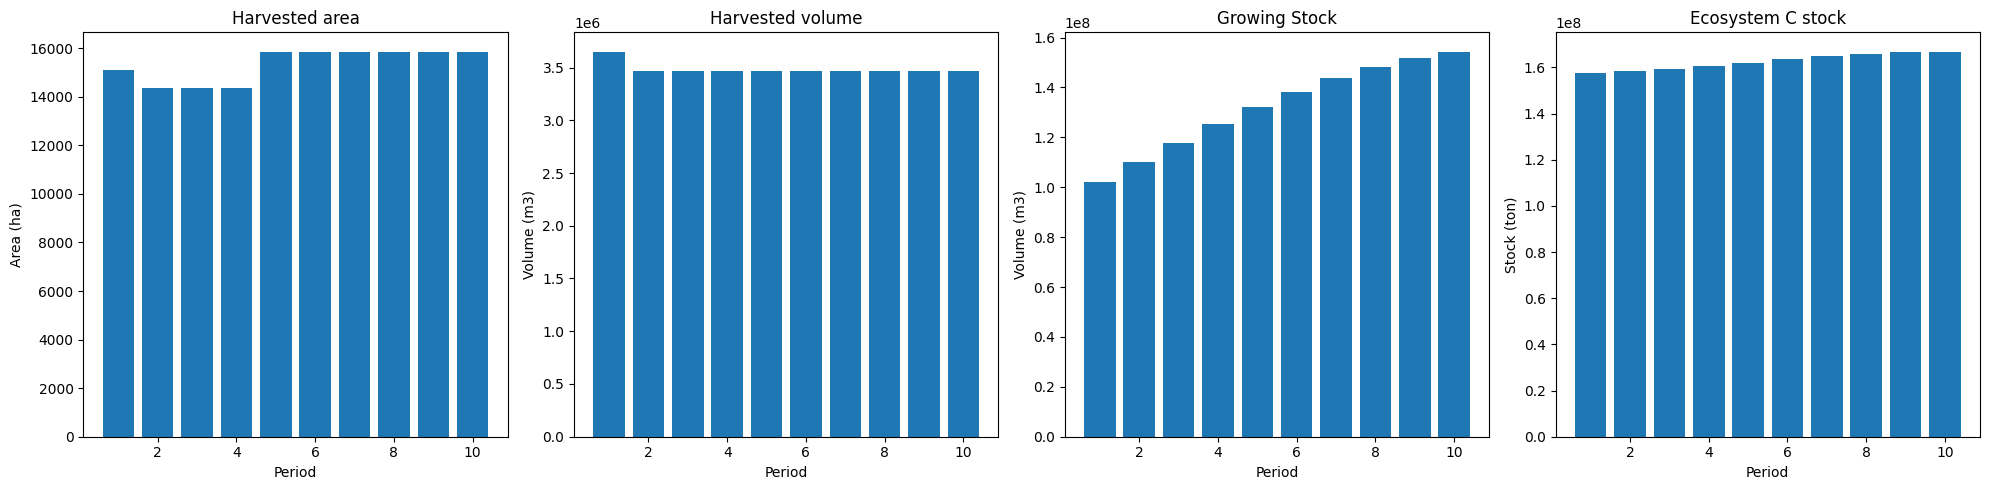

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  36862
The economic indicator (the provincial government revenues) is:  1257102
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


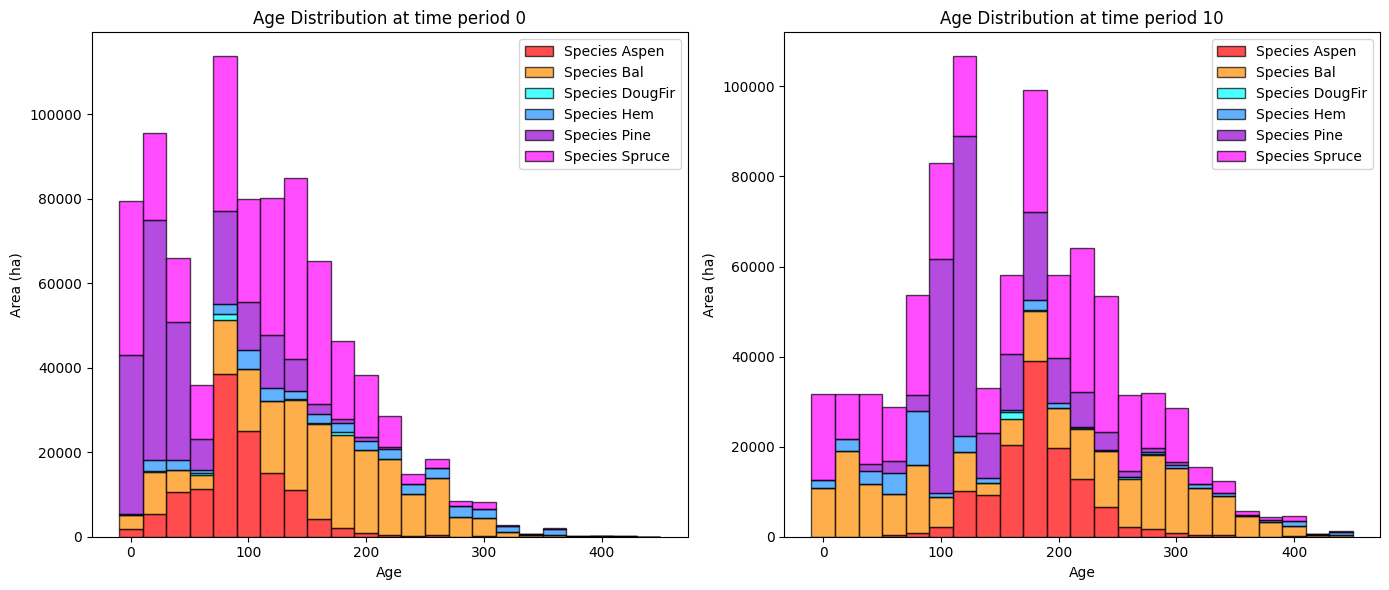

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   10735.610532   -8416.516697
DougFir    947.047810    2607.841586    1660.793776
Bal      59315.970469   99487.314171   40171.343702
Spruce   36410.744598  154905.589190  118494.844592
Aspen    29632.731169  117852.853466   88220.122297
Pine      7432.733686   65861.455786   58428.722100

Overall diversity has **increased** by 298559.31 hectares from time period 0 to time period 10.


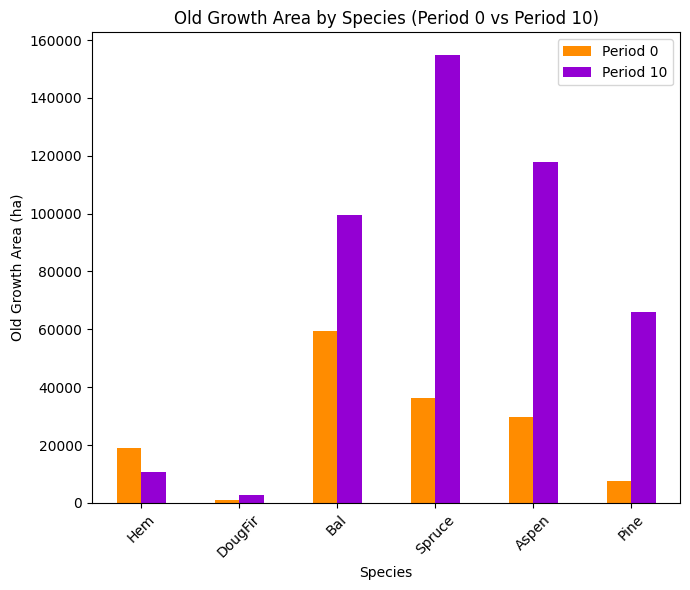

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7099

Diversity has **decreased** by 4.93% from time 0 to time 10.


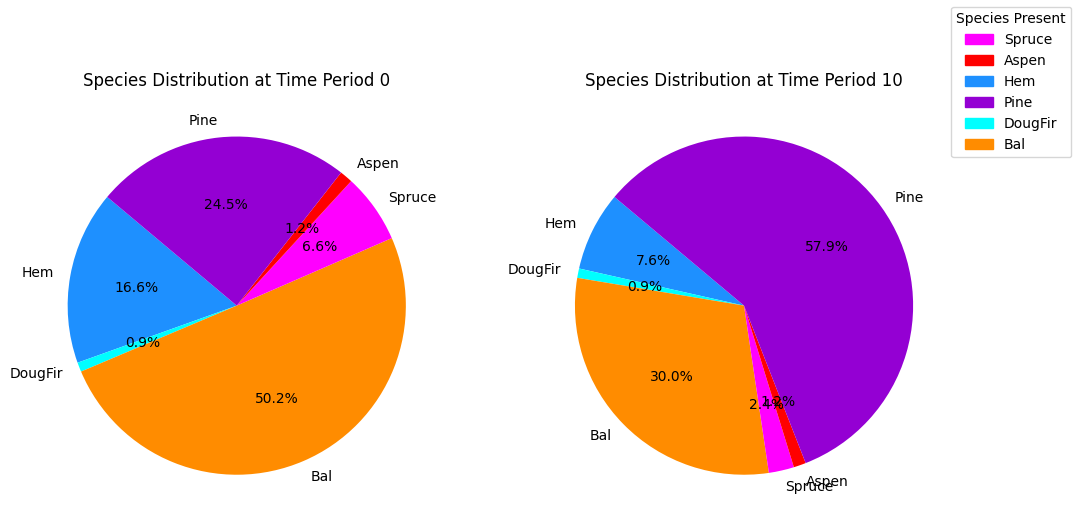

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.29s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

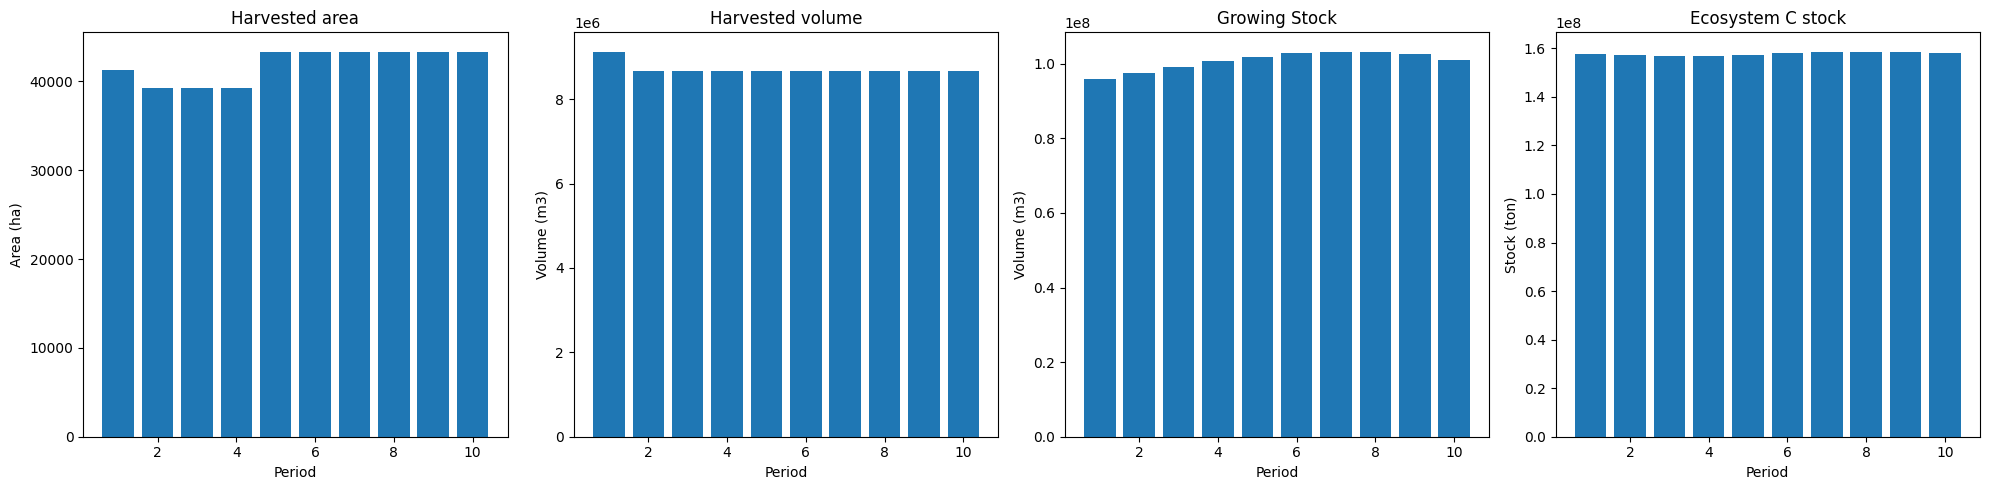

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


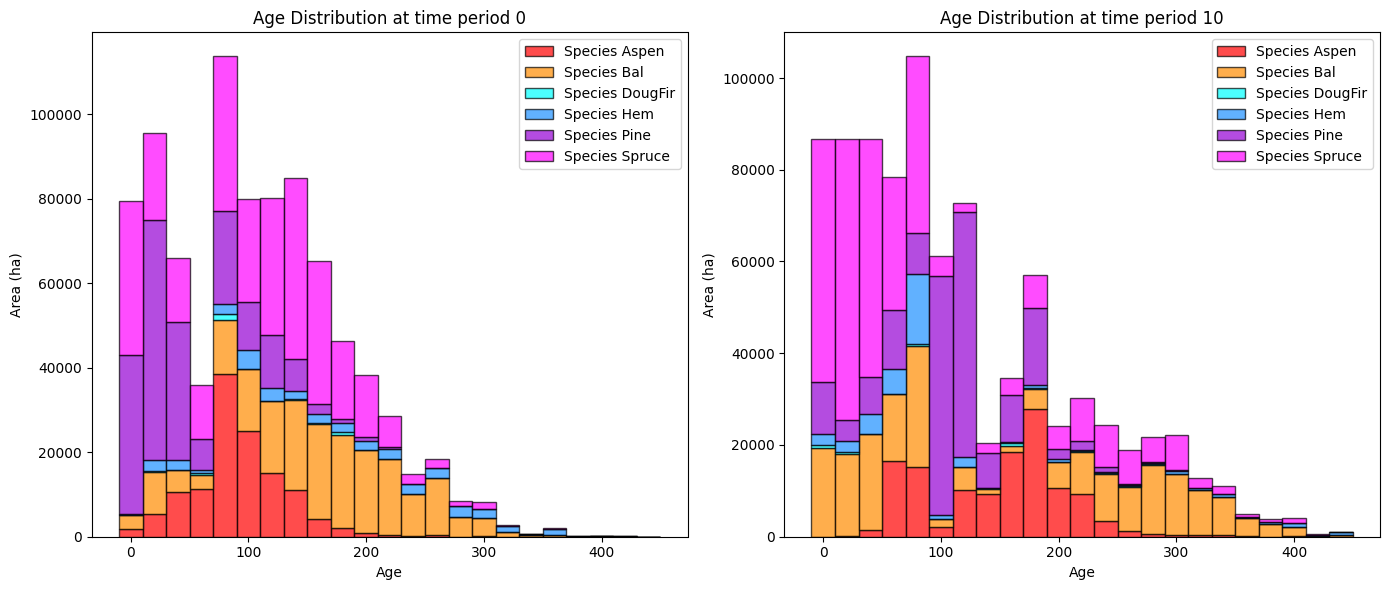

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


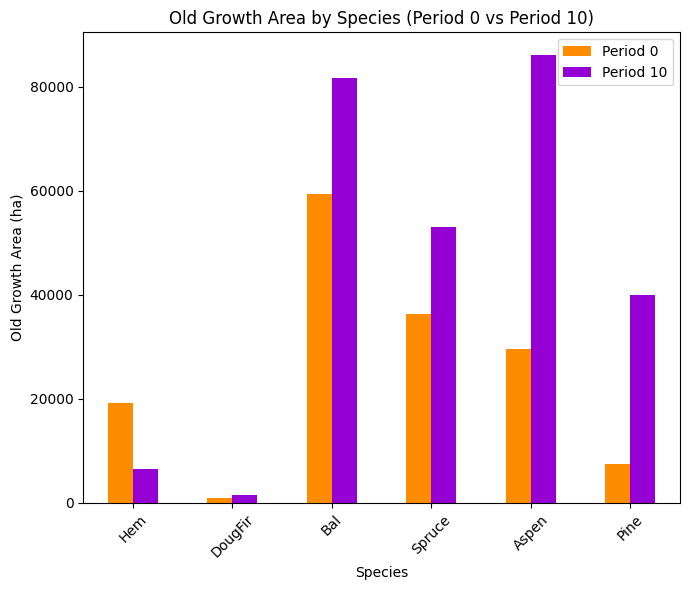

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


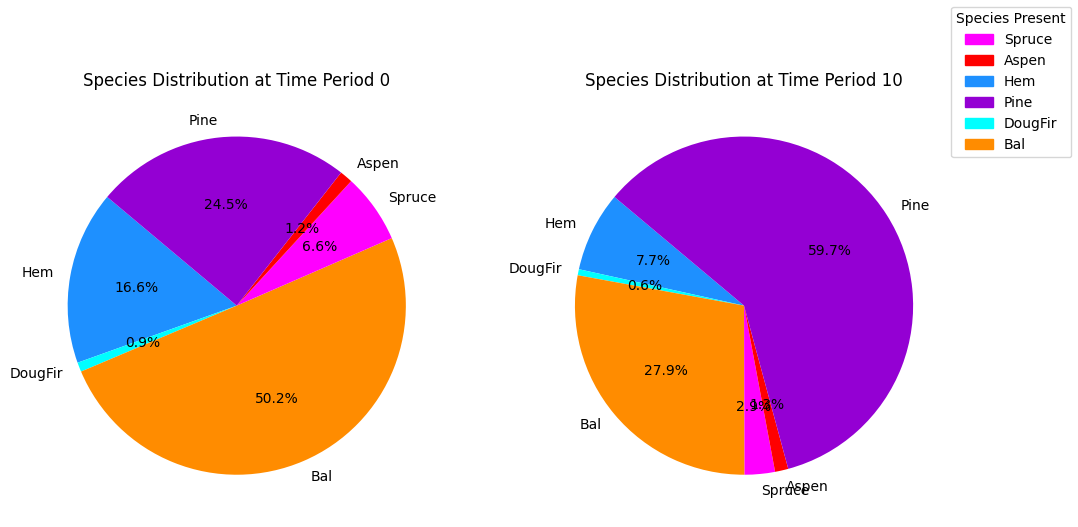

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


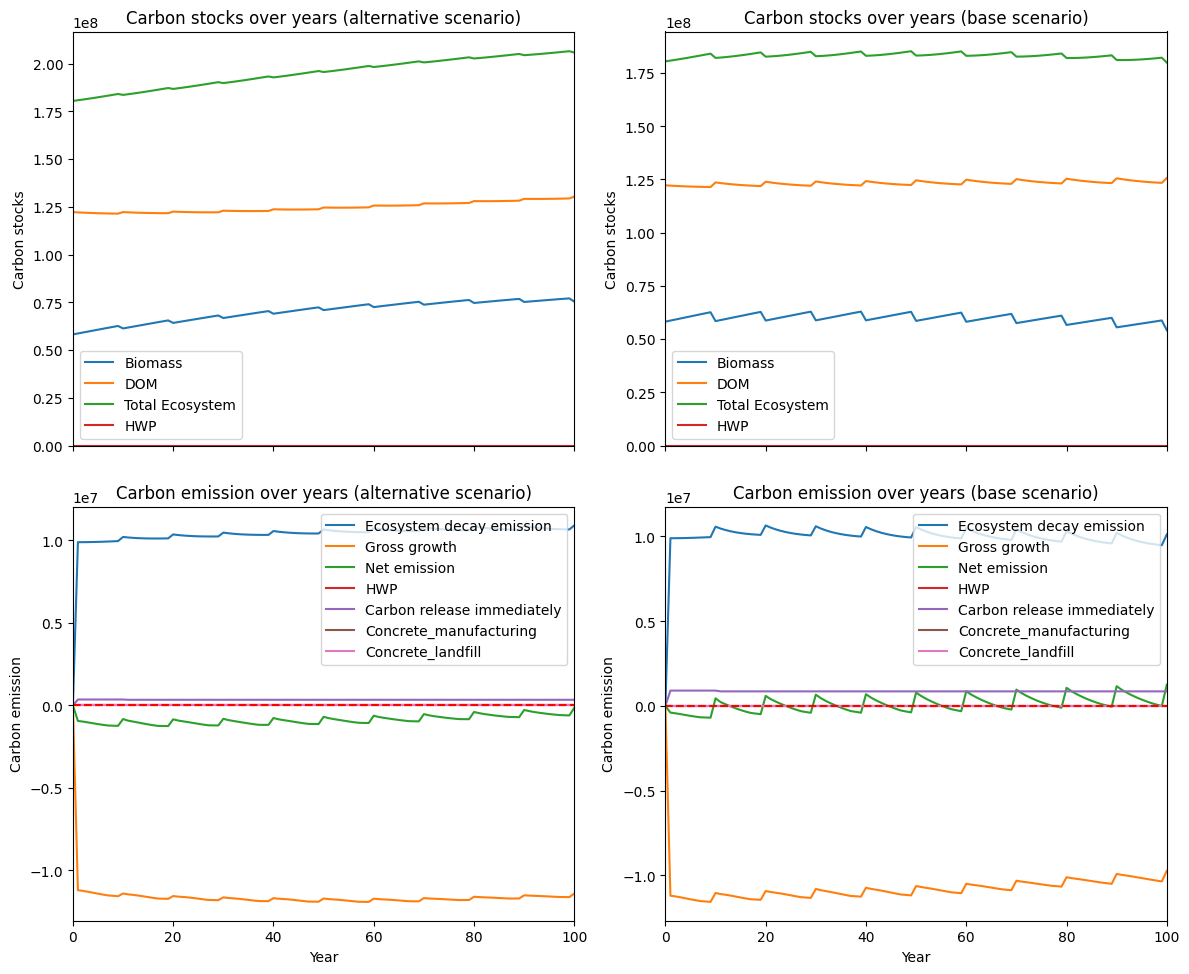

---------------------------------------------------------------------------------------
Net emission difference -20670683.35508254
Net emission base scenario -25706487.21070957
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.48377694284312006
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    4126.433649    4126.433649
DougFir  0.0    1131.714773    1131.714773
Bal      0.0   17731.404218   17731.404218
Spruce   0.0  101879.486092  101879.486092
Aspen    0.0   31722.266513   31722.266513
Pine     0.0   25859.325829   25859.325829

Overall, the old growth area has **increased** by 182450.63 hectares in the alternative scenario compared to the base scenario.


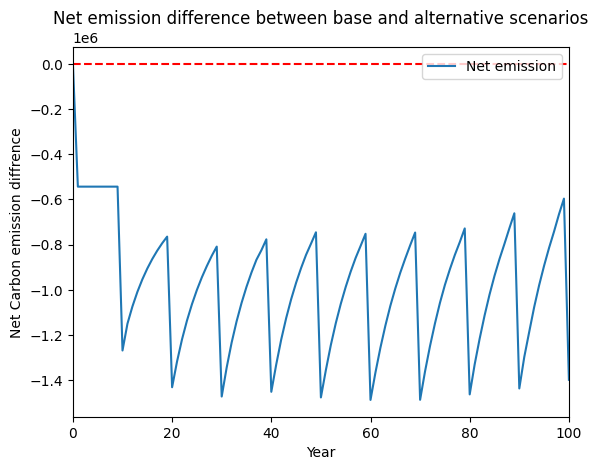

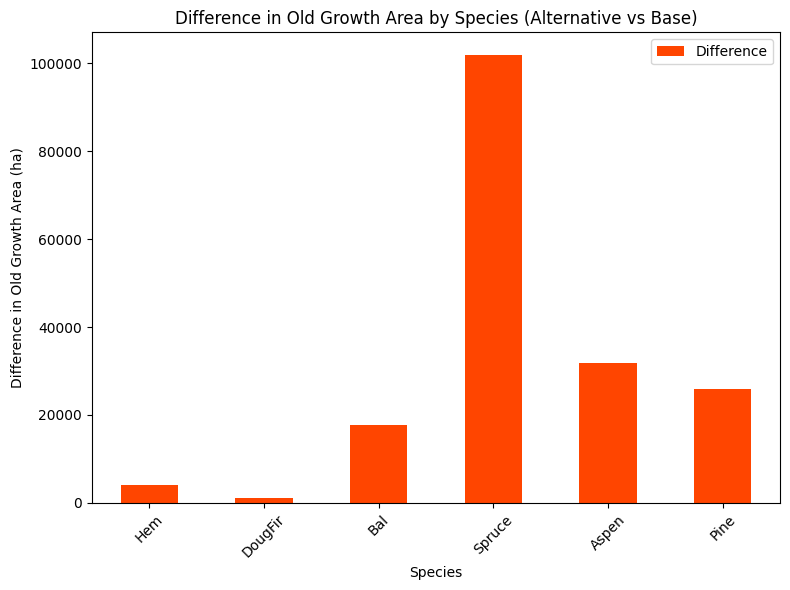

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


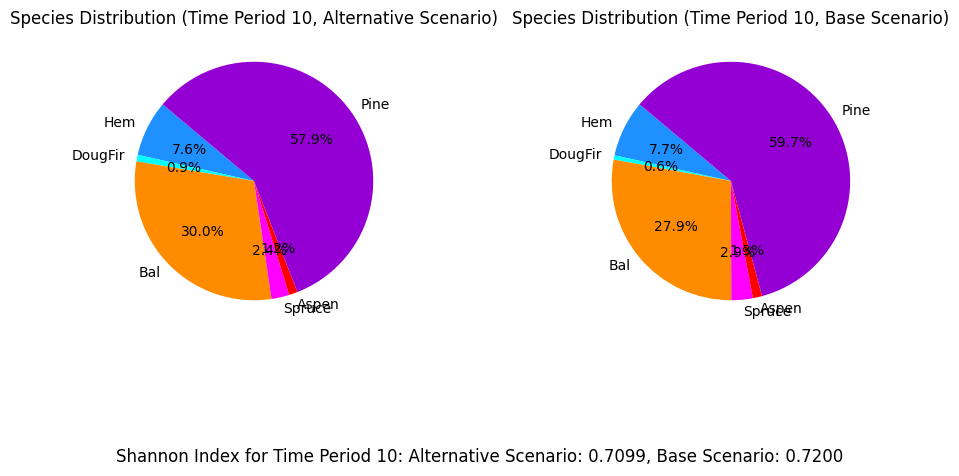

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_30%...
running the scenario for the Equity Silver mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf187f6a8
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 r

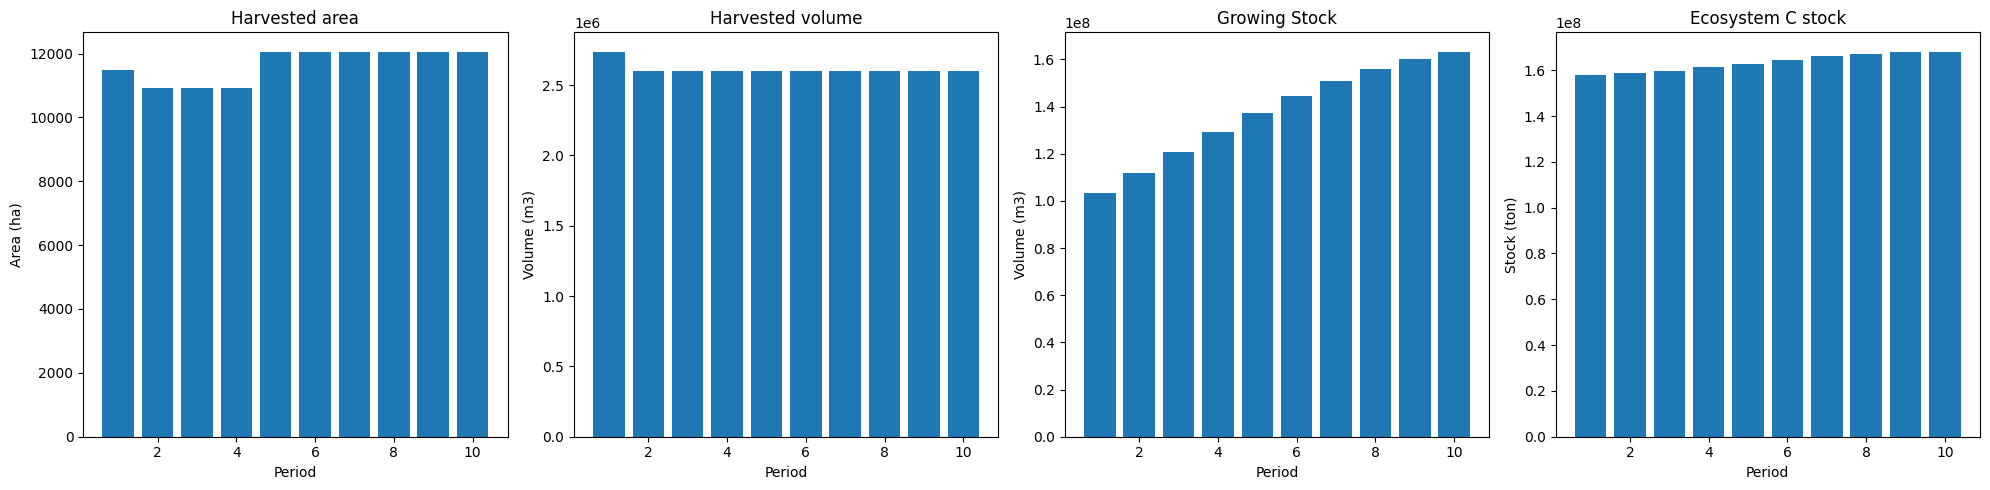

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  27647
The economic indicator (the provincial government revenues) is:  942827
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


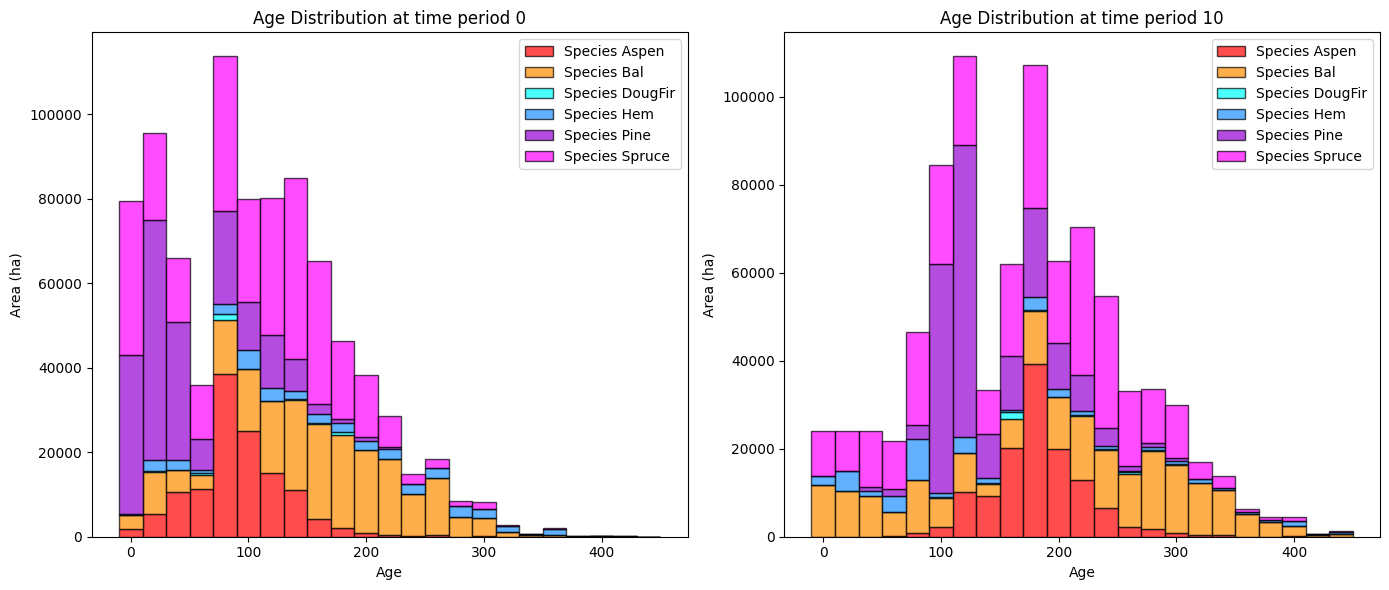

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   13441.607772   -5710.519456
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  113452.378935   54136.408466
Spruce   36410.744598  163619.879392  127209.134794
Aspen    29632.731169  118052.632115   88419.900946
Pine      7432.733686   67763.229102   60330.495416

Overall diversity has **increased** by 326187.67 hectares from time period 0 to time period 10.


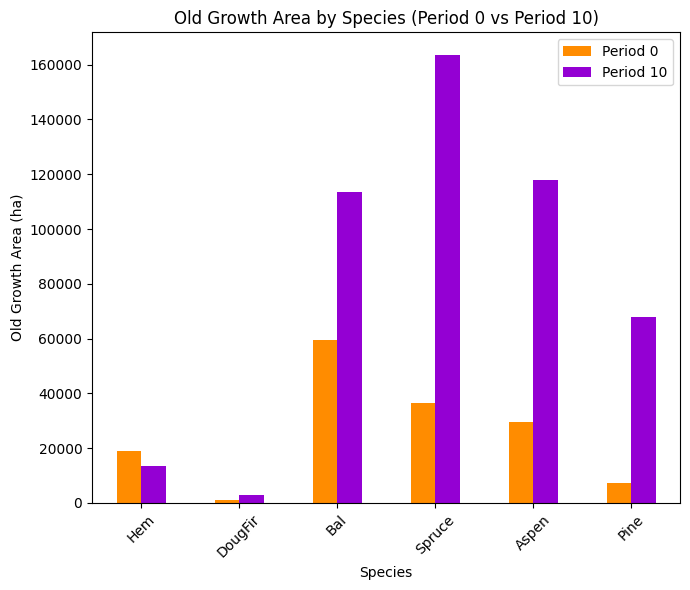

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7118

Diversity has **decreased** by 4.73% from time 0 to time 10.


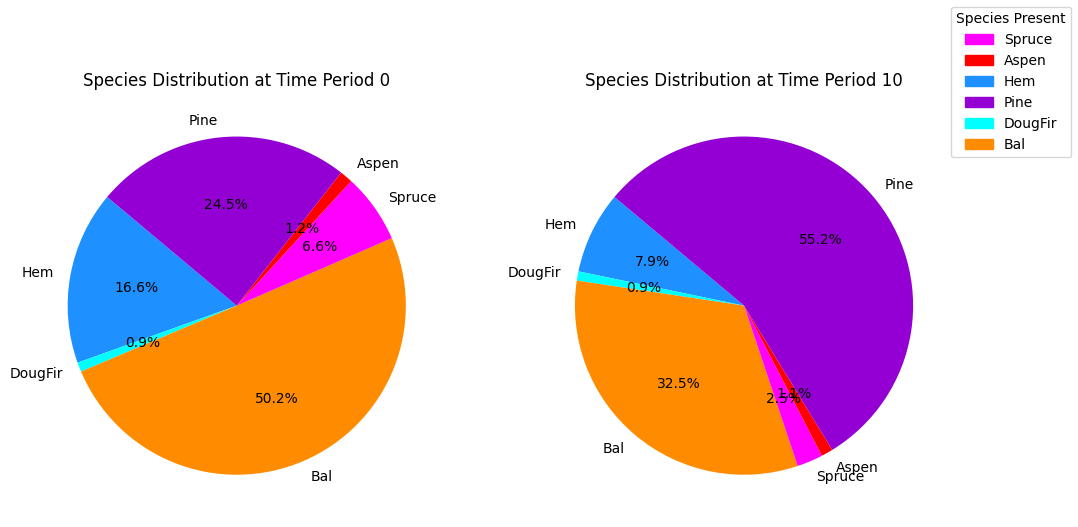

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

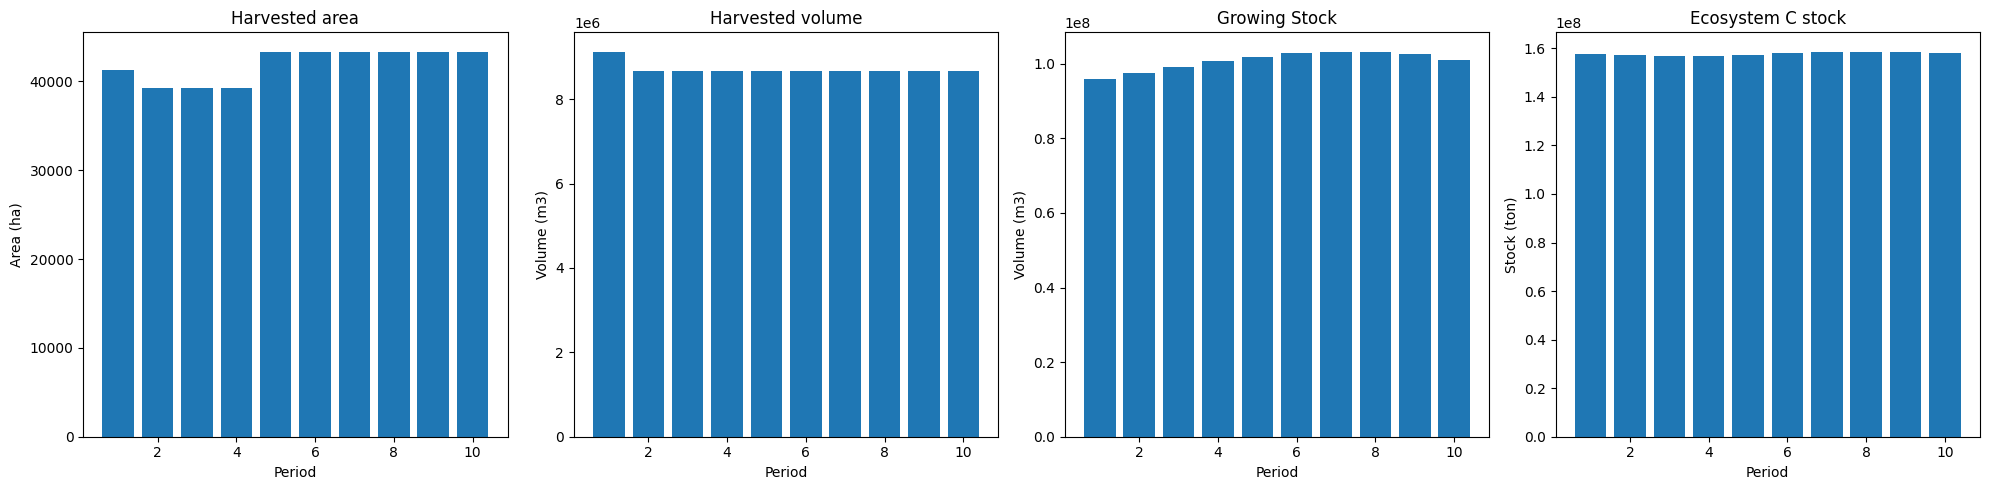

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


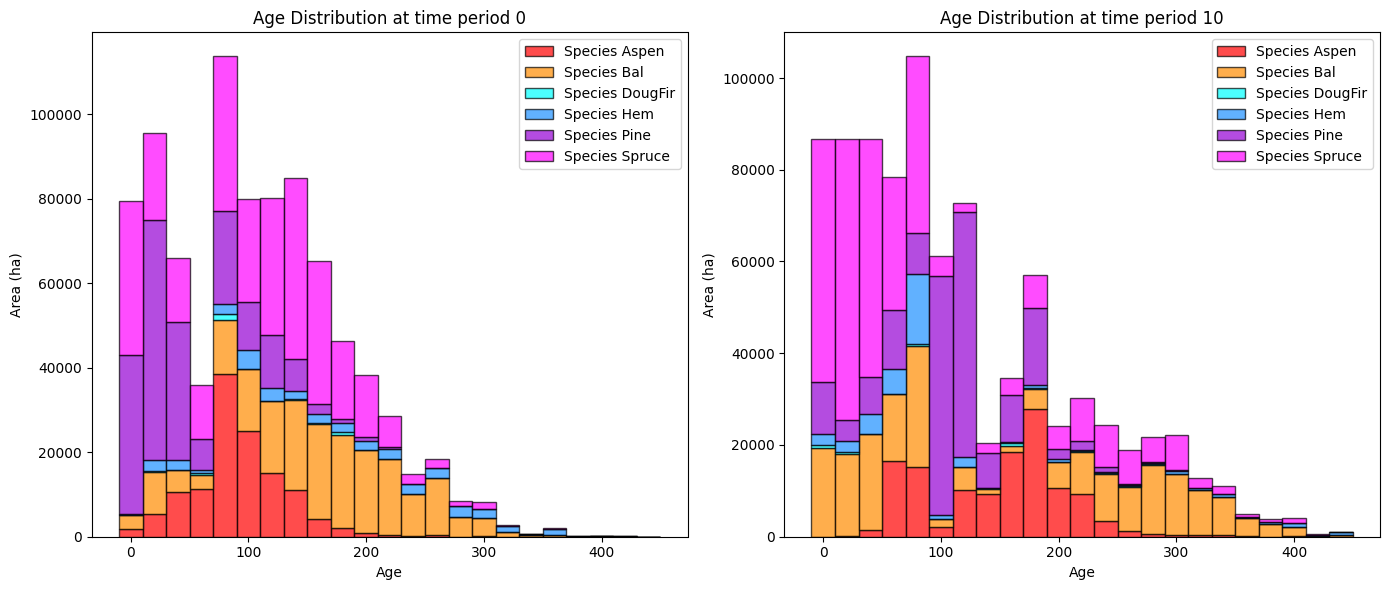

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


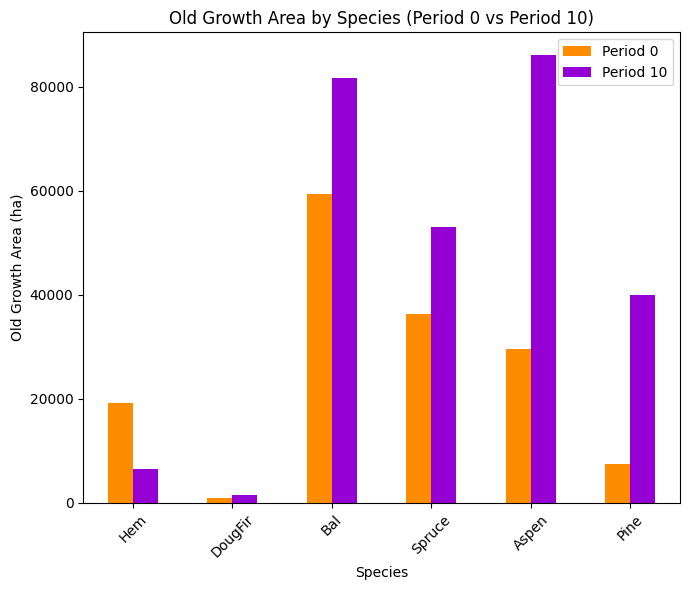

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


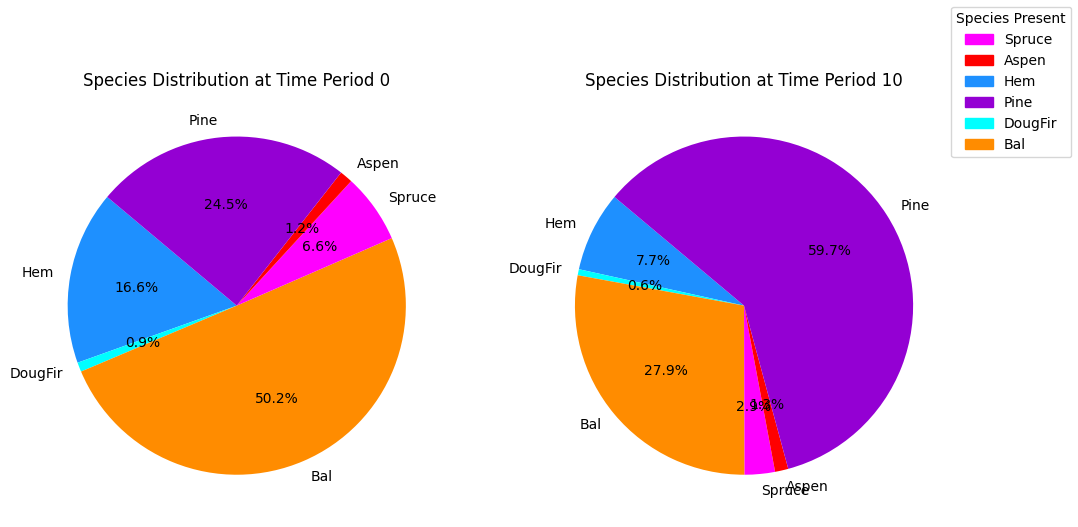

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


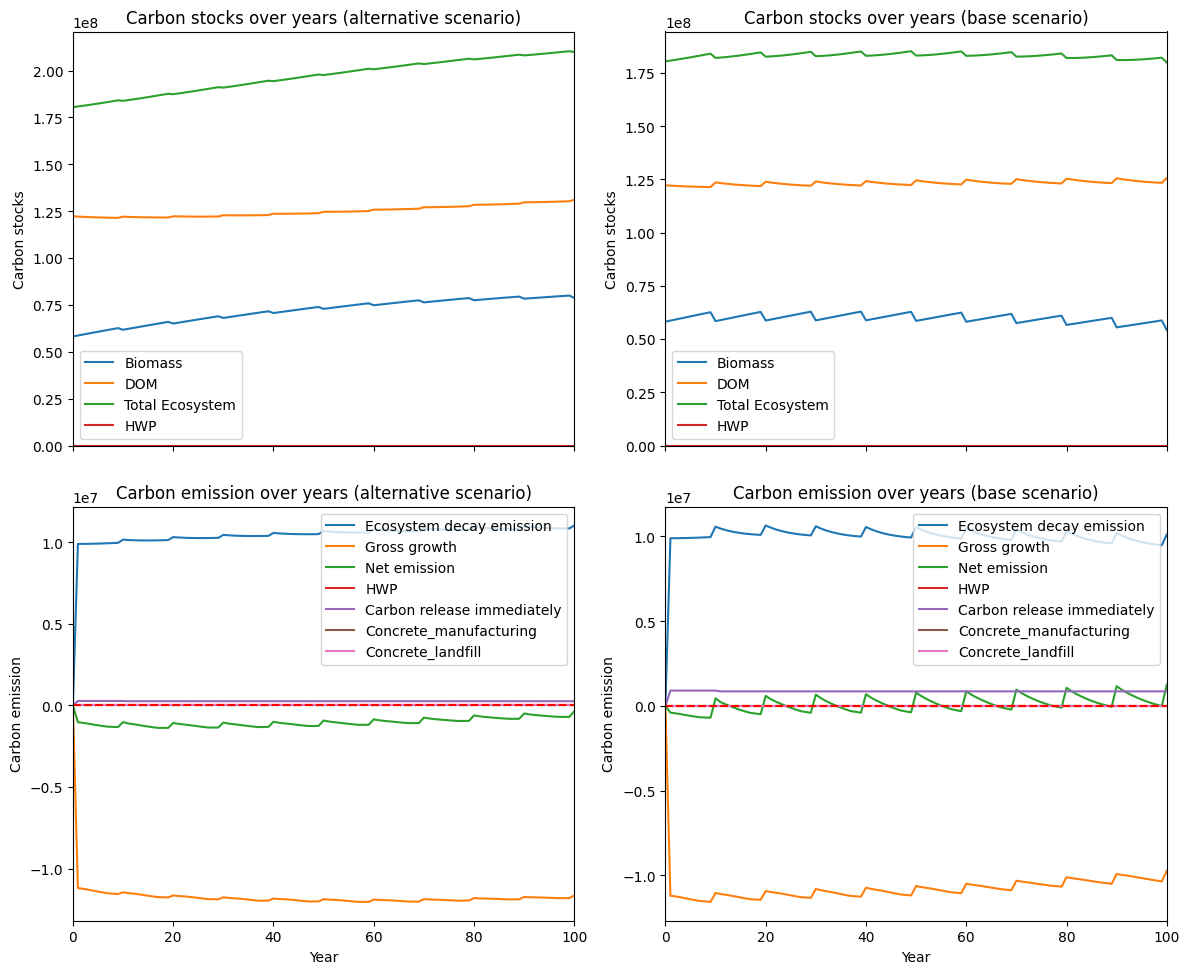

---------------------------------------------------------------------------------------
Net emission difference -24068794.758196414
Net emission base scenario -29104598.613823447
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.41547572699271074
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    6832.430889    6832.430889
DougFir  0.0    1273.171398    1273.171398
Bal      0.0   31696.468982   31696.468982
Spruce   0.0  110593.776294  110593.776294
Aspen    0.0   31922.045162   31922.045162
Pine     0.0   27761.099145   27761.099145

Overall, the old growth area has **increased** by 210078.99 hectares in the alternative scenario compared to the base scenario.


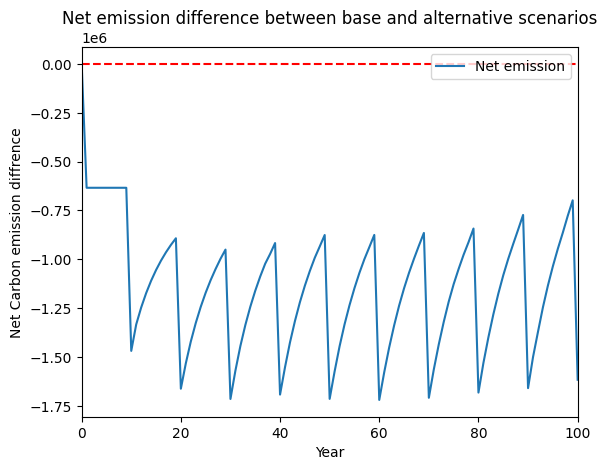

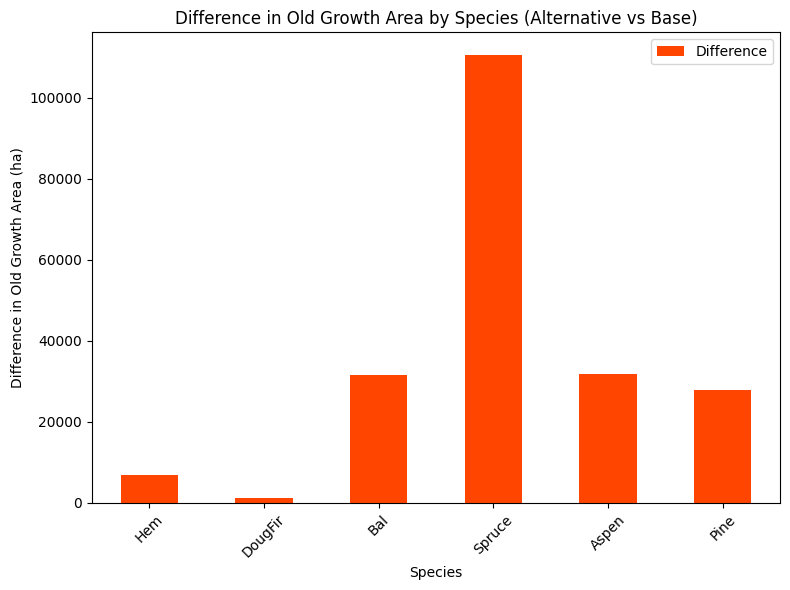

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


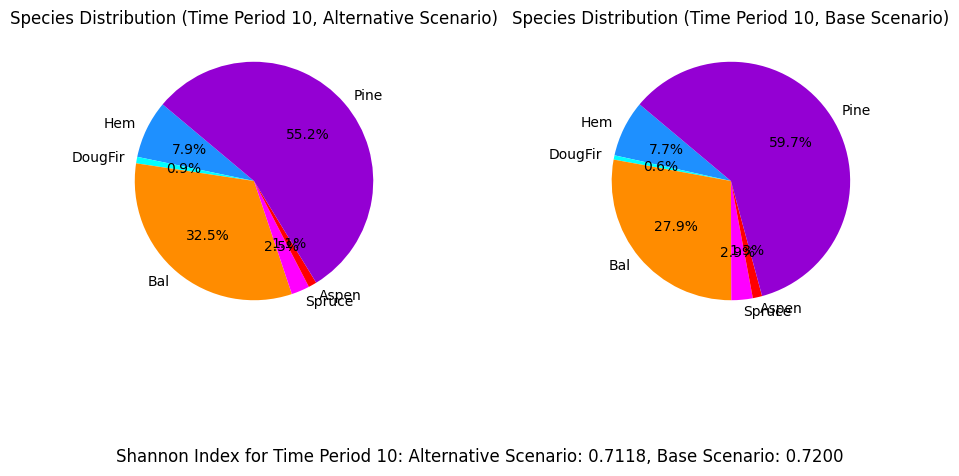

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_20%...
running the scenario for the Equity Silver mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x1f4a71dc
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 r

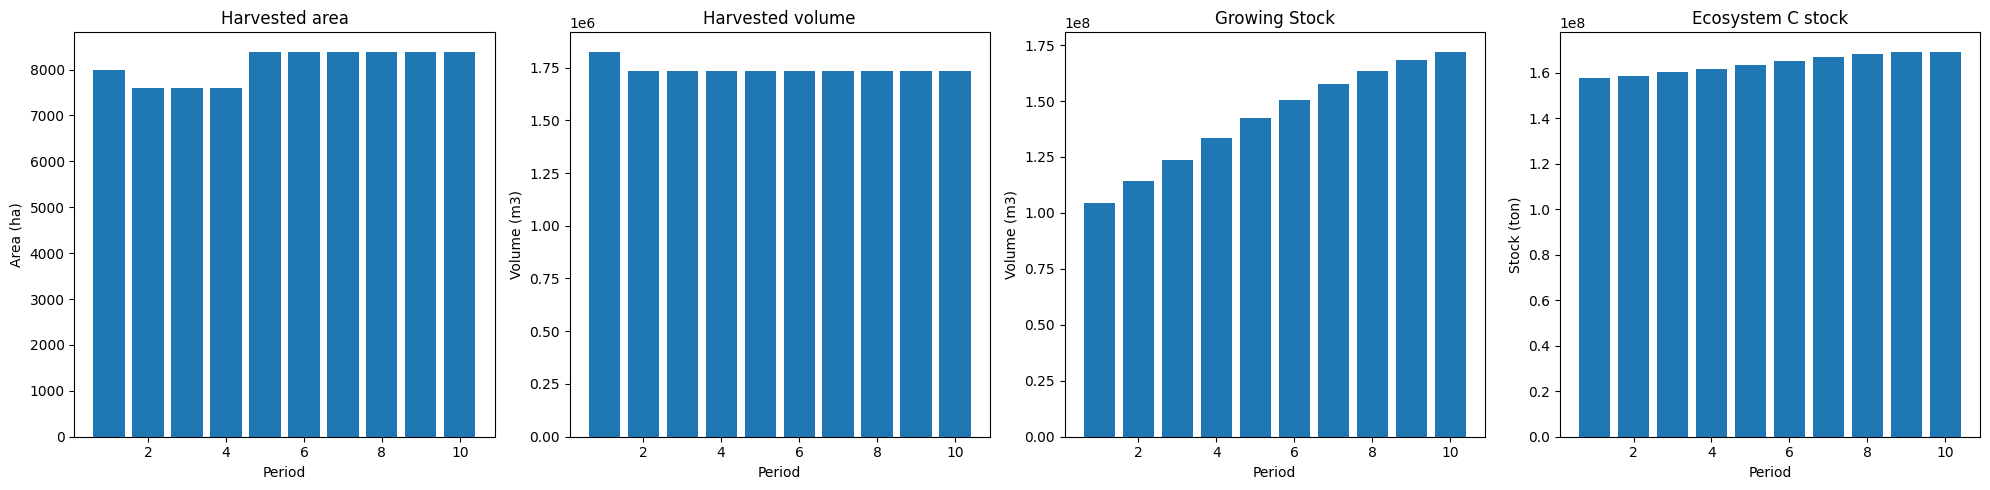

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  18431
The economic indicator (the provincial government revenues) is:  628551
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


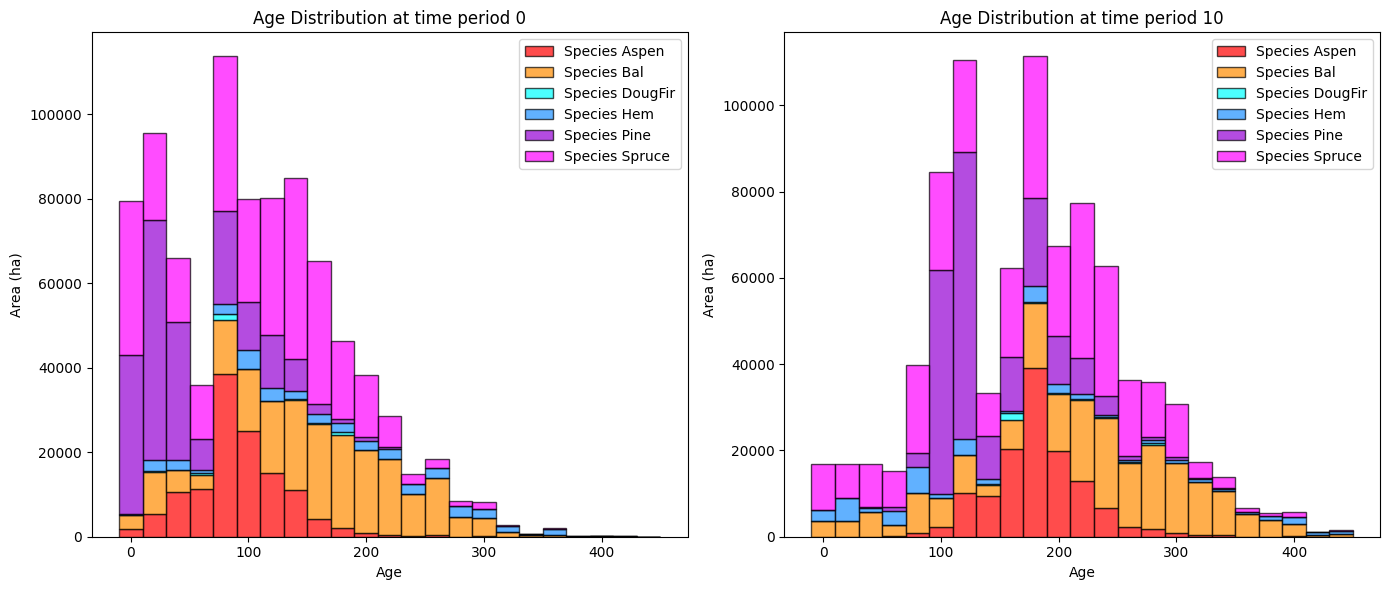

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   15618.869926   -3533.257303
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  135971.811627   76655.841159
Spruce   36410.744598  169743.213391  133332.468793
Aspen    29632.731169  118142.060176   88509.329007
Pine      7432.733686   69038.216638   61605.482952

Overall diversity has **increased** by 358372.12 hectares from time period 0 to time period 10.


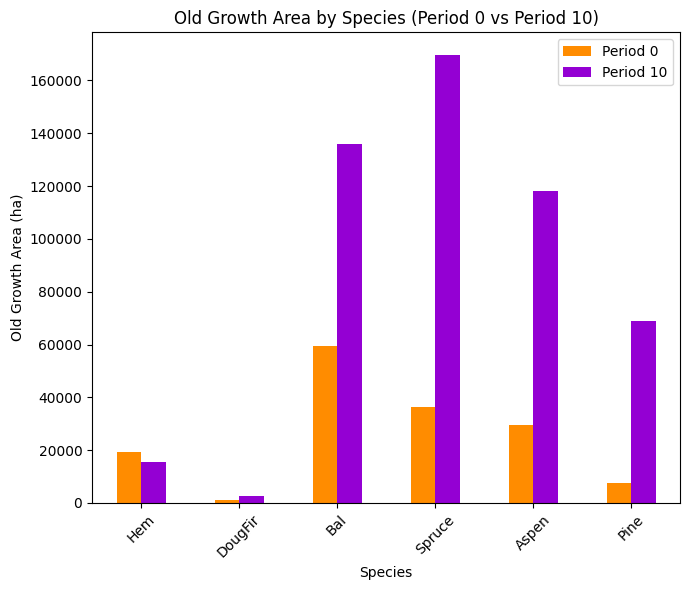

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7138

Diversity has **decreased** by 4.53% from time 0 to time 10.


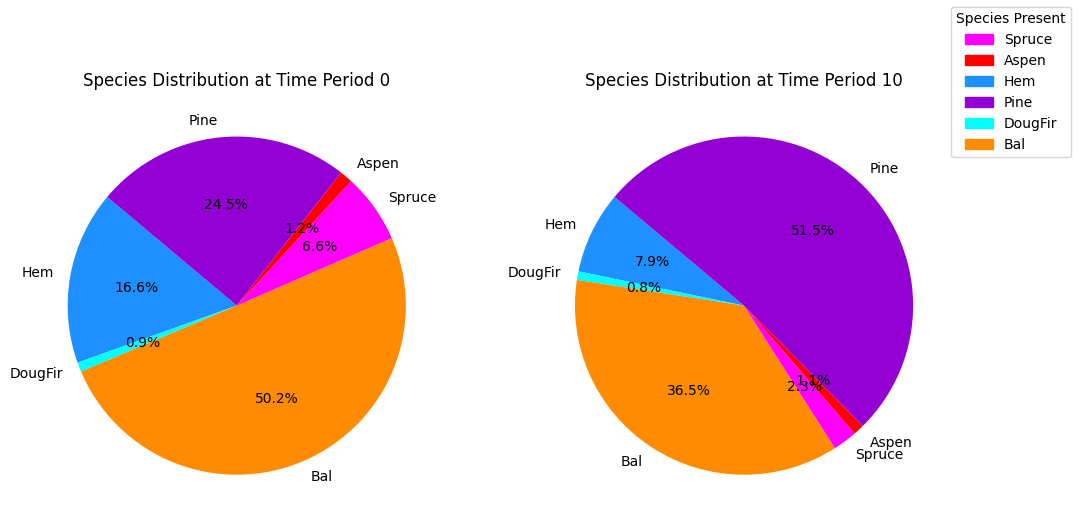

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.30s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

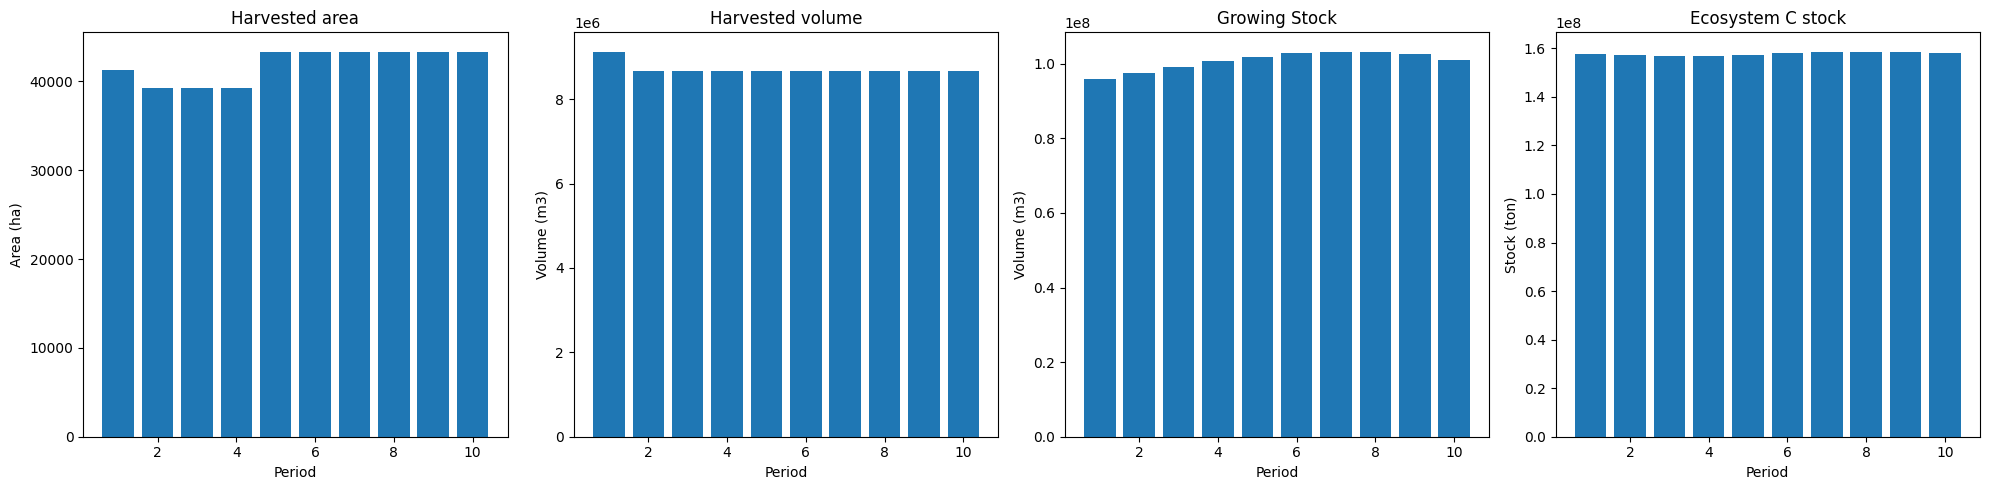

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


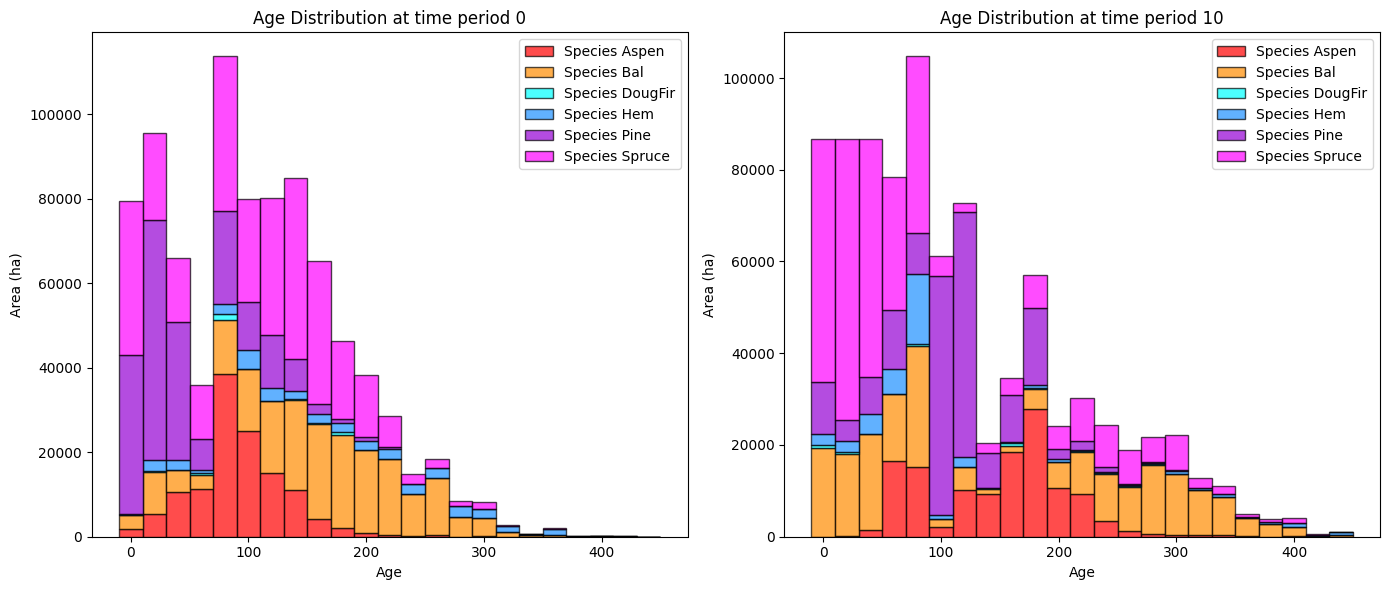

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


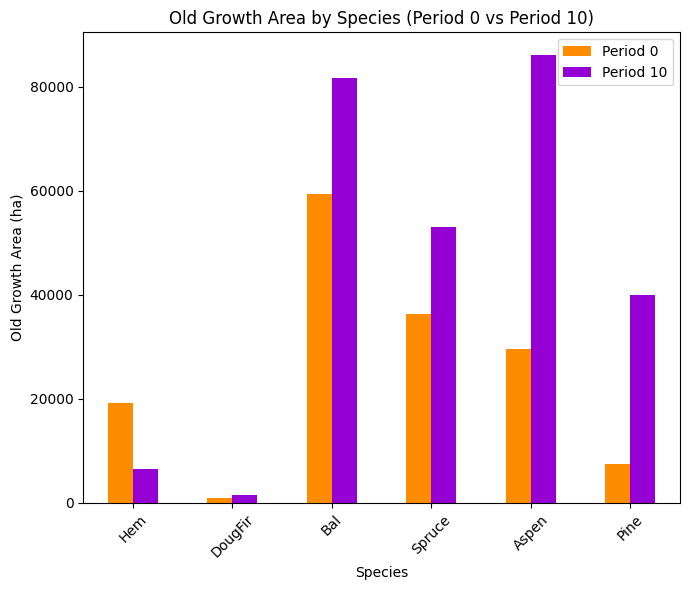

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


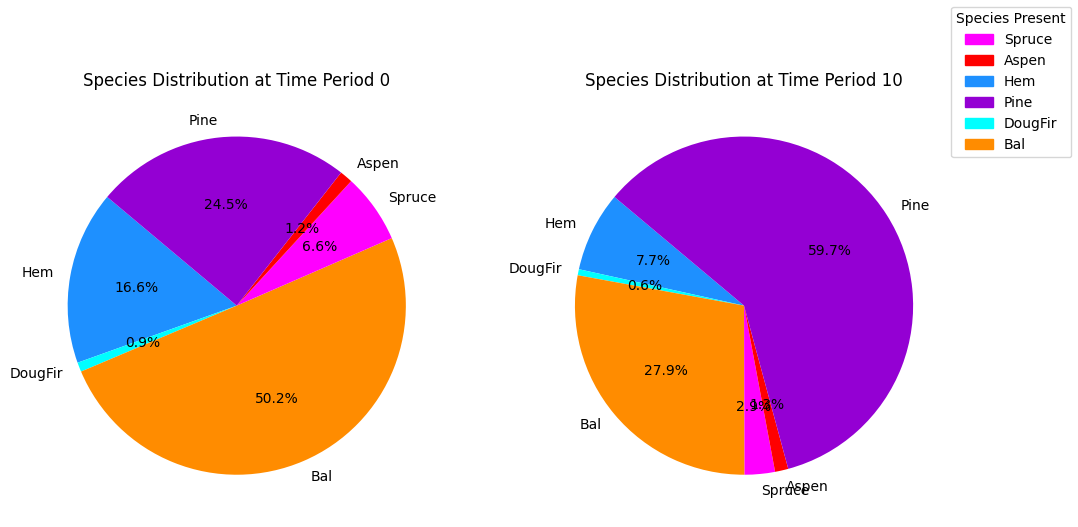

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


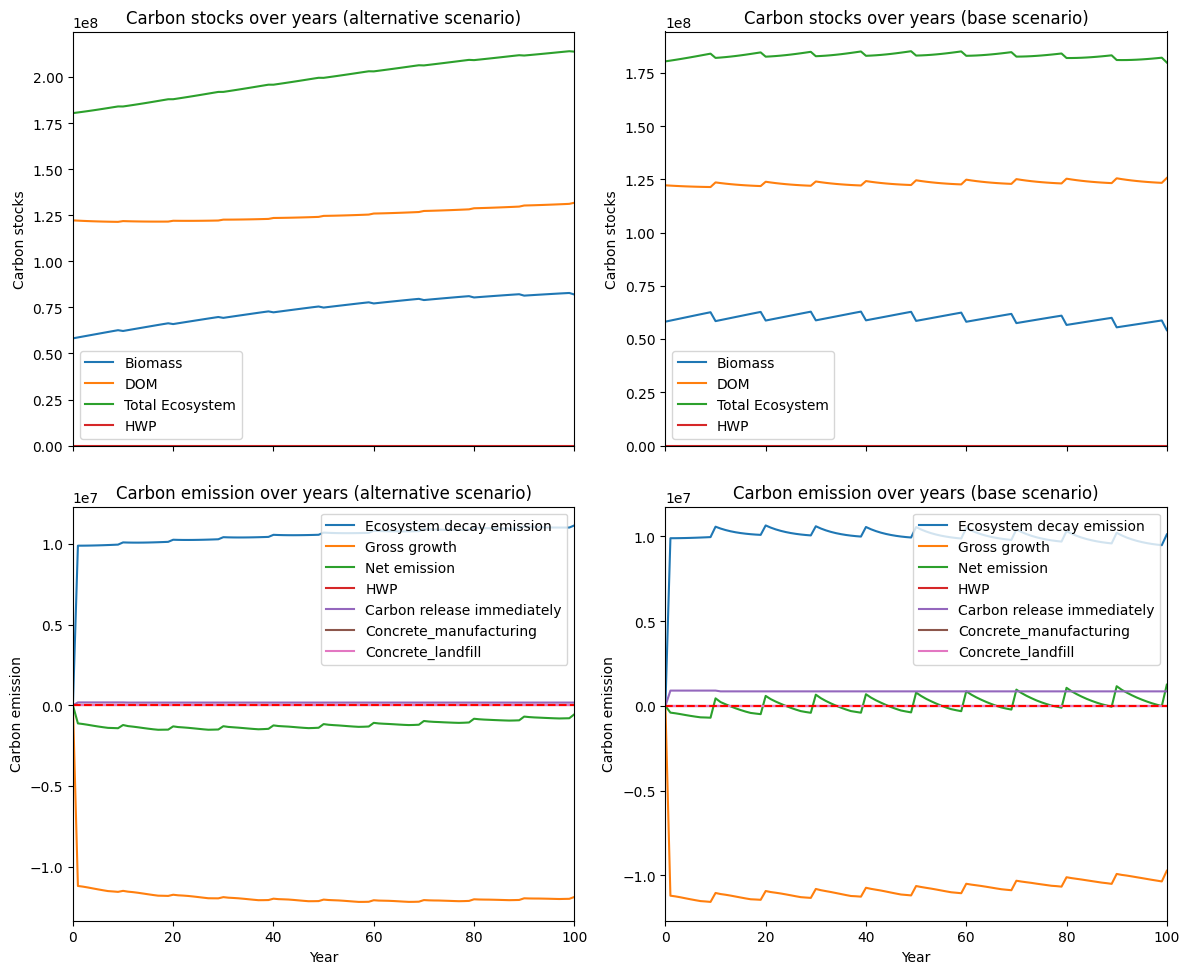

---------------------------------------------------------------------------------------
Net emission difference -27478597.04406119
Net emission base scenario -32514400.89968822
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.3639195983683326
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    9009.693043    9009.693043
DougFir  0.0    1273.171398    1273.171398
Bal      0.0   54215.901675   54215.901675
Spruce   0.0  116717.110293  116717.110293
Aspen    0.0   32011.473223   32011.473223
Pine     0.0   29036.086681   29036.086681

Overall, the old growth area has **increased** by 242263.44 hectares in the alternative scenario compared to the base scenario.


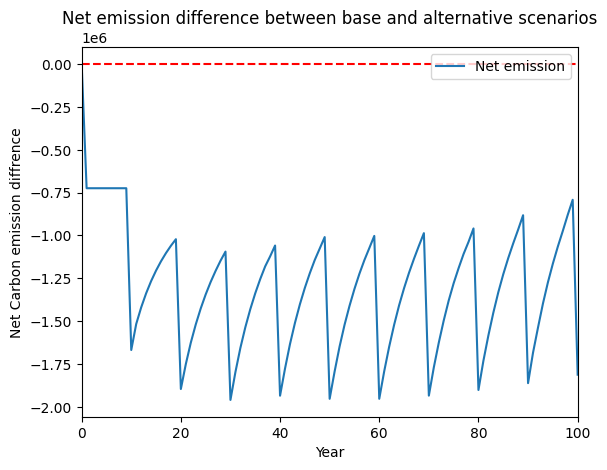

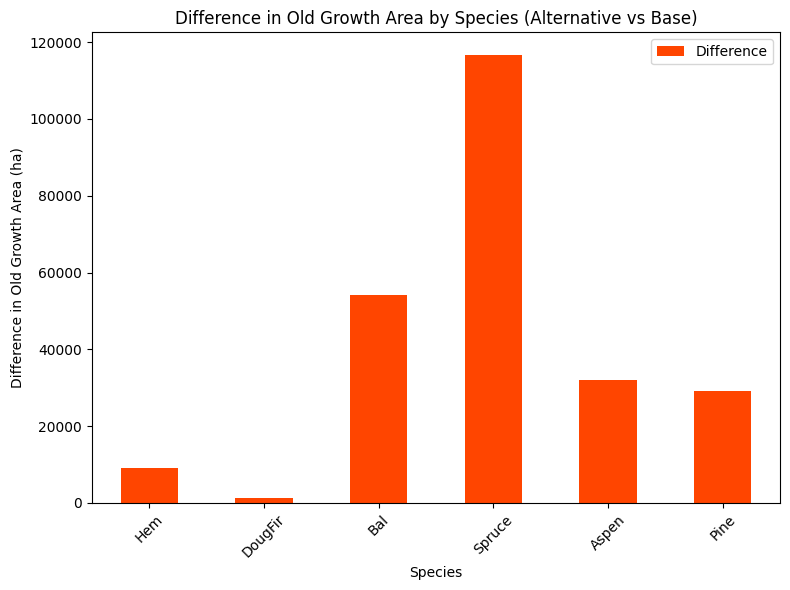

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


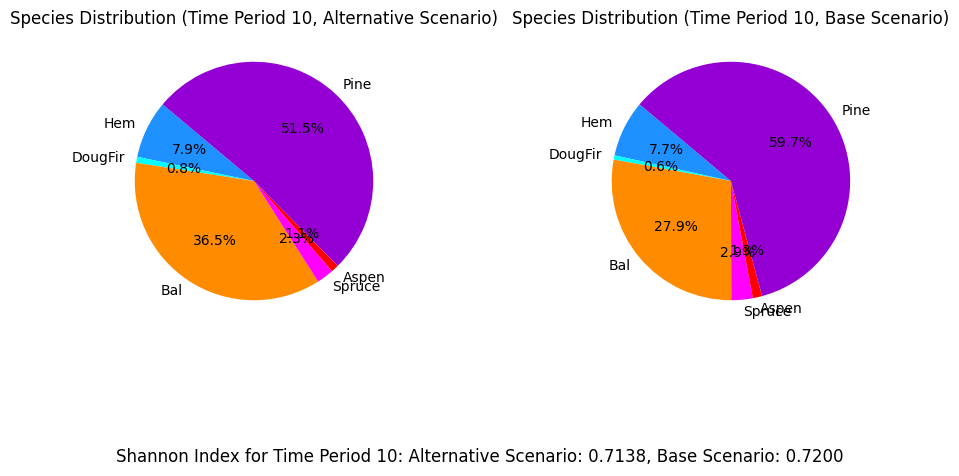

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_10%...
running the scenario for the Equity Silver mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xe75935c6
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.27s
Presolved: 8375 r

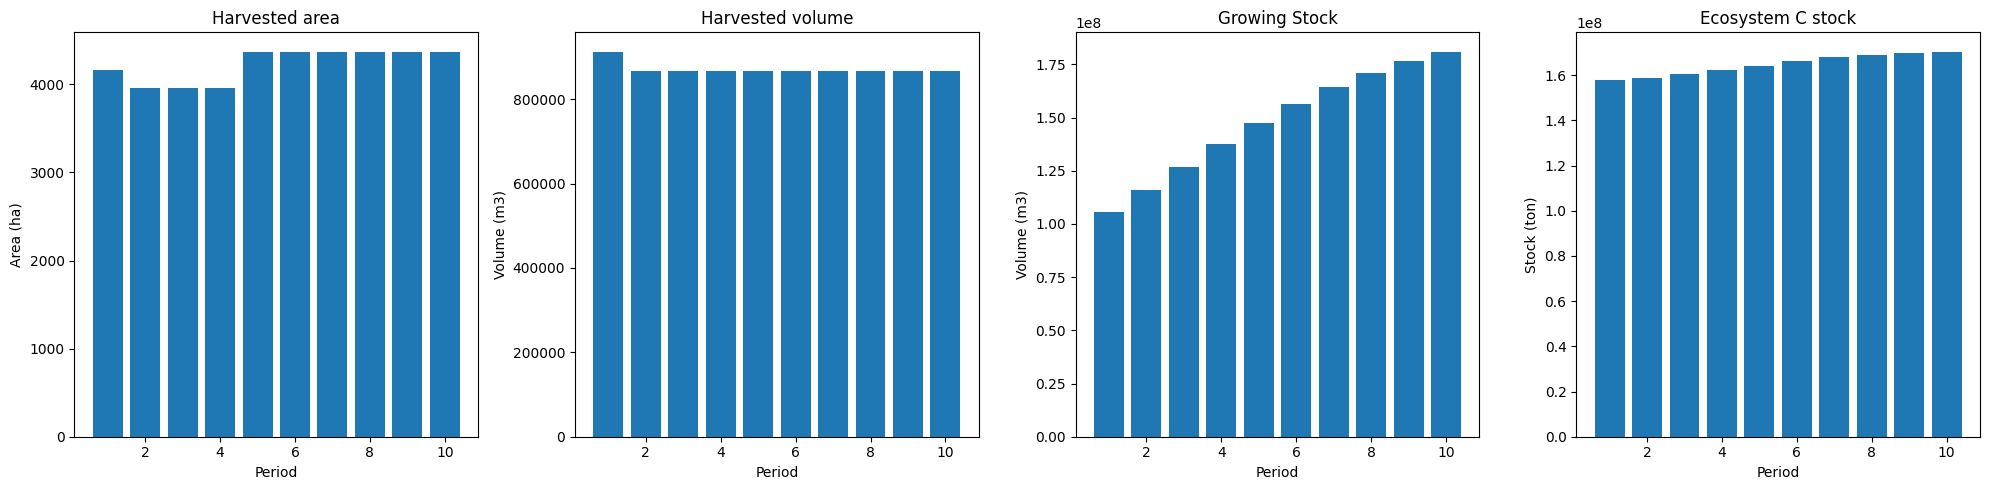

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  9215
The economic indicator (the provincial government revenues) is:  314275
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


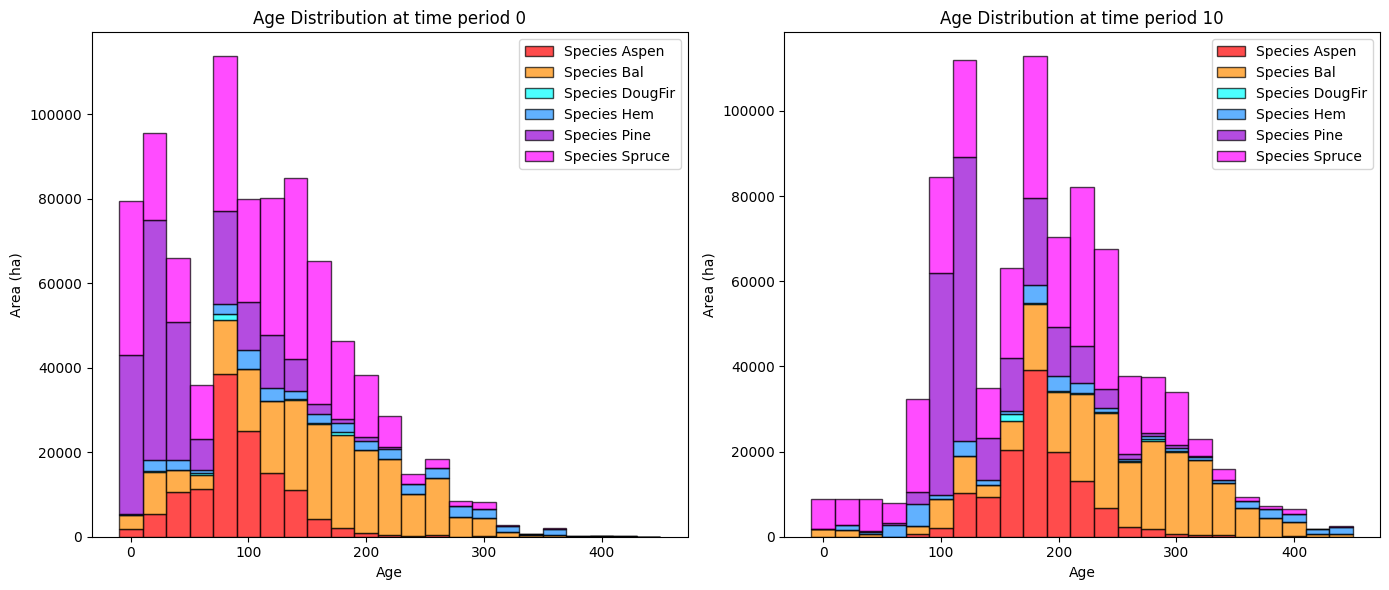

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   23175.854385    4023.727156
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  153334.501869   94018.531401
Spruce   36410.744598  176388.753553  139978.008955
Aspen    29632.731169  118314.566885   88681.835716
Pine      7432.733686   69974.668514   62541.934828

Overall diversity has **increased** by 391046.29 hectares from time period 0 to time period 10.


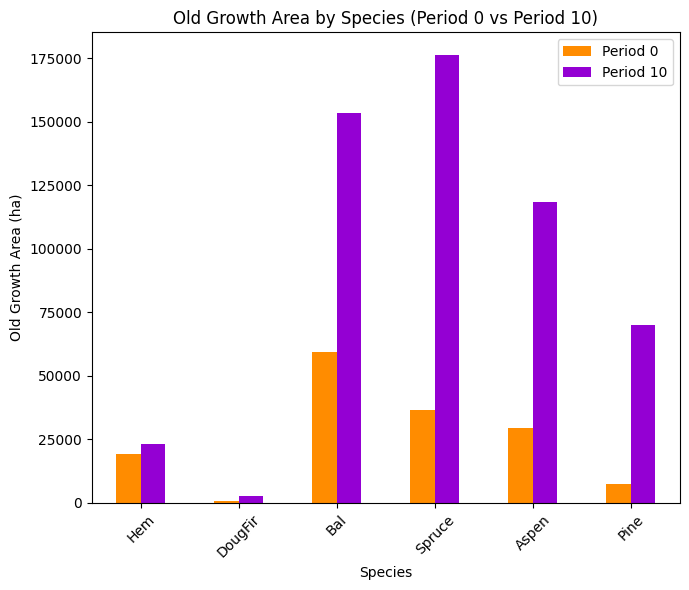

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7235

Diversity has **decreased** by 3.56% from time 0 to time 10.


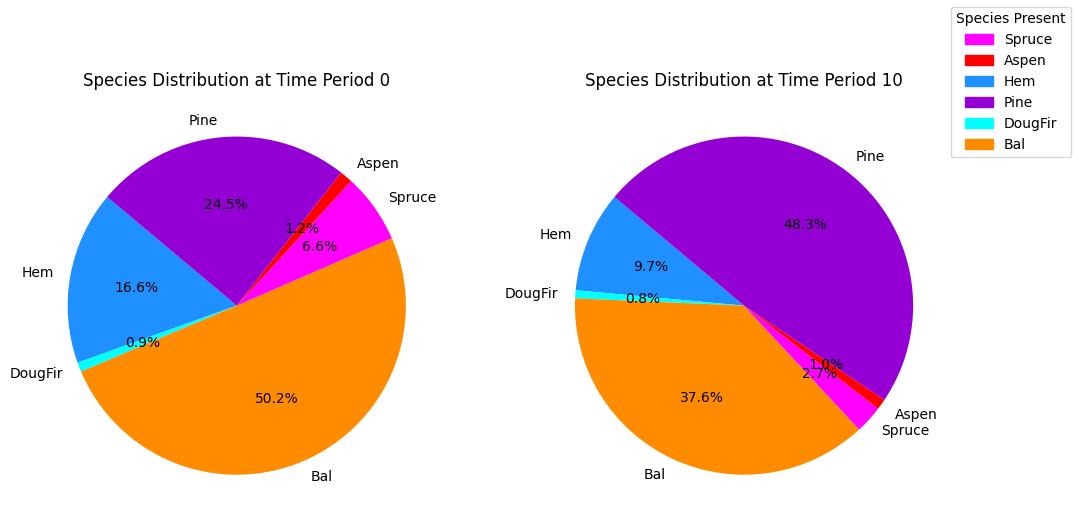

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x51a63148
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

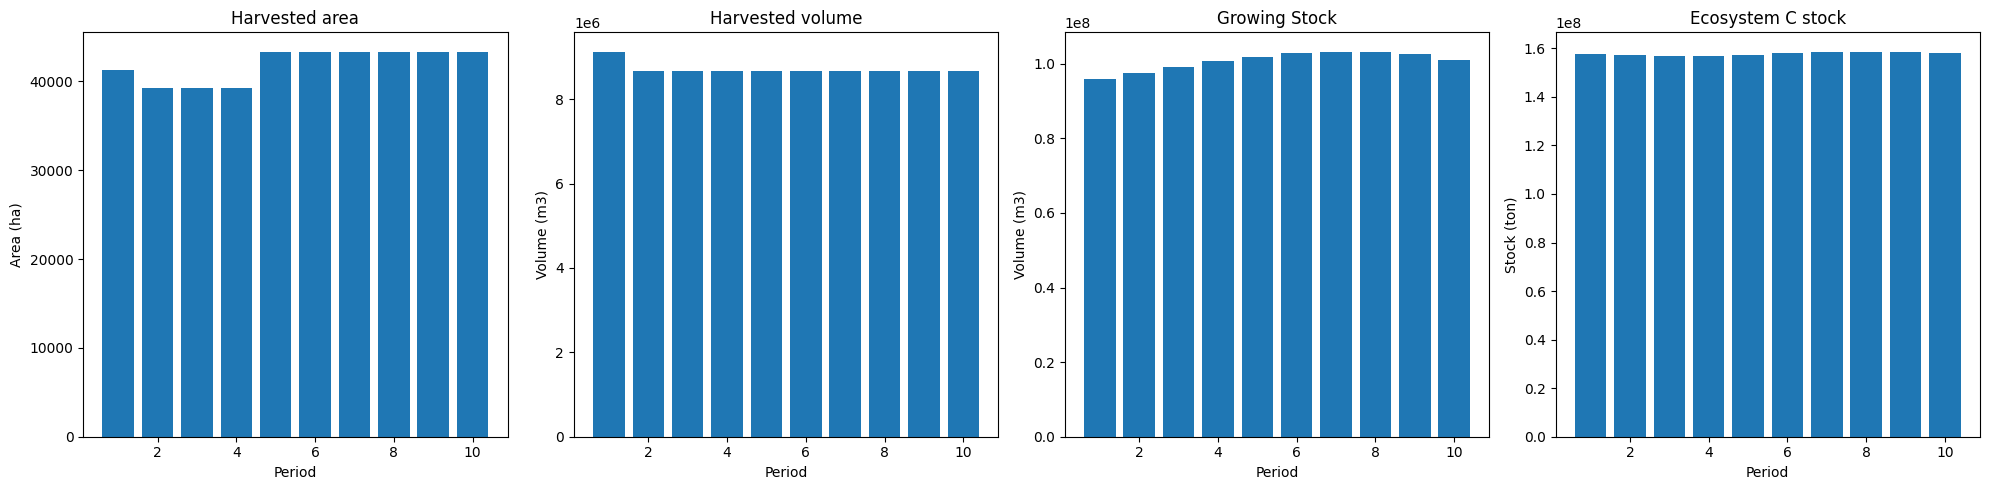

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


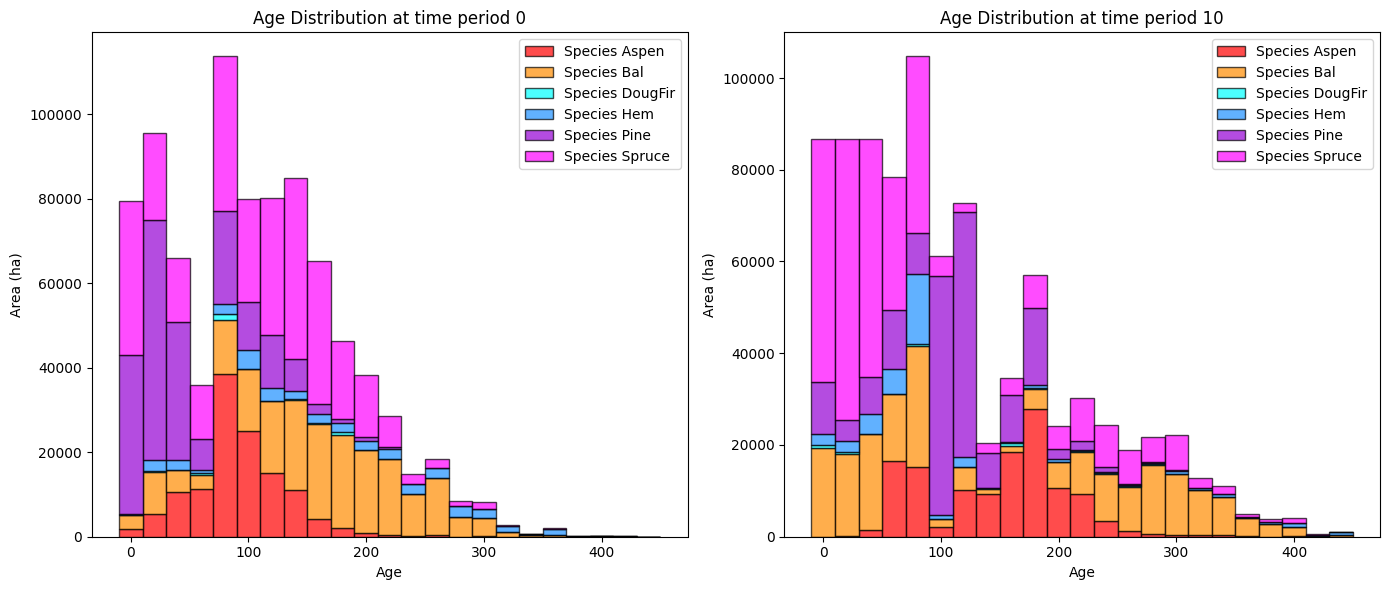

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6609.176883 -12542.950346
DougFir    947.047810   1476.126814    529.079003
Bal      59315.970469  81755.909953  22439.939484
Spruce   36410.744598  53026.103098  16615.358500
Aspen    29632.731169  86130.586953  56497.855784
Pine      7432.733686  40002.129957  32569.396271

Overall diversity has **increased** by 116108.68 hectares from time period 0 to time period 10.


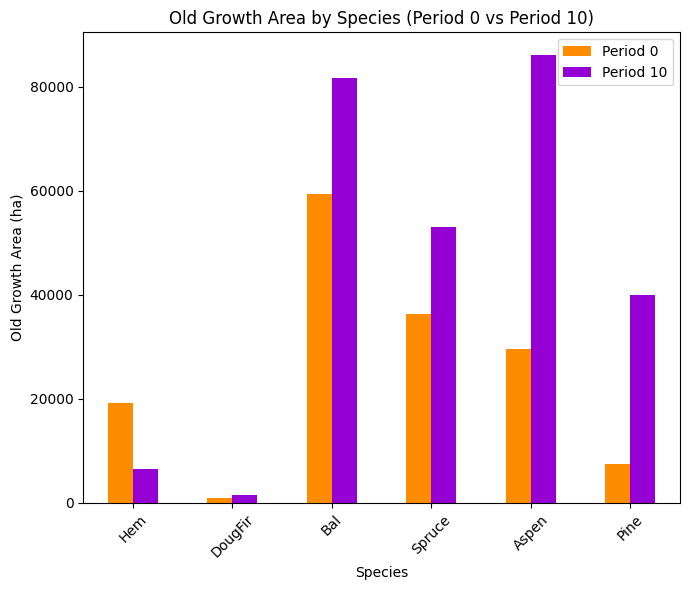

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7200

Diversity has **decreased** by 3.92% from time 0 to time 10.


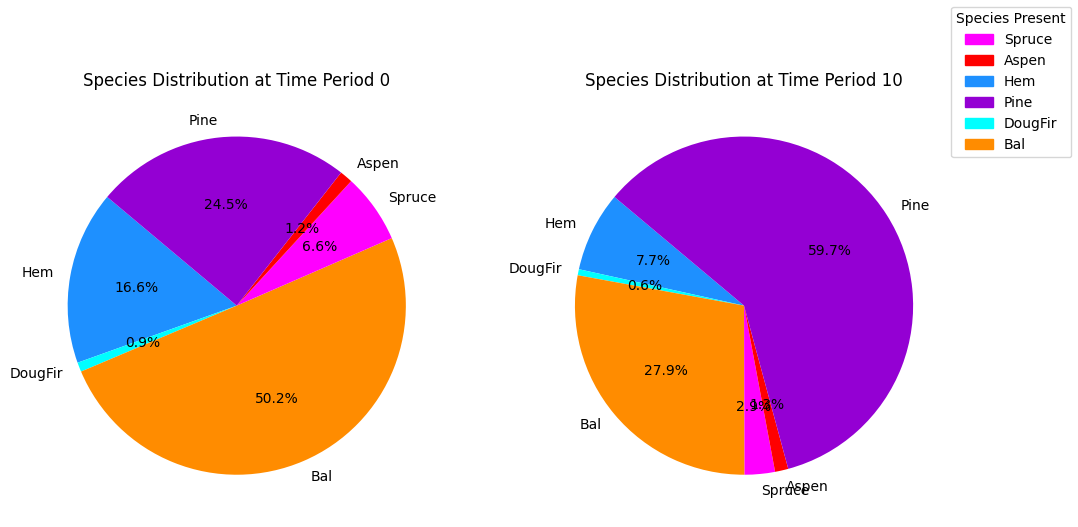

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


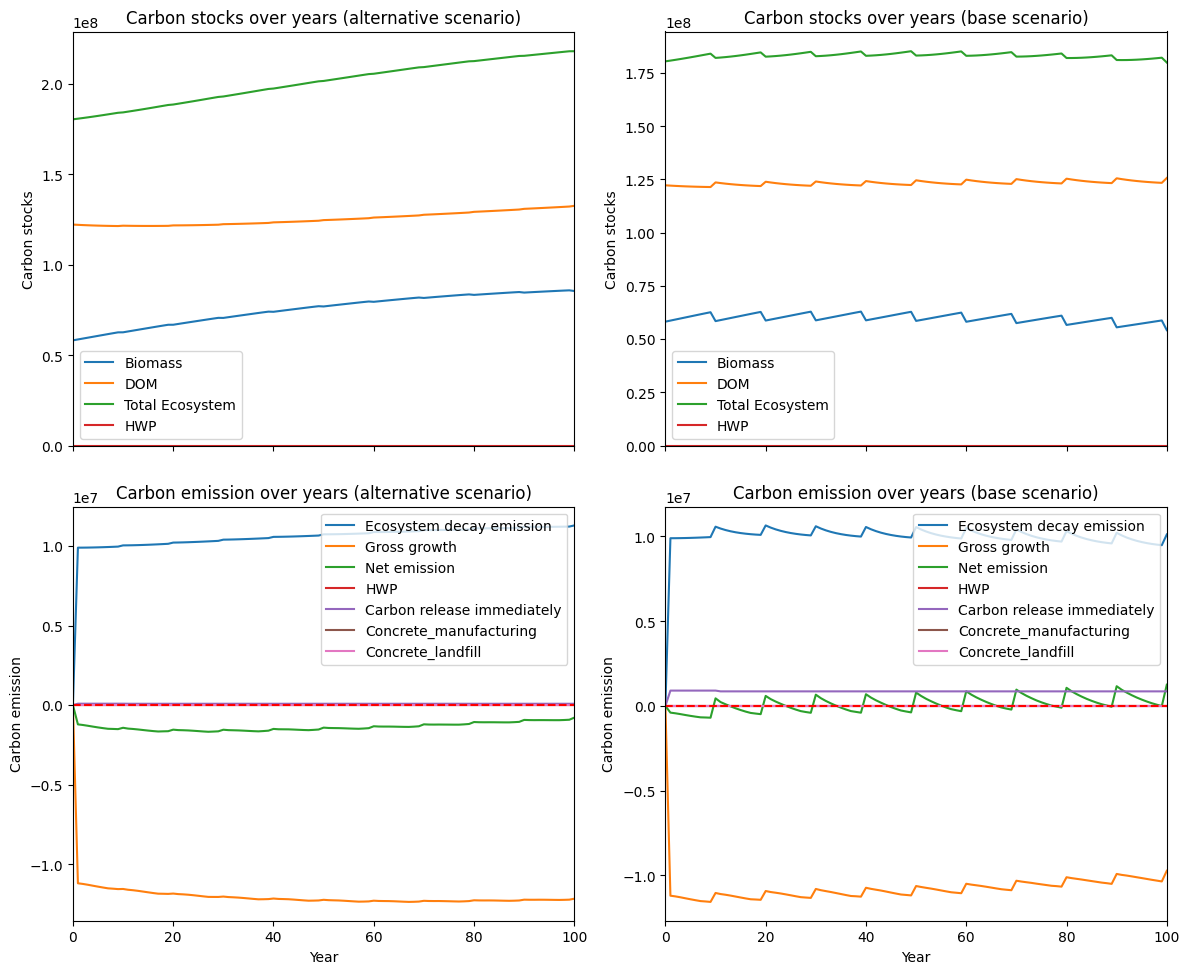

---------------------------------------------------------------------------------------
Net emission difference -30959880.455069117
Net emission base scenario -35995684.31069615
Net emission alternative scenario -5035803.855627034
dollar_per_ton is:  0.322998663205842
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0   16566.677502   16566.677502
DougFir  0.0    1273.171398    1273.171398
Bal      0.0   71578.591917   71578.591917
Spruce   0.0  123362.650455  123362.650455
Aspen    0.0   32183.979932   32183.979932
Pine     0.0   29972.538557   29972.538557

Overall, the old growth area has **increased** by 274937.61 hectares in the alternative scenario compared to the base scenario.


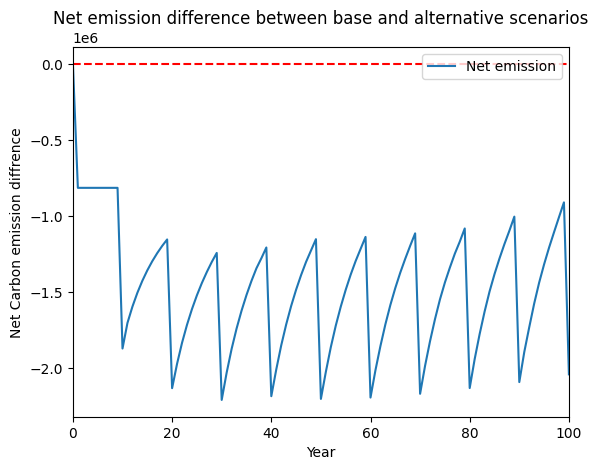

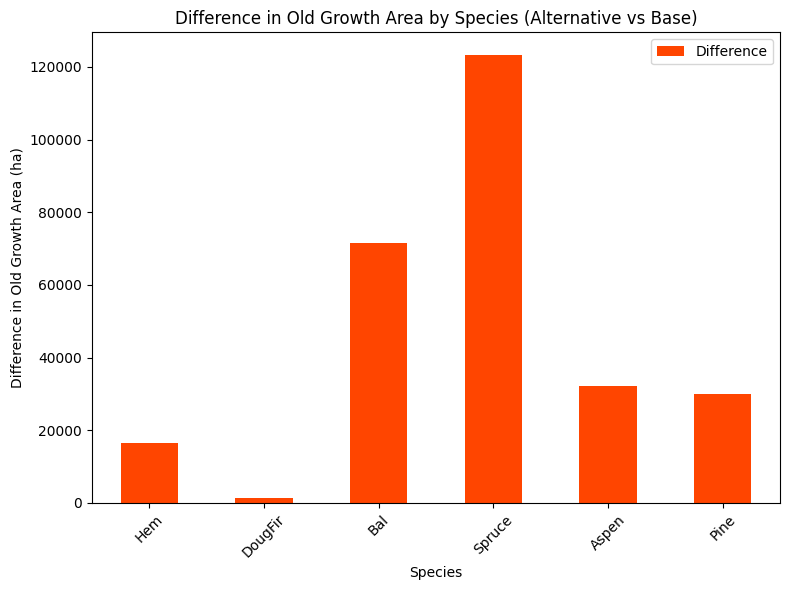

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


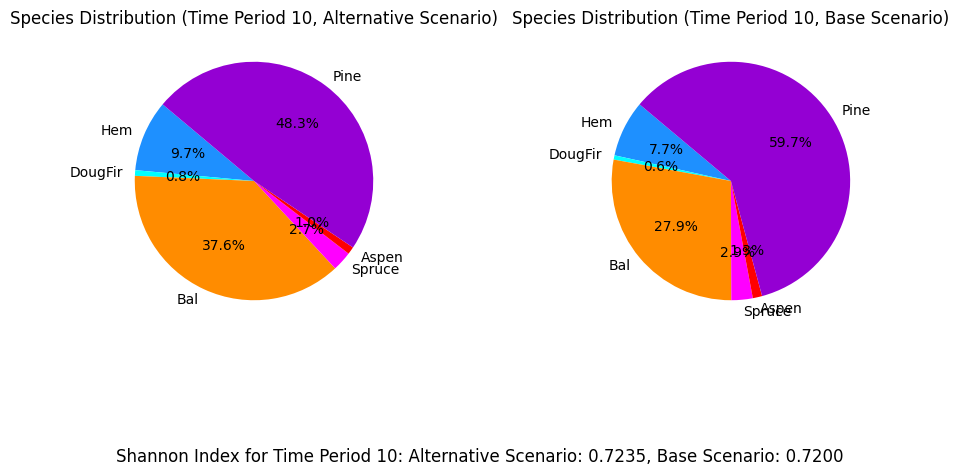

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 356.3 minutes to run all scenarios.


In [13]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [14]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 356.3 minutes to run this script.
